# YOLOX-X — DIMER anchor-free detection and bounded detection fine-tuning (standalone)

[![GitHub](https://img.shields.io/badge/GitHub-181717?style=flat&logo=github&logoColor=white)](https://github.com/kurtvalcorza/yolox-x-detection-pipeline) [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kurtvalcorza/yolox-x-detection-pipeline/blob/main/tutorials/yolox_x_detection_finetune_colab.ipynb) [![Upstream](https://img.shields.io/badge/Upstream-Megvii--BaseDetection%2FYOLOX-181717?style=flat&logo=github&logoColor=white)](https://github.com/Megvii-BaseDetection/YOLOX) [![Weights](https://img.shields.io/badge/Weights-yolox__x.pth%20%400.1.1rc0-blue?style=flat)](https://github.com/Megvii-BaseDetection/YOLOX/releases/tag/0.1.1rc0) [![arXiv](https://img.shields.io/badge/arXiv-2107.08430-b31b1b.svg)](https://arxiv.org/abs/2107.08430) [![License](https://img.shields.io/badge/License-Apache--2.0-green.svg)](https://github.com/Megvii-BaseDetection/YOLOX/blob/main/LICENSE)

**Profile:** `E2E`  
**Mode:** `GUIDED`  
**Notebook specification:** DIMER Notebook Specification 2.2 — **standalone** (§4)  
**Capability:** anchor-free object detection over the 80 COCO classes, and a bounded SimOTA fine-tune that re-heads the detector onto your own class vocabulary, evaluates it against a held-out split with COCO-style average precision, and exports a reloadable artifact

**This notebook is standalone.** It carries the repository's package (10 modules under `src/yolox_x_detection_pipeline/`, at revision `a16f3b9435ca`) verbatim in Section 2, the pinned model identity and the per-file SHA-256 manifest in Section 3, and the exact runtime pins in Section 1, so it keeps working after export even if the repository changes or disappears. Its only external dependencies are the pinned Python distributions and the immutable GitHub release assets of upstream tag `0.1.1rc0` (~793 MB, digest-verified before loading). It was generated by `tools/build_notebook.py` (build_notebook.py/2.1-swc-yolox); edit the repository and regenerate rather than editing cells.

**Run all:** Selecting **Run all** in a fresh supported runtime installs the pinned dependencies, downloads and digest-verifies the pinned release asset, draws the COCO demonstration scene and scores it, builds and validates the labelled adaptation dataset, splits it, measures the pre-adaptation baseline on the held-out part, **runs the bounded SimOTA fine-tune**, re-scores the held-out split, detects on unseen images, exports the adapted artifact, reloads it from disk and confirms the reloaded model scores identically, and writes every result as JSON with provenance. Nothing is skipped behind a default-off flag, and the path needs no repository clone, no DIMER worker or service, no credential, no upload dialog, no configuration edit and no runtime restart: the pinned dependencies go into an isolated environment built from a hash lock, leaving the kernel's own packages alone (NOTEBOOK_SPEC 2.2 §5, RUN7, FT2). No run of this revision is recorded yet.

**Bring Your Own Data:** Two BYOD branches are provided and both are optional and off by default. `USE_BYOD_IMAGE` runs your own image through the same validation and detection contract as the sample. `USE_BYOD_DATASET` takes your own labelled records and runs them through the *same* local stages the sample used — validate, split, baseline, fine-tune, evaluate — rather than only detecting with them, because this is an adaptation profile (NOTEBOOK_SPEC 2.2 DAT14, §25.10), followed by the same export, fresh reload and identical-score check, and a result JSON. `BYOD_IMAGE_PATH` and `BYOD_DATASET_DIR` read from a location without an upload dialog; the record format and the ceilings are stated in the Prerequisites and in Section 13; uploads stay inside this runtime.

YOLOX-X is a small anchor-free detector: a CSPDarknet backbone and a PAFPN neck feed a **decoupled head** that emits, at each of 8400 anchor points over a 640×640 letterboxed image, one box, one objectness logit and one logit per class. There are no anchor boxes to tune and no class softmax — objectness and class probability are independent sigmoids whose product is the score, and per-class NMS does the rest. At training time the same head runs **SimOTA**: it decides for itself which anchor points should be responsible for which ground-truth object, by solving a small assignment problem over an IoU-and-classification cost, instead of using a fixed rule.

That last property is why this notebook can fine-tune a detector in a few minutes on a CPU. **The default path really adapts the model:** it re-heads YOLOX onto a three-class sign vocabulary that does not exist in COCO, measures a pre-adaptation baseline, runs a bounded SimOTA fine-tune with the backbone frozen, scores the result against a held-out split it never trained on, runs the adapted model on unseen images, exports the weights as one artifact and reloads that artifact as if from a cold start. Every number you will see comes from cells in this notebook, in this runtime.

Two facts about the input pipeline are load-bearing and the notebook will show you both. Channel order is **BGR**, raw 0–255, with no `/255` and no mean/std normalisation — that is what upstream feeds the network, and handing it RGB instead measurably degrades detection. And the letterbox pads with grey 114 rather than black. The carried package owns both, so you do not have to.

**Learning objectives:** install the pinned runtime; read what the carried package guarantees and which of its modules are vendored upstream YOLOX rather than DIMER code; stage and digest-verify an immutable GitHub release asset (not a Hub revision) before anything unpickles it; run COCO detection on a drawn scene and read the objectness × class score, the two caller-owned thresholds and the per-object `box_iou` correctly, including one object the pretrained model gets wrong; build and validate a labelled detection dataset in the record shape the fine-tuner accepts; split it and measure a **baseline before adapting**; run a bounded SimOTA fine-tune onto a new class vocabulary; score it with COCO-style AP@[.50:.95] and AP50 on the held-out split; detect on images from an unseen seed; and export, reload and re-verify the resulting artifact.

**This notebook does not demonstrate:** real traffic-sign detection or any deployment claim — the adaptation dataset is drawn in code, so the fine-tuned model has learned these renderings and nothing about photographs; published COCO numbers (upstream reports 51.5 AP for YOLOX-X on COCO test-dev, which this notebook neither reproduces nor checks, and the average-precision helper here is a small faithful implementation without pycocotools' area ranges or crowd handling); upstream's mosaic/mixup augmentation, its 300-epoch schedule, its EMA and its learning-rate warmup, none of which a bounded tutorial run uses; the L1 box-refinement term, which upstream only enables for the last 15 epochs; full-network fine-tuning (the default freezes the backbone; the sibling YOLOX-S repository measured that unfreezing it at this learning rate collapses that model, and a full fine-tune of YOLOX-X has not been run); instance segmentation, tracking, batched or video inference, quantisation, ONNX/TensorRT export, and upstream's latency figures.

## How to use this notebook

**Who this notebook is for.** Learners who can open a hosted notebook (Google Colab, Kaggle or Jupyter), run cells in order and read short Python, and who want to see how a pretrained object detector is checked, adapted to new classes, evaluated and exported honestly. No prior experience with YOLOX is assumed: each term is explained where it is first needed and again in the glossary below. A CPU runtime is enough. The **Prerequisites** give the details.

**Running it.** Choose *Runtime → Run all*. The default path needs no edit, no upload, no account, no token and no runtime restart. Section 1 builds the isolated environment (the pinned `torch` is the largest download, so it is the slowest step); a second Run all in the same runtime reuses it.

**Where the code runs.** The first two code cells run in the notebook kernel: they build the environment and start one Python process inside it. Every later cell is sent to that process, so the pinned `torch`, `torchvision` and `numpy` are used without replacing anything the hosted runtime had already loaded. Printed output, images and errors come back to the notebook as usual, and variables persist from cell to cell.

**Two kinds of cell.** *Infrastructure cells* (Sections 1–3: the isolated install and router, the carried package — mostly vendored upstream YOLOX code — and the pinned-checkpoint staging) are collapsed and labelled **Infrastructure**; you may run them without studying their implementation. *Learner cells* (Sections 4–13) are the machine-learning workflow.

**Form controls.** Learner cells start with fields Colab renders as a form: `threshold`, `nms_threshold` (Section 4); `N_IMAGES`, `DATASET_SEED`, `EPOCHS` (Section 6); `HOLDOUT`, `SEED` (Section 7); `LEARNING_RATE`, `BATCH_SIZE`, `FREEZE_BACKBONE` (Section 8); `NEW_DATA_SEED` (Section 10); the BYOD switches and paths (Section 13). Leave them at their defaults for the first run. After a change, select the changed cell and choose *Runtime → Run after*.

**Section tags.** Each learner heading carries one tag. **[Concept]** — what the model does and why. **[Evaluation practice]** — how the evidence is produced and how to read it. **[Engineering]** — reproducibility, provenance and packaging.

**Predict, then check.** Before each principal result a **Predict before running** prompt asks you to commit to an expectation; after it, **What to notice** describes normal output and a collapsed **Check your reasoning** block gives a worked answer. Write your own answer first, then open it. The numbers the answers quote come from the repository's recorded runs of the previous version of this notebook (reference CPU and Kaggle T4, 15 September 2026); no run of this revision is recorded yet.

## The task: Input → Model/System → Output

| Stage | Input | Model / system | Output |
|---|---|---|---|
| **Detect (COCO)** | one RGB image, letterboxed to 640×640, fed as BGR 0–255 | YOLOX-X: CSPDarknet backbone, PAFPN neck, decoupled head at 8400 anchor points | boxes (xyxy, input pixels), labels, objectness × class scores after per-class NMS |
| **Validate** | labelled records `{image, boxes, labels}` over a vocabulary | the carried `validate_dataset` | a dataset manifest with boxes per class |
| **Adapt** | 30 training images over three new sign classes | re-headed classification branch; head trained with upstream's SimOTA loss, backbone frozen | an adapted detector |
| **Evaluate and export** | 10 held-out and 3 unseen images | COCO-style AP; then one artifact reloaded from disk | AP before/after, unseen-image results, an identical-score reload |

## Roadmap

| Section | Tag | What happens | What you read |
|---|---|---|---|
| 1. Install the pinned runtime | [Engineering] | isolated environment built; later cells routed to it | versions, CUDA |
| 2. Package code | [Engineering] | vendored YOLOX plus the repository's modules, carried verbatim | nothing to run by hand |
| 3. Pin, stage and verify the model | [Engineering] | release asset downloaded and digest-checked | the verified file |
| 4. COCO detection on a drawn scene | [Concept] | the pretrained detector at 0.3 / 0.3 | boxes, per-object IoU |
| 5. Channel order and degenerate inputs | [Evaluation practice] | BGR versus RGB; blank and noise images | what changes |
| 6. Adaptation dataset | [Evaluation practice] | 40 drawn sign images validated | boxes per class |
| 7. Split and baseline | [Evaluation practice] | 30 / 10 split, re-headed model scored | baseline AP |
| 8. Fine-tune | [Concept] | a bounded SimOTA fine-tune of the head | losses, `num_fg` |
| 9. Evaluate | [Evaluation practice] | held-out AP after adaptation | the change, and why AP50 1.0 is saturated |
| 10. New data | [Concept] | three images from an unseen seed | signs found |
| 11. Export and reload | [Engineering] | artifact, fresh reload, tamper check | identical scores |
| 12. Outputs | [Engineering] | JSON with provenance | the file list |
| 13. BYOD (optional) | [Engineering] | your image or labelled directory | the same stages |
| 14. Activity (optional) | [Concept] | unfreeze the backbone and compare | your comparison |
| Troubleshooting, Conclusion | — | recovery, your notes | when needed |

**Fast path.** Short on time? Run all, then read Sections 5, 7 and 9 and the conclusion.

<details>
<summary><strong>Glossary</strong> — open when a term is unfamiliar</summary>

| Term | Meaning in this notebook |
|---|---|
| **Anchor point** | One of 8400 grid positions over the 640×640 input (strides 8, 16, 32) at which the head predicts one box. |
| **Decoupled head** | Separate branches for the box, the objectness and the class scores. |
| **Objectness** | The head's estimate that an anchor point holds any object; the score is objectness × class probability. |
| **Letterbox** | Resizing to fit 640×640 while keeping the aspect ratio, padding the rest with grey 114. |
| **BGR** | Blue-green-red channel order, what upstream's `cv2.imread` produces and the network was trained on. |
| **NMS** | Non-maximum suppression: drop a box that overlaps a higher-scoring box of the same class by more than the NMS threshold. |
| **SimOTA** | Upstream's training-time assignment: it chooses which anchor points learn each ground-truth object by a cost over IoU and class. |
| **`num_fg`** | The number of anchor points SimOTA assigned as positives per image during training. |
| **CSPDarknet / PAFPN** | The backbone that extracts features, and the neck that mixes them across three scales. |
| **Re-heading** | Rebuilding the classification branch for your classes; it starts random. |
| **AP50 / AP@[.50:.95]** | Average precision with a match at IoU ≥ 0.50, and averaged over IoU 0.50–0.95 (which rewards tight boxes). |
| **Saturated** | A test so easy that the score is at its ceiling (1.0), so it cannot show further improvement. |
| **Artifact** | One file with the adapted weights and the metadata to rebuild the model; reloaded and re-scored in Section 11. |
| **Isolated environment** | A separate Python built from hash-locked pins, in which every learner cell runs. |

</details>

## Prerequisites

- **Runtime:** a fresh supported runtime (Google Colab or Jupyter, Python 3.12). **CPU is enough and is the documented default** — this profile is float32 on both CPU and GPU, and CUDA is used automatically when present. For scale: on the repository's Windows CPU venv (Intel Core Ultra 9 275HX) loading takes 4.5 s, one `detect` 0.42 s, and the whole six-epoch fine-tune 130 s. This is the large YOLOX variant — roughly four times the per-image cost of YOLOX-S — so a hosted CPU runtime will be slower still; budget several minutes for the adaptation cell, or attach a GPU. On a Kaggle T4 the previous version of this notebook ran top to bottom in 66.0 s once installed (15 September 2026), after a first pass of 154.5 s that stopped for a restart in the old install cell; this version builds an isolated environment instead and has not been timed yet. The kernel's own Python version does not matter: Section 1 builds a separate **Linux x86_64** environment with CPython 3.12.12 from the hash-locked pins, and every later cell runs there. The Linux build of `torch==2.14.0` with its CUDA libraries (several GB) and the 793 MB checkpoint are the large downloads.
- **Knowledge:** basic Python and PIL; what a bounding box in xyxy pixel coordinates is; what intersection-over-union measures; roughly what average precision summarises. You do **not** need to know YOLOX internals — SimOTA assignment and the loss are upstream's code, carried and called, not reimplemented here.
- **Data:** everything is drawn in code by the carried `samples` module, so nothing is downloaded and no private data is needed: one 640×640 COCO demonstration scene with reference boxes, and a deterministic 40-image labelled sign dataset for the adaptation. Optional BYOD is gated off by default. Expected BYOD input: for detection, one image decodable by Pillow, sides 16–4096 px; for adaptation, a directory (`BYOD_DATASET_DIR`, or the files chosen in the upload dialog) holding `annotations.json` — a list of `{'file': 'name.png', 'boxes': [[x0, y0, x1, y1], ...], 'labels': [name, ...]}` objects, boxes in that image's own pixels — and the image files it names, at least 8 records. Do not upload confidential or restricted data to a hosted notebook environment unless you are authorized to do so; uploaded inputs stay in this runtime and are not sent to any inference API.
- **External access:** `github.com` only, to download the pinned `yolox_x.pth` release asset (~793 MB) from upstream tag `0.1.1rc0`. YOLOX publishes no Hugging Face model repository, so the checkpoint is a release asset rather than a Hub revision; the SHA-256 in the manifest below is what makes that download trustworthy. No credentials are required, and no code is fetched from any repository — the YOLOX model code you need is carried in Section 2. The isolated environment also needs PyPI (`pypi.org`, `files.pythonhosted.org`) for the pinned `uv` wheel and the 32 hash-locked packages, and the managed CPython 3.12.12 build (python-build-standalone) that `uv` downloads.

## 1. Install the pinned runtime (isolated environment)

> **Infrastructure.** You may run this section without studying its implementation; the learning activities start after Section 3.

Hosted runtimes such as Colab import some packages, NumPy among them, before the first cell runs, and Python cannot swap a module that is already loaded. Installing the pins into the notebook's own Python would therefore leave mixed versions or require a manual restart. Instead, the next cell builds a separate environment (`dimer_isolated_env/`) and leaves the kernel's packages untouched: it downloads the pinned `uv` 0.12.15 wheel and refuses it unless its size and SHA-256 match, has `uv` install the managed CPython **3.12.12** (whatever Python the kernel itself runs), and installs the 32 packages of the carried hash-locked requirements (`tutorials/requirements-colab.lock.txt`, compiled from the pins below) with `--require-hashes --only-binary :all:`, so every package, direct or transitive, is the exact file that was locked. No repository code is installed. The lock holds manylinux x86_64 wheels, so the notebook supports **Linux x86_64 runtimes only** (Google Colab, Kaggle or Linux Jupyter); on any other platform the cell stops with that message. The printed dictionary names the isolated Python version and the kernel's.

In [ ]:
# @title Infrastructure: install the locked runtime into an isolated environment
# dimer: kernel cell (runs in the notebook kernel, not in the isolated environment)
import hashlib
import io
import os
import platform
import subprocess
import sys
import time
import urllib.error
import urllib.request
import zipfile
from pathlib import Path

PINS = [
    'torch==2.14.0',
    'torchvision==0.29.0',
    'numpy==2.5.3',
    'pillow==11.3.0',
]
MANAGED_PYTHON = '3.12.12'
UV_URL = 'https://files.pythonhosted.org/packages/1e/fd/432451d732917c49152a291de3ef171aa6b0f1a22d39780fb2c1f085ca4c/uv-0.12.15-py3-none-manylinux_2_17_x86_64.manylinux2014_x86_64.whl'
UV_BYTES = 20081404
UV_SHA256 = 'aee9802f46bae436bd91751bb33ddeb379ef1596b5c19df193219d545d244b60'
LOCK_NAME = 'requirements-colab.lock.txt'
LOCK_SHA256 = '6c52ab6264fe8be8df264c984289db92e700489b03a36a38c8ee3a07f42de26b'
LOCKED_PACKAGES = 32
# The hash-locked requirements, compiled from the PINS above with `uv pip compile --generate-hashes` for manylinux x86_64.
LOCK_TEXT = r'''# This file was autogenerated by uv via the following command:
#    uv pip compile pyproject.toml --python-version 3.12 --python-platform x86_64-manylinux_2_28 --generate-hashes --only-binary :all: -o tutorials/requirements-colab.lock.txt
cuda-bindings==13.4.3 \
    --hash=sha256:044c03b056dcc5cecfad426a071187dd9e1e6817fbb363bc2f3a7520170b3e67 \
    --hash=sha256:0deff5b22462bb410859684299b1fc6a621780c43a4729342aa6ec28783485b4 \
    --hash=sha256:130ff1daae550db2cef559ba477f3a63d040756bd135f5deba4b5bdc4e110252 \
    --hash=sha256:145cc9b02dfb7bcc3288701b6f19c69c590e4451c62916ba0a8a3db9a64a91a8 \
    --hash=sha256:1fd7d8459b364aedc11f3e59703453ced823135f78a9111ca70feef8d56d4d21 \
    --hash=sha256:3d7a6506e625be59cdc119ef4423afa0fc3a4830b129dc010cbd51324b93d66d \
    --hash=sha256:4796864ce829bd95ef2ef0d23c6ba21bb64e08f7fab0a377302ed1affb6605c7 \
    --hash=sha256:52d7f3f5f7f014dddddc66cd802ed0ddf65ae99ad42b5619fae7b82e5ddd6771 \
    --hash=sha256:6c6bb1a4c4f7520e062669c6f3605a7016b2e65ba51b8922f92edd91d5fadf8d \
    --hash=sha256:7e11cfe8fec4c85ce79feda18124971c52596f0cbd642a94f5dafc257124a4b3 \
    --hash=sha256:81eef62bbb95cb4a705fb423b2ad1c63d716edb352ee2af0c28bf8a29cc8258c \
    --hash=sha256:a9ea13b9cfe711515ae83b5efc99101af4d3f8ad882f99724a839c8b5417fb7e \
    --hash=sha256:b89d6e738494b7b95c38e3413f86d32c24682c8e714870531a5a2b193a2fc50a \
    --hash=sha256:bbacde6f75665b197016b986164cfdaa33b17515e5e635a63ddb75926aaa71c3 \
    --hash=sha256:bc51990309b416e0780a11a921ac597ef9c0e52e1bdf5ae0b8e8c4766b66442b \
    --hash=sha256:bfbd3f7d4ac04dd41dc49121b9e408c8283992f47124c2290ecb79bbbadcca8e \
    --hash=sha256:c2af7e69d2557fdb4e5fc1169159fd08da7e861aa84fb83307a1a0396b6b0973 \
    --hash=sha256:d5f72bcfcdf3be23e1da3c792f68f508586f48d037bca8b10f552c4cca5971f2 \
    --hash=sha256:d6eb969920e28f66f8fc3b0b3afcb6e09381cc96bf8e8158d774e9488ae89980 \
    --hash=sha256:d7c6c9f46fca7f3fc61959ef9a2398ac656172145b43f408e0a6492360cf1c0c \
    --hash=sha256:df8b3767facca8acde216460df684dfc3826d519096c13adfd3030a55870dc79 \
    --hash=sha256:e52f66340785a51b8b77f4487329de188f3cabbf37c62e68f410a8299e8677ae \
    --hash=sha256:f8519603001c92bf83e7095df3b8211e3999a9c4ded096b57de0f3ff52b66368
    # via torch
cuda-pathfinder==1.8.3 \
    --hash=sha256:e29e59829c297a7a5233bd9cc71094fc5bddbd076951482670178f9eade39b1f
    # via cuda-bindings
cuda-toolkit==13.0.3.0 \
    --hash=sha256:d693caaa261214ddd7dbb60d68e71cbed884e68c2be7509778f3051da0b91c3f
    # via torch
filelock==4.0.12 \
    --hash=sha256:5f17ee83ecee8a6f3e389c75822fb70a1c2f0506b99438a6dffa1d56793588c8 \
    --hash=sha256:cf42711a7ac791818b299fab0332a088c65aeeefa36290de98db92c434303b0c
    # via torch
fsspec==2026.9.0 \
    --hash=sha256:0f08147951c8cb31d844c3547d631053b127863b60be04cf06e121333ee0e2fe \
    --hash=sha256:8dd6e646e99ea382bd85f97a45e6b526a442d79423a7dc673f1e2756d05fcb5f
    # via torch
jinja2==3.1.6 \
    --hash=sha256:0137fb05990d35f1275a587e9aee6d56da821fc83491a0fb838183be43f66d6d \
    --hash=sha256:85ece4451f492d0c13c5dd7c13a64681a86afae63a5f347908daf103ce6d2f67
    # via torch
markupsafe==3.0.4 \
    --hash=sha256:007e1ffd9bf65bb6ee96df7b258fc632a4868dd5566037986c64781f35a36e98 \
    --hash=sha256:02fa4acbc6a3fc5c693c34d4dd8c1130b7fe99cc915181b0ddd6f72aeb296002 \
    --hash=sha256:03470d1a8268e692ecf79ecd565593e59d44219377a7ead61f1f1b94c1f7ff6b \
    --hash=sha256:04e7902ba80ee4bac1d50a549606527a1dcf0476cd81403db41099d3b60ec653 \
    --hash=sha256:051417f74bcaaefa316276e0ff723f541616ca51043d070da00249d9bddd3e3c \
    --hash=sha256:05295589e619b9bed252a86b532b8e27350abc372d18ba89b59375325e91ec1e \
    --hash=sha256:06de8ef6331f6e822c28d577dc8bf43fe398800477c49498f38fc38b67ff33fc \
    --hash=sha256:0764a13d34cae40db7bbf3a09b7e9b491bf4603e20b263a7a9d6b8e324975d0a \
    --hash=sha256:077293e425f28ec737dbcad442a71752e28f8ae27cde3d68acd1fb212091cd92 \
    --hash=sha256:0930db9bdc62d22944e10b066448bb65dc9abe9112880c7cab8da54db4284d5f \
    --hash=sha256:0cee7cb0f9a1b6892ea482237d9403b3d1b4603aee057d0ff01f0fac2d019a97 \
    --hash=sha256:0d9c47709875fdb321452056622e930c52afbc07a7d780762fbb8b4d91ce6fa4 \
    --hash=sha256:11935df9bf455ed0c04eb87bcd720f02b1fe5e02128a9430f23aed6f93336fc7 \
    --hash=sha256:12a606a492de952afcb43b59a14aaaaad120e708d3663dd0fdf2d738d427a691 \
    --hash=sha256:14bd2d845d62ab678eaf81da89d7b621b51756c72346745c1a594c09d49207a2 \
    --hash=sha256:15ba9e28640feef770374b116a6f019c21f52404aeabe516aa7f800587b98cfc \
    --hash=sha256:18a801868a884f216e784d7d14db2a4077143ce7610440aee2ce8f734e7cfcde \
    --hash=sha256:1c0df495a977d10460a94941799c72d5b5ab03d3858d949b55b5a66c8f371c99 \
    --hash=sha256:1caa2fa5a6184fb233153b35f654e6687bd555476f6170f29d8ee9be1a8b0af9 \
    --hash=sha256:1e1451fab512d1bcc3dc26988ec1edb0b82c2db909132872cd9356070a6b63df \
    --hash=sha256:1f1f9477e174582b0a1b583d60b66e1f2cf5d3fe12cee985e4aedf44766600e5 \
    --hash=sha256:2628d3a8cb648ecebb3c5d6b0a1052d400e4d8b7ac0fb786be8d285b50040d17 \
    --hash=sha256:26e9867520db70d37f7fb421a7f0d8adb40171011fb84ce869afa1a83370dfa8 \
    --hash=sha256:2a6ef68ae94aed8721934072b27a3b654ea2100b97e4ab864cf1489c90926fbc \
    --hash=sha256:2b2b1e18af909b448bb3cf9e3433366f7a8726271fc214e8b10e0f62a78c724b \
    --hash=sha256:2cb3dd71fc6be918ad4264346a8ed69485f9b7ed7bf35495d8e22807cd6b8bea \
    --hash=sha256:2d1b7d9308288661f56672b1b157d75fc536714d3638487bbea17b6318a78248 \
    --hash=sha256:2dad610540cb2e6272855c178f08ae9a1c7ac258a7fb71660553a5f104b42741 \
    --hash=sha256:2e5a7cd7fdd14fcb1ae5d7d8bf23d24fbd1daefd1fbca2580132e1ea75f098b5 \
    --hash=sha256:2e9ad7dd851bf45fab9f75cbff4cb493fee9979e8d8c7c9c3ee119022518edd6 \
    --hash=sha256:340cbb1957ba99929cbf19a75626d36ba1ae21d1730b287d1cf7f824a20c4fc7 \
    --hash=sha256:34bdde374c5932765d7dc685c4a1d191a3207852d67e8e0a9eb6ea85156181f1 \
    --hash=sha256:353bd63081912ab8cfa6a0c7d185934cdf8426f04c618bba6bc4b394f2069b67 \
    --hash=sha256:387d8cd30e69b3f0a72877b9ae717033396404e19095b17fe89753a981fda44f \
    --hash=sha256:3882fb412298575bae3b9c46868251f15cc69307359f87bb1b382e53d6e5a2c9 \
    --hash=sha256:38fc55594dab834470b6733dead2ee9e3f657fb0608c769dcafa0ba5ab52f45c \
    --hash=sha256:396ec4e65cc889f69786b3b89478b471cee5a3bcf468b9d9bb03e1a30fb291fc \
    --hash=sha256:39dbacefc411633db5b4378b066a9aca70a3d7e2922c9e578d825f844026eeba \
    --hash=sha256:3a93d9616ddecfb393727a0041a562cf0b15a244e20f2bd25efc7949be4c4f17 \
    --hash=sha256:3d23795802fc8bd72534836d64489bbf0f67c088959091bdb22e10735a5107bf \
    --hash=sha256:434139499bb20b502ed3baa1f169e618f924a97e7a777fea1a49446d80106cf6 \
    --hash=sha256:436e3ffc6310d3c41878c601db29098102fe5d8a467c49da4a4125254e0980f2 \
    --hash=sha256:489505b03f692c3f376394e49194fa7a7f9e8558d6e293a7056a0032b0c38163 \
    --hash=sha256:4a540e2d3192792fc84eced57bef37851ccb2b41f73291bb17408eea77bcd278 \
    --hash=sha256:4a7cdc2a420ca01058182da4253329764d4bfa055564d1eced90e6ba1e8b1d3d \
    --hash=sha256:4bced6e2a6dba6a28f7dd3c6ce14df1b2dd495923f16ea484cad03decd463b2b \
    --hash=sha256:4cf3468d5ec187ffffcaca8e61929a37448f215dafc1386a12c750a72fe53634 \
    --hash=sha256:4e2c4809c14559aa7ef426f27fb35afbb38104c349a903bf8f3600456764bb38 \
    --hash=sha256:4ed644d75aa94a2baf7ec3a96eaa160ea58c742eb9d27c6506053c5c40fc84ed \
    --hash=sha256:4f6e0852a0283b1b1fd776eeb7b766a5f440b3e2bd31ab51af3b400585f3965c \
    --hash=sha256:5066b244f576f91afc8ee3ba029a89f99d39c79b1853fe9d39bea9f0afbec148 \
    --hash=sha256:5086f9975abb1ab531ee6afca1761e4b59a19b446f3f6522ed776963228cfe5a \
    --hash=sha256:50b5bedc9ed8a94fc8857a42ef4f84a81ea88f8d4f05dc8705fb23ee6d8dcca7 \
    --hash=sha256:52704c5d36eb6dda8866493decd61111fff86244c9b1ad225ca01b9e91e5970f \
    --hash=sha256:55ffd6ce583d97dc71dc92e930324c8c0d25aea7e3ade6ae54ef77cedb096811 \
    --hash=sha256:569d65055d367e3dcdf30c3f41119467b73d9ee9faf332bdf40402644f5ac08e \
    --hash=sha256:57f9947a7e57a081c1e3e0a2dd0d2dcf290a4531450e6f611e30084c222a7295 \
    --hash=sha256:5989cb26b2e1efc6a42216a9f6b5ee495ce5ace2e5b352a9af489976b32d1ee2 \
    --hash=sha256:5c22873ad1f0532ba40fa1727f3c0fc1bbbaab6d373d4cbe3f0dc74b2e2521c7 \
    --hash=sha256:5e8b3d0b18fd623afa12ecb2ce8d8becef69f9b5440c6330c7972200e0bb84b0 \
    --hash=sha256:61631e08084be9e21a8967ec3139c7616ed7c5e9368e05c86d1b39562c8a57b6 \
    --hash=sha256:64511c54db4e4987aef4c41923235927428729e8174c5dba488429be70a998ed \
    --hash=sha256:6669c1bf34080161ce49c589cc512ef24d4c704ac9d2b2d3667f519c60418378 \
    --hash=sha256:672d207103e6b16ca098611b0f9efad6bc00afd47c03d6ef62186495ca677dc0 \
    --hash=sha256:6768d67d1bce64270e0fdc2e69309d68b9b18ae56ddf6c711d168e9d051c2cac \
    --hash=sha256:6a45c3d514f2436064db00d7fc8778d888f0236ebfed649b53d13a59e69ad51b \
    --hash=sha256:6bd9e1788e15bfcf6a9082de42e30387e7b85d211ab21e57a939bb8cfaaf8d96 \
    --hash=sha256:6d2a9efe686f9de00d0d1ea32a4a5a86d558a2277501bd78d964214eab625e59 \
    --hash=sha256:6da83a088f8ef93b2d483a8232a4dbf4d69d3d8496b568a03c56becac43e1808 \
    --hash=sha256:7018d4af1cd272e847aa5917983ab5e83e4f6579f9dbfecd4a79c0ca80b144c2 \
    --hash=sha256:71f88e749ea29f67f21f3b36433c1dc54c7729ed2a6d9e2da2e0d9e0d7b224eb \
    --hash=sha256:737c9c3981998eba27f11786f84fddcbabc74068b72a4a1f454ea02094b57b65 \
    --hash=sha256:73e77980c7207854f00fc4e71fb1626868d5740ab4012623d55c7a99ad122a72 \
    --hash=sha256:799c39bdf5e2f1292fedd3009f7b3c9e760f10b2420cb9638d56920840ff6db8 \
    --hash=sha256:7a83aa6e4805df46fed18e989d3d16f86ef60cb50bbc8d9ce3a6be89165fbf6e \
    --hash=sha256:7d3391b2188d18737cb2fa147028b1096236eaa7e156446c650a489fa2cadc91 \
    --hash=sha256:7e1636da3d8dfc220b6dd10264db5f2b165e4888c4518594898fbe381049af8a \
    --hash=sha256:805c8b84534fa10891890f0e4be39f3a99e94615d93e8836bf9fa1fdca2feeb2 \
    --hash=sha256:811d02d5122171c1941357efd8f9bf4ffe907b7f0a1a4e729a880e4be3f46e3e \
    --hash=sha256:8138eb83940ec7299024d92d4dee45f601b9e6c5ffde9d25f4e35e326203c707 \
    --hash=sha256:83b3944fea42a8400edf92fd1770fb8d0d4f7de651353bd2d8525a92dba69a21 \
    --hash=sha256:849dd2bb0e5e4ab2b71c7191726a4a8d5aa8a610daa584728cbee0b710ddc4ef \
    --hash=sha256:8698d70a8081ee8c090dbb394768b5789a1da8b131b5499f89d071dd3cfaf6be \
    --hash=sha256:8781a792a070cf2bd1b86d3aa943894115faaba6e88122a7bf32d62072742453 \
    --hash=sha256:88d59b473bfb03259722600839af9bbd7fa13a2eb514beefeedb95997882f69a \
    --hash=sha256:8909c2f1c6dd65e054ac4b573a91c8384d1492281e55d82d159d653f7a13adf6 \
    --hash=sha256:8965520ac587c94a4ac48b729be3d8b8de00af39699b17585dfb599babe77977 \
    --hash=sha256:8b5d563170ff8ba3181caa967c99a3c804d1dedb702c7cb93a6a7c32247da978 \
    --hash=sha256:8e124f974786f831d6043728e38296969d3579db8896fe004682f5758e613581 \
    --hash=sha256:8f0fac8b13d14bb06c68195f849371924ae53dd7b1c00fed24650f704383b692 \
    --hash=sha256:9240187afb63d2f9ddc3e032c670356fe941f6e20662ea168a5dc3f1f317e1b3 \
    --hash=sha256:925f929d6b59a8b3f8b8c6ac363cd0af7eecc81efb3071770b3c6717c450a369 \
    --hash=sha256:9348cbb300d224fe3b89793262cb093504d4ae927004468463f745188a193e4a \
    --hash=sha256:9388003072b95f2f1e3fd908604194d653ba21330d811961a78b7da1a77e9e36 \
    --hash=sha256:9438a2648b2195980cb2dd8e53ed7b8df91319e2d0b70ae61a9e1d1bc8d3bec9 \
    --hash=sha256:94e4c421742086aeee4c32a506eec8859d7634aad943f7e6aacf70f813478768 \
    --hash=sha256:94f5407f7bc64fa6463906b896f9904beeeb7dd8dc116ee8e9056c8714ff9916 \
    --hash=sha256:971a3bbb75d97ae4e2e8f7d4834236f86f85f0c85e04ab2e191db1123b04f80b \
    --hash=sha256:9e227f3dbe6bde7491cf0a9965d00b88c6b1a4a95d11480ddf88bb96d397c19f \
    --hash=sha256:9e25feb9e330b63edb0278a0acdf85e50d0cb0fbf49c3084abbe4e24ae195346 \
    --hash=sha256:9f098115c247e11d138ab83a28fa0323c77015007ea2df73ba5fd714dfefd67c \
    --hash=sha256:a18f38cafc329bac5e3c2b96c765b4c96d3d103421ed22ab7988c1e3fce27464 \
    --hash=sha256:a4bbd2d87dd233b9fc5812160c3d0ffbe42edc22a26ce0469f58479ede633fe9 \
    --hash=sha256:a5fcffb37e602b0b3c1638a97746b9b96125caa9bcf6fa41d337a9261de231ee \
    --hash=sha256:a8e9f292fcda89b324f2f5c91d13f1424a153e40fc2756f38ee23b15835ff300 \
    --hash=sha256:a9f54054101545a9a9cccefddf54316aa6e4491611fcbef9e91b3b6bebec04f6 \
    --hash=sha256:aa2c838cc024642cc04c6854232f32b43e5e22833dd11119c1766c7873b8370d \
    --hash=sha256:ac0c7c9f1609b0c4c114feb1d7a3409564c7fb77e360bed9e97e5d25dfeaf868 \
    --hash=sha256:add96447a86d205ab616665d53b2950ee81083757f56e6ea833c8b2917646b46 \
    --hash=sha256:ae9dcb8fbe244cb82f8a6458b455b927a03685e383d9bacf1ea5ce180b96dc97 \
    --hash=sha256:b4a635a0487774f841cb1fb62e907e7195cc95bc761e053184b8acc3ceb20733 \
    --hash=sha256:b4d12837e0203bbace818ff4a7461afdcd78bcd782351cea148139180d7bcffe \
    --hash=sha256:b61687d0828e72bf5cda24a2690188f37170bd31c9359ac97e4e66569f120a16 \
    --hash=sha256:b807e598953730f82e4eae3bd30f6a122cf6b31c398c6b504c0e04c13c170429 \
    --hash=sha256:b8cd1f918b26fd7b1832ece557cc18f2d8747309ff8b3f0ef9d4250c5ad67a39 \
    --hash=sha256:b91cc9d336957239ff200f30097e6fea2dc6d6fb3c81e853eaa09eac904fd894 \
    --hash=sha256:bd3ce56ae2cbae3ba82b683bc425cd7e48d2ed8b10f3e818186b6f5646d9271c \
    --hash=sha256:be6cb0c799abb0e2ba3e618e6d28ddddf7e485f6c2ce938dfa237daf3905072c \
    --hash=sha256:befb4158af32106b9a93db8d6d1d1cbbd418c0d5aca0cabb7b1780abf0c89169 \
    --hash=sha256:bf053da3c97a4bc5ecfbb218cdd2983febd91c617be8367d139882aa11e490aa \
    --hash=sha256:c02e8f18bdedba082cef725942ac823b9b60656db07f7e265cb31618dfd00d77 \
    --hash=sha256:c1bc67752d5f21013cfe430df4062441714eab79f65a6a05e01505957e9c35fe \
    --hash=sha256:c61750fadcd119d0825bcb7d7d675dd264dcc89cc05292aab5be68ebdbb374ad \
    --hash=sha256:c90d5b3d4e944e065a301d741b3c1d784f6bd1f503aa68b4967e32b2ba313d85 \
    --hash=sha256:c9a7f43c0b202b334cc9184af09bb8f21d3a209e038efaf106936fb69e6b026e \
    --hash=sha256:cb96e6e088d6cf71c1ea977510948320234824cf226e32f6f6e044f7a9c82b34 \
    --hash=sha256:cf63c214fe879a65e69a386f915e36104fc84254ab141240f8854602d8e0be2a \
    --hash=sha256:d1aca03ede943eb80ab3d63bb082c84b7aab85ea83bd0fd0c200260945fb49d9 \
    --hash=sha256:d2e56fd3b00222722abfb3f5f0759ddbae4b90811b5ad4343c64030ad1bde70c \
    --hash=sha256:d5f93ebbeb8032d47e349328ec8662d973d9b05a70b3c35df1f91fe419b84749 \
    --hash=sha256:d882a373d8093c2941e01291b7ced96e9cbe4781da9a7751ca7e6c70385e5214 \
    --hash=sha256:d920abdfa61279ba1a2ef9484aab07bf03331f8c08a10120fa332353d06e6932 \
    --hash=sha256:da2af0d7aebfc2074080d72efa6ab8317c62481ef1f896f65d9999c1c01f4494 \
    --hash=sha256:dd8ea6ebee7aedbf7c749fa80521d9ccf1ba473e0d1e14805caafbaad281c889 \
    --hash=sha256:de8b364c423ef0a4bad9069657d617f9a5d2b2062457a89b1fa16ee199c399c1 \
    --hash=sha256:df1ae86ff54725a01fa1a0510b914ca53a161b7050be74f6204e24aded5971d0 \
    --hash=sha256:dff05cb7016dff1e9fd68f4122c127b65dfc59de5306cfb7ad92f956f230bee2 \
    --hash=sha256:e1a622f13970d81f95d0c72f9dc090dce9085fccfa4c9f2174377ee32bd15786 \
    --hash=sha256:e49fb0d1ce92cfa0cb198cc5b1b11cdf9d0638658e2a2db2687e39db7c87fc78 \
    --hash=sha256:e5c802729725bd07e2bc3ab7b76dc7e0bbfc53129d8f1eb1c002c24cf774717e \
    --hash=sha256:e841068dc0be4cb6dfb5c890eb88cbdcff2f4a332393c7ec94e8e618bd32c1a8 \
    --hash=sha256:e916035e3e9930cbdfdd10abf48861340221857f45509565898e012263f7b289 \
    --hash=sha256:eba154571c16e032112afac0dc2dfe9e63c2ceb7aedd07bb7eecf2ce26d4dd4c \
    --hash=sha256:f03460ff076f70ab595bb45a0205ccea1971443575b6920c52e755dec2b3fbfe \
    --hash=sha256:f0ec3b750b59375eab5b0fb2b9254810c00a3375be6d789899f1055a1d556237 \
    --hash=sha256:f291bcf42ae98eb5107edb162c3c998b4a89648fd8e99ed4cbd12705292788cd \
    --hash=sha256:f61efe1d2fe0de16158a5fe1d1cf3c14bdb6aecd54d8938fd26512c525c1f624 \
    --hash=sha256:f68edfc67aabac33708941f26f22a7b8e9f81429bc0cf249fcf7d66b23af8d19 \
    --hash=sha256:fa95848c929b6a75f6848d3c9793e59db365ee436776e57db835cdbfa79ba977 \
    --hash=sha256:fd9f8797427910198f95bced71ddfed61130d7e349213bfb8466c9c99e2c46a8 \
    --hash=sha256:fdb4ca07ab75ffadab4a8b135ad59cdbb3156b99310f3d565370da74a15d6bd3
    # via jinja2
mpmath==1.3.0 \
    --hash=sha256:7a28eb2a9774d00c7bc92411c19a89209d5da7c4c9a9e227be8330a23a25b91f \
    --hash=sha256:a0b2b9fe80bbcd81a6647ff13108738cfb482d481d826cc0e02f5b35e5c88d2c
    # via sympy
networkx==3.7 \
    --hash=sha256:e3fd2c13a7814cee3746340d8d7f8598a67f16a58bf47fb7f8793fab6efca1b0 \
    --hash=sha256:fd77a511bd90f39f3d016351345b52cf5319b813bdca01de3f755d3cca62e96a
    # via torch
numpy==2.5.3 \
    --hash=sha256:012e66aca395d795496446e52aeeb5866312a5d4d3f27da270e5a0b43f70dc5c \
    --hash=sha256:09d5a423c71ad5feb5625844ad58050e35df43871004b52ac9c0ad44a56775be \
    --hash=sha256:09ffa5d903faeaa5c4dd05009cf81c8bab9f2cb37c548b8d39b65b4cfa7c97f7 \
    --hash=sha256:0a59a421a32580a009e8a1751345bf829631b990dc1794b80514ab722b435def \
    --hash=sha256:116f96cadd935c6122e9228d676fe7ede19e741f5c8bb1c3cddbe0c51ccebea2 \
    --hash=sha256:1302b90c0e52281681b2975adfe8a860cb7b12216a27b4b0b4207c44bf7bccf0 \
    --hash=sha256:15aa985ac73a8db02db7663381aa109510449d3819d37206caed27b33a65a8a6 \
    --hash=sha256:1aad64d99730d013cfc6debafed22783b4fc5a7f4b8bc744d2d8cf7dcc880551 \
    --hash=sha256:1c80eabb4035ecf4ca9cd49cde8a9fdd69a729e63e6474887d1523ade7aa277f \
    --hash=sha256:1f3ed25271581281f2fccb1adcedfcde4c07362eec69189b50baf6f90e3ae159 \
    --hash=sha256:1fb6f8fb9ff0b3a69f52c66ce397b0246583e9f28616231b0e32ca49259a5fa6 \
    --hash=sha256:214045a5bf00113a146ab9ee9730c44501af6723cdf1f6830932f7b5ef2e7af0 \
    --hash=sha256:26e15e4aecd8617dfbaecb37d223e365d7b39411fba20454be2670a96aa74cb5 \
    --hash=sha256:2c25dfa72943e4336ddb6b0ee4277b47a0c85bede0807530ec68103bf58e2c10 \
    --hash=sha256:2d8240cb4c16fd831074aa2b2cf9fc54664d826341d61c372245b96a74a49a9a \
    --hash=sha256:350ba9783ce969cf9f7ce6e6a9a58e1a6e2a19ca025b7ee448c4db727706212a \
    --hash=sha256:4c8a6d2ebce6305fd82fbefca827775437147052a976ee7c94b36a0c1b52ac6c \
    --hash=sha256:4f8929ee6c96bfbd7b4ed2032e0c03af86fe1826740ab61ddabf9072d06e57ff \
    --hash=sha256:536f963710a4e63934d80ac0dc4f478804a83e9a84b6828018f25d09953ada33 \
    --hash=sha256:54a115e5a73b8fc44f0cebef486365a1894b5c9760685d4558b72b7c3eb846e0 \
    --hash=sha256:595d020938c84e320bcf40ad71089e108eac0d377cd018e14a8c094f39e98d85 \
    --hash=sha256:66a78fe4556c60aceda5916f9eacd638b18e9e681016ec302dcb4682d6d4d034 \
    --hash=sha256:6b05c171afb3aa07adbd20abc00aea86fe375beb0fdb9ef780ec5b7f63bab1c0 \
    --hash=sha256:6cef4bb1706dfec49243c05d921eefb4e190d41e2528b30d8035ea1f36b4c24a \
    --hash=sha256:6f24021b9f22bc6301c37b196974a92c1c18dccedb6fef3dd252e95f2d6adbe4 \
    --hash=sha256:71b39d9f935b6ec0f8753e3e2afb51e3efba6f2e05b68b32a40754d24bcd4a3c \
    --hash=sha256:71cad2b2a7451ab79d8f5e71b453485b6775963d5cf794179144a7463fe6e8ec \
    --hash=sha256:76c2c1e6bfa5c84adc6434dfbf013aa92096a7985221762c8f11fedfd20fff58 \
    --hash=sha256:8617bbfae4486cf99c9f899966699428d19da931d06ca94ad3da986c76e15997 \
    --hash=sha256:86bff898a431c0fb71f7610b75726e75a54d47b37edc9d537f48de63bb3c0b90 \
    --hash=sha256:8e4dd766076855b5ff7ea52fa5f07ce26286726e0f8bff446b7739d02e6ea204 \
    --hash=sha256:92f30e89b8ee0ecf363033576c422b2f58fed6a80bed0aa48dff6d14c654663e \
    --hash=sha256:93e1f5447e2b1e479d7bd74701e84746b86450cff1fc368b132d195e2b8f8211 \
    --hash=sha256:9a37475425b431b4d060f23b4f52cd2f3aef6bc7c654bd760adf0040eec9d435 \
    --hash=sha256:9deb49575e5b0b94ed72c8a64ec4d033381adc27e9060ae842971f697ba96104 \
    --hash=sha256:a5fa86b80fd24bcd1aff83ad23be44ea323de3f787be8f8b15d4a65621e25321 \
    --hash=sha256:a6391fafaba97500887132cd582abc6e19452b1ac775a47caa7b24490e152058 \
    --hash=sha256:a72f874bc9e10e4b8f80426fb49716d5141f64442a0c8418065093ec8017fbb0 \
    --hash=sha256:ac7bb1c52d445bd4f8f7f97fefe6abc3a084dc4d63df50d79b17fa2b78e89297 \
    --hash=sha256:adc1ada2662f8a5f960b8a10d9986897e7499ef07e06d4cfe7197f8cce923c07 \
    --hash=sha256:b00eefbcf0f292945c4b4dec2ae845389ef5bcdcd596e6e4328051db5b5ba694 \
    --hash=sha256:b0521d0f4aebb6e06189451025fa17a913287b13c03d5fe05c017333b654ea5b \
    --hash=sha256:b5d93cf48f687479941d12b69c873ad2cc76bbd487f0091c2200636497f34034 \
    --hash=sha256:b7e18c623bb5c95acb3b3328861272816ba199fb531921c5d6d0b675f1fde9e3 \
    --hash=sha256:bd4cb9ad3c7889b9b3fe0a9a9fb5d2ed26f9879bff2608d9f01aed147a20d231 \
    --hash=sha256:be5a8381859b6da607c84f4f7d6847725f1cf1853ef8a2c9e115b7d58bef47dc \
    --hash=sha256:befa1ae5bd6030b3f512b43ff3fa5290bbed6b84411a44244b14adf835f5b89d \
    --hash=sha256:bf63afbe037eb5d2fe87fbcc7778e61da53ebaf21d938a4515aa73b62532a5d4 \
    --hash=sha256:c00abe94c1a69d75d827dcf1c025b25c8a45d230b3bcd77a9020883a1b047653 \
    --hash=sha256:c2381f82999704f818e2c987a865050e285ec3621262c66d40f5a96c8f899f8e \
    --hash=sha256:c76d5dde9f445058f83d0c02af00557a4db91de9a9a57c0df87d1535001d654b \
    --hash=sha256:cb189f09db39283b26bfd061ec16189e14f71c6755207f72a0f7540867afe5b9 \
    --hash=sha256:ccb32e0525d29e8b0572eb84c9a57af0e7a4e615726927506f55063c62414034 \
    --hash=sha256:ccbc4665079665c3cf3bab4db9f6b095370cd6437d66be549b6c2a1fd19e1958 \
    --hash=sha256:d1c89973648c85069c5046ad460f7b8a00218b29a2e42359ac8cc63e9ab94832 \
    --hash=sha256:df2d5874ff183595a4ba404edd04f6bd9b5505c1d7708573f6a6c17489a67563 \
    --hash=sha256:e01c918ac3d48e18a927cf7b14a26a3e29ff2bdf2eacb976da0aecd6a43ed034 \
    --hash=sha256:e6ab667ba76450084eb64013762c438ea76d9d29cc676dcd6c2e9892ba37f841 \
    --hash=sha256:e931e4f499e0dc7ef29d269a8e5b35dd722e5d14be07df6240166ea7c6532fae \
    --hash=sha256:f54660b0eb6b0b9f36e7fe1cdfdff472028dd0d14acd9b9b65098efbad059469 \
    --hash=sha256:f59a878c33d6b88122d80d239bb3b845d58708750b0cb06a09aebb9b18ec696c \
    --hash=sha256:f7fabeb6cea87d65f3b926de33d03fb016cfdc29314c90974383b5582ae72891 \
    --hash=sha256:f9579f383d1bf9df80081e72760e84960a7fd4f88cf0c9e535a8597c9bb646f5 \
    --hash=sha256:f9a2353b37a1a9e78fd82b27ad7e2a32a2d036604d18f02b05e3136c62ca3b09 \
    --hash=sha256:fc36dc566135b5eceec4cf89758fcb719266a019ef07dae1754ae7c9f617ef3e \
    --hash=sha256:ffdc76bfcae6b255dff75202c5e7feaf95b40246bc0a17944facc1fecf9f79ab
    # via
    #   yolox-x-detection-pipeline (pyproject.toml)
    #   torchvision
nvidia-cublas==13.1.1.3 \
    --hash=sha256:37936a16db8fe4ac1f065c2139360608a543a09275cb1a1af612e08cfa065436 \
    --hash=sha256:b6cdce694e47ff6aadf0a69df1cab6628d696f5ff56e8d16af50309d855fa20f \
    --hash=sha256:b7a210458267ac818974c53038fbec2e969d5c99f305ab15c72522fa9f001dd5
    # via
    #   cuda-toolkit
    #   nvidia-cudnn-cu13
    #   nvidia-cusolver
nvidia-cuda-cupti==13.0.85 \
    --hash=sha256:4eb01c08e859bf924d222250d2e8f8b8ff6d3db4721288cf35d14252a4d933c8 \
    --hash=sha256:683f58d301548deeefcb8f6fac1b8d907691b9d8b18eccab417f51e362102f00 \
    --hash=sha256:796bd679890ee55fb14a94629b698b6db54bcfd833d391d5e94017dd9d7d3151
    # via cuda-toolkit
nvidia-cuda-nvrtc==13.0.88 \
    --hash=sha256:6bcd4e7f8e205cbe644f5a98f2f799bef9556fefc89dd786e79a16312ce49872 \
    --hash=sha256:ad9b6d2ead2435f11cbb6868809d2adeeee302e9bb94bcf0539c7a40d80e8575 \
    --hash=sha256:d27f20a0ca67a4bb34268a5e951033496c5b74870b868bacd046b1b8e0c3267b
    # via
    #   cuda-toolkit
    #   nvidia-cublas
nvidia-cuda-runtime==13.0.96 \
    --hash=sha256:7f82250d7782aa23b6cfe765ecc7db554bd3c2870c43f3d1821f1d18aebf0548 \
    --hash=sha256:ef9bcbe90493a2b9d810e43d249adb3d02e98dd30200d86607d8d02687c43f55 \
    --hash=sha256:f79298c8a098cec150a597c8eba58ecdab96e3bdc4b9bc4f9983635031740492
    # via cuda-toolkit
nvidia-cudnn-cu13==9.24.0.43 \
    --hash=sha256:67a7273b5cf062f9446fd76cf464351a1c0f66501e6cd78f6675c0d604d8ac87 \
    --hash=sha256:71f181cd810e90f9b6023b01186fe82d13d65f0ec098581ee201d39fad769e4b \
    --hash=sha256:a6812a554a1ff0413e9c52b84c26c050380649ab9615f9c16bded368ce9f421f
    # via torch
nvidia-cufft==12.0.0.61 \
    --hash=sha256:2708c852ef8cd89d1d2068bdbece0aa188813a0c934db3779b9b1faa8442e5f5 \
    --hash=sha256:2abce5b39d2f5ae12730fb7e5db6696533e36c26e2d3e8fd1750bdd2853364eb \
    --hash=sha256:6c44f692dce8fd5ffd3e3df134b6cdb9c2f72d99cf40b62c32dde45eea9ddad3
    # via cuda-toolkit
nvidia-cufile==1.15.1.6 \
    --hash=sha256:08a3ecefae5a01c7f5117351c64f17c7c62efa5fffdbe24fc7d298da19cd0b44 \
    --hash=sha256:bdc0deedc61f548bddf7733bdc216456c2fdb101d020e1ab4b88d232d5e2f6d1
    # via cuda-toolkit
nvidia-curand==10.4.0.35 \
    --hash=sha256:133df5a7509c3e292aaa2b477afd0194f06ce4ea24d714d616ff36439cee349a \
    --hash=sha256:1aee33a5da6e1db083fe2b90082def8915f30f3248d5896bcec36a579d941bfc \
    --hash=sha256:65b1710aa6961d326b411e314b374290904c5ddf41dc3f766ebc3f1d7d4ca69f
    # via cuda-toolkit
nvidia-cusolver==12.0.4.66 \
    --hash=sha256:02c2457eaa9e39de20f880f4bd8820e6a1cfb9f9a34f820eb12a155aa5bc92d2 \
    --hash=sha256:0a759da5dea5c0ea10fd307de75cdeb59e7ea4fcb8add0924859b944babf1112 \
    --hash=sha256:16515bd33a8e76bb54d024cfa068fa68d30e80fc34b9e1090813ea9362e0cb65
    # via cuda-toolkit
nvidia-cusparse==12.6.3.3 \
    --hash=sha256:2b3c89c88d01ee0e477cb7f82ef60a11a4bcd57b6b87c33f789350b59759360b \
    --hash=sha256:80bcc4662f23f1054ee334a15c72b8940402975e0eab63178fc7e670aa59472c \
    --hash=sha256:cbcf42feb737bd7ec15b4c0a63e62351886bd3f975027b8815d7f720a2b5ea79
    # via
    #   cuda-toolkit
    #   nvidia-cusolver
nvidia-cusparselt-cu13==0.8.1 \
    --hash=sha256:4dca476c50bf4780d46cd0bfbd82e2bc10a08e4fef7950917ce8d7578d22a23f \
    --hash=sha256:786ce87568c303fadb5afcc7102d454cd3040d75f6f8626f5db460d1871f4dd0 \
    --hash=sha256:dccbd362f91a7b9024d1f55ee9f548ac065027ff15d8c8b0db889ab3a8f31215
    # via torch
nvidia-nccl-cu13==2.30.7 \
    --hash=sha256:ca786ffa5a647c75d4d1f5cc72a6c4f537947e2ba8823d7c8aaf768e7a7b9f77 \
    --hash=sha256:cefa7fdb9710efd0f39c5f1be1d61ff6fc9a996c451265bd7fbdcf9455ed4b50
    # via torch
nvidia-nvjitlink==13.4.92 \
    --hash=sha256:25f74fad0d654271c921ac4dca614bd6258bc21791242fc7b2289dad7ae9c099 \
    --hash=sha256:9e4a7ff4f0cafa8c624917055b863dc11f5c2912ead23c462889e166f3b0e57d \
    --hash=sha256:b286f3a4f227a9363efdec263c7b91788cef1478d2b8a5fa8bab7f3e82ff82fd \
    --hash=sha256:e0391f24ed94ec879b84e3da4d4ec320c879aff681f2c7a638462f7199284323
    # via
    #   cuda-toolkit
    #   nvidia-cufft
    #   nvidia-cusolver
    #   nvidia-cusparse
nvidia-nvshmem-cu13==3.4.5 \
    --hash=sha256:290f0a2ee94c9f3687a02502f3b9299a9f9fe826e6d0287ee18482e78d495b80 \
    --hash=sha256:6dc2a197f38e5d0376ad52cd1a2a3617d3cdc150fd5966f4aee9bcebb1d68fe9
    # via torch
nvidia-nvtx==13.0.85 \
    --hash=sha256:4936d1d6780fbe68db454f5e72a42ff64d1fd6397df9f363ae786930fd5c1cd4 \
    --hash=sha256:cb7780edb6b14107373c835bf8b72e7a178bac7367e23da7acb108f973f157a6 \
    --hash=sha256:d66ea44254dd3c6eacc300047af6e1288d2269dd072b417e0adffbf479e18519
    # via cuda-toolkit
pillow==11.3.0 \
    --hash=sha256:023f6d2d11784a465f09fd09a34b150ea4672e85fb3d05931d89f373ab14abb2 \
    --hash=sha256:02a723e6bf909e7cea0dac1b0e0310be9d7650cd66222a5f1c571455c0a45214 \
    --hash=sha256:040a5b691b0713e1f6cbe222e0f4f74cd233421e105850ae3b3c0ceda520f42e \
    --hash=sha256:05f6ecbeff5005399bb48d198f098a9b4b6bdf27b8487c7f38ca16eeb070cd59 \
    --hash=sha256:068d9c39a2d1b358eb9f245ce7ab1b5c3246c7c8c7d9ba58cfa5b43146c06e50 \
    --hash=sha256:0743841cabd3dba6a83f38a92672cccbd69af56e3e91777b0ee7f4dba4385632 \
    --hash=sha256:092c80c76635f5ecb10f3f83d76716165c96f5229addbd1ec2bdbbda7d496e06 \
    --hash=sha256:0b275ff9b04df7b640c59ec5a3cb113eefd3795a8df80bac69646ef699c6981a \
    --hash=sha256:0bce5c4fd0921f99d2e858dc4d4d64193407e1b99478bc5cacecba2311abde51 \
    --hash=sha256:1019b04af07fc0163e2810167918cb5add8d74674b6267616021ab558dc98ced \
    --hash=sha256:106064daa23a745510dabce1d84f29137a37224831d88eb4ce94bb187b1d7e5f \
    --hash=sha256:118ca10c0d60b06d006be10a501fd6bbdfef559251ed31b794668ed569c87e12 \
    --hash=sha256:13f87d581e71d9189ab21fe0efb5a23e9f28552d5be6979e84001d3b8505abe8 \
    --hash=sha256:155658efb5e044669c08896c0c44231c5e9abcaadbc5cd3648df2f7c0b96b9a6 \
    --hash=sha256:1904e1264881f682f02b7f8167935cce37bc97db457f8e7849dc3a6a52b99580 \
    --hash=sha256:19d2ff547c75b8e3ff46f4d9ef969a06c30ab2d4263a9e287733aa8b2429ce8f \
    --hash=sha256:1a992e86b0dd7aeb1f053cd506508c0999d710a8f07b4c791c63843fc6a807ac \
    --hash=sha256:1b9c17fd4ace828b3003dfd1e30bff24863e0eb59b535e8f80194d9cc7ecf860 \
    --hash=sha256:1c627742b539bba4309df89171356fcb3cc5a9178355b2727d1b74a6cf155fbd \
    --hash=sha256:1cd110edf822773368b396281a2293aeb91c90a2db00d78ea43e7e861631b722 \
    --hash=sha256:1f85acb69adf2aaee8b7da124efebbdb959a104db34d3a2cb0f3793dbae422a8 \
    --hash=sha256:23cff760a9049c502721bdb743a7cb3e03365fafcdfc2ef9784610714166e5a4 \
    --hash=sha256:2465a69cf967b8b49ee1b96d76718cd98c4e925414ead59fdf75cf0fd07df673 \
    --hash=sha256:2a3117c06b8fb646639dce83694f2f9eac405472713fcb1ae887469c0d4f6788 \
    --hash=sha256:2aceea54f957dd4448264f9bf40875da0415c83eb85f55069d89c0ed436e3542 \
    --hash=sha256:2d6fcc902a24ac74495df63faad1884282239265c6839a0a6416d33faedfae7e \
    --hash=sha256:30807c931ff7c095620fe04448e2c2fc673fcbb1ffe2a7da3fb39613489b1ddd \
    --hash=sha256:30b7c02f3899d10f13d7a48163c8969e4e653f8b43416d23d13d1bbfdc93b9f8 \
    --hash=sha256:3828ee7586cd0b2091b6209e5ad53e20d0649bbe87164a459d0676e035e8f523 \
    --hash=sha256:3cee80663f29e3843b68199b9d6f4f54bd1d4a6b59bdd91bceefc51238bcb967 \
    --hash=sha256:3e184b2f26ff146363dd07bde8b711833d7b0202e27d13540bfe2e35a323a809 \
    --hash=sha256:41342b64afeba938edb034d122b2dda5db2139b9a4af999729ba8818e0056477 \
    --hash=sha256:41742638139424703b4d01665b807c6468e23e699e8e90cffefe291c5832b027 \
    --hash=sha256:4445fa62e15936a028672fd48c4c11a66d641d2c05726c7ec1f8ba6a572036ae \
    --hash=sha256:45dfc51ac5975b938e9809451c51734124e73b04d0f0ac621649821a63852e7b \
    --hash=sha256:465b9e8844e3c3519a983d58b80be3f668e2a7a5db97f2784e7079fbc9f9822c \
    --hash=sha256:48d254f8a4c776de343051023eb61ffe818299eeac478da55227d96e241de53f \
    --hash=sha256:4c834a3921375c48ee6b9624061076bc0a32a60b5532b322cc0ea64e639dd50e \
    --hash=sha256:4c96f993ab8c98460cd0c001447bff6194403e8b1d7e149ade5f00594918128b \
    --hash=sha256:504b6f59505f08ae014f724b6207ff6222662aab5cc9542577fb084ed0676ac7 \
    --hash=sha256:527b37216b6ac3a12d7838dc3bd75208ec57c1c6d11ef01902266a5a0c14fc27 \
    --hash=sha256:5418b53c0d59b3824d05e029669efa023bbef0f3e92e75ec8428f3799487f361 \
    --hash=sha256:59a03cdf019efbfeeed910bf79c7c93255c3d54bc45898ac2a4140071b02b4ae \
    --hash=sha256:5e05688ccef30ea69b9317a9ead994b93975104a677a36a8ed8106be9260aa6d \
    --hash=sha256:6359a3bc43f57d5b375d1ad54a0074318a0844d11b76abccf478c37c986d3cfc \
    --hash=sha256:643f189248837533073c405ec2f0bb250ba54598cf80e8c1e043381a60632f58 \
    --hash=sha256:65dc69160114cdd0ca0f35cb434633c75e8e7fad4cf855177a05bf38678f73ad \
    --hash=sha256:67172f2944ebba3d4a7b54f2e95c786a3a50c21b88456329314caaa28cda70f6 \
    --hash=sha256:676b2815362456b5b3216b4fd5bd89d362100dc6f4945154ff172e206a22c024 \
    --hash=sha256:6a418691000f2a418c9135a7cf0d797c1bb7d9a485e61fe8e7722845b95ef978 \
    --hash=sha256:6abdbfd3aea42be05702a8dd98832329c167ee84400a1d1f61ab11437f1717eb \
    --hash=sha256:6be31e3fc9a621e071bc17bb7de63b85cbe0bfae91bb0363c893cbe67247780d \
    --hash=sha256:7107195ddc914f656c7fc8e4a5e1c25f32e9236ea3ea860f257b0436011fddd0 \
    --hash=sha256:71f511f6b3b91dd543282477be45a033e4845a40278fa8dcdbfdb07109bf18f9 \
    --hash=sha256:7859a4cc7c9295f5838015d8cc0a9c215b77e43d07a25e460f35cf516df8626f \
    --hash=sha256:7966e38dcd0fa11ca390aed7c6f20454443581d758242023cf36fcb319b1a874 \
    --hash=sha256:79ea0d14d3ebad43ec77ad5272e6ff9bba5b679ef73375ea760261207fa8e0aa \
    --hash=sha256:7aee118e30a4cf54fdd873bd3a29de51e29105ab11f9aad8c32123f58c8f8081 \
    --hash=sha256:7b161756381f0918e05e7cb8a371fff367e807770f8fe92ecb20d905d0e1c149 \
    --hash=sha256:7c8ec7a017ad1bd562f93dbd8505763e688d388cde6e4a010ae1486916e713e6 \
    --hash=sha256:7d1aa4de119a0ecac0a34a9c8bde33f34022e2e8f99104e47a3ca392fd60e37d \
    --hash=sha256:7db51d222548ccfd274e4572fdbf3e810a5e66b00608862f947b163e613b67dd \
    --hash=sha256:819931d25e57b513242859ce1876c58c59dc31587847bf74cfe06b2e0cb22d2f \
    --hash=sha256:83e1b0161c9d148125083a35c1c5a89db5b7054834fd4387499e06552035236c \
    --hash=sha256:857844335c95bea93fb39e0fa2726b4d9d758850b34075a7e3ff4f4fa3aa3b31 \
    --hash=sha256:8797edc41f3e8536ae4b10897ee2f637235c94f27404cac7297f7b607dd0716e \
    --hash=sha256:8924748b688aa210d79883357d102cd64690e56b923a186f35a82cbc10f997db \
    --hash=sha256:89bd777bc6624fe4115e9fac3352c79ed60f3bb18651420635f26e643e3dd1f6 \
    --hash=sha256:8dc70ca24c110503e16918a658b869019126ecfe03109b754c402daff12b3d9f \
    --hash=sha256:91da1d88226663594e3f6b4b8c3c8d85bd504117d043740a8e0ec449087cc494 \
    --hash=sha256:921bd305b10e82b4d1f5e802b6850677f965d8394203d182f078873851dada69 \
    --hash=sha256:932c754c2d51ad2b2271fd01c3d121daaa35e27efae2a616f77bf164bc0b3e94 \
    --hash=sha256:93efb0b4de7e340d99057415c749175e24c8864302369e05914682ba642e5d77 \
    --hash=sha256:97afb3a00b65cc0804d1c7abddbf090a81eaac02768af58cbdcaaa0a931e0b6d \
    --hash=sha256:97f07ed9f56a3b9b5f49d3661dc9607484e85c67e27f3e8be2c7d28ca032fec7 \
    --hash=sha256:98a9afa7b9007c67ed84c57c9e0ad86a6000da96eaa638e4f8abe5b65ff83f0a \
    --hash=sha256:9ab6ae226de48019caa8074894544af5b53a117ccb9d3b3dcb2871464c829438 \
    --hash=sha256:9c412fddd1b77a75aa904615ebaa6001f169b26fd467b4be93aded278266b288 \
    --hash=sha256:a1bc6ba083b145187f648b667e05a2534ecc4b9f2784c2cbe3089e44868f2b9b \
    --hash=sha256:a418486160228f64dd9e9efcd132679b7a02a5f22c982c78b6fc7dab3fefb635 \
    --hash=sha256:a4d336baed65d50d37b88ca5b60c0fa9d81e3a87d4a7930d3880d1624d5b31f3 \
    --hash=sha256:a6444696fce635783440b7f7a9fc24b3ad10a9ea3f0ab66c5905be1c19ccf17d \
    --hash=sha256:a7bc6e6fd0395bc052f16b1a8670859964dbd7003bd0af2ff08342eb6e442cfe \
    --hash=sha256:b4b8f3efc8d530a1544e5962bd6b403d5f7fe8b9e08227c6b255f98ad82b4ba0 \
    --hash=sha256:b5f56c3f344f2ccaf0dd875d3e180f631dc60a51b314295a3e681fe8cf851fbe \
    --hash=sha256:be5463ac478b623b9dd3937afd7fb7ab3d79dd290a28e2b6df292dc75063eb8a \
    --hash=sha256:c37d8ba9411d6003bba9e518db0db0c58a680ab9fe5179f040b0463644bc9805 \
    --hash=sha256:c84d689db21a1c397d001aa08241044aa2069e7587b398c8cc63020390b1c1b8 \
    --hash=sha256:c96d333dcf42d01f47b37e0979b6bd73ec91eae18614864622d9b87bbd5bbf36 \
    --hash=sha256:cadc9e0ea0a2431124cde7e1697106471fc4c1da01530e679b2391c37d3fbb3a \
    --hash=sha256:cc3e831b563b3114baac7ec2ee86819eb03caa1a2cef0b481a5675b59c4fe23b \
    --hash=sha256:cd8ff254faf15591e724dc7c4ddb6bf4793efcbe13802a4ae3e863cd300b493e \
    --hash=sha256:d000f46e2917c705e9fb93a3606ee4a819d1e3aa7a9b442f6444f07e77cf5e25 \
    --hash=sha256:d9da3df5f9ea2a89b81bb6087177fb1f4d1c7146d583a3fe5c672c0d94e55e12 \
    --hash=sha256:e5c5858ad8ec655450a7c7df532e9842cf8df7cc349df7225c60d5d348c8aada \
    --hash=sha256:e67d793d180c9df62f1f40aee3accca4829d3794c95098887edc18af4b8b780c \
    --hash=sha256:ea944117a7974ae78059fcc1800e5d3295172bb97035c0c1d9345fca1419da71 \
    --hash=sha256:eb76541cba2f958032d79d143b98a3a6b3ea87f0959bbe256c0b5e416599fd5d \
    --hash=sha256:ec1ee50470b0d050984394423d96325b744d55c701a439d2bd66089bff963d3c \
    --hash=sha256:ee92f2fd10f4adc4b43d07ec5e779932b4eb3dbfbc34790ada5a6669bc095aa6 \
    --hash=sha256:f0f5d8f4a08090c6d6d578351a2b91acf519a54986c055af27e7a93feae6d3f1 \
    --hash=sha256:f1f182ebd2303acf8c380a54f615ec883322593320a9b00438eb842c1f37ae50 \
    --hash=sha256:f8a5827f84d973d8636e9dc5764af4f0cf2318d26744b3d902931701b0d46653 \
    --hash=sha256:f944255db153ebb2b19c51fe85dd99ef0ce494123f21b9db4877ffdfc5590c7c \
    --hash=sha256:fdae223722da47b024b867c1ea0be64e0df702c5e0a60e27daad39bf960dd1e4 \
    --hash=sha256:fe27fb049cdcca11f11a7bfda64043c37b30e6b91f10cb5bab275806c32f6ab3
    # via
    #   yolox-x-detection-pipeline (pyproject.toml)
    #   torchvision
setuptools==84.0.0 \
    --hash=sha256:51a52592b3b99e102b609654876bd65f19f999935166d1352678931132b0c670 \
    --hash=sha256:f4695c21257f0d9b537ec2692c941d02ee143b7cc1276941349a546573b2ef73
    # via torch
sympy==1.14.0 \
    --hash=sha256:d3d3fe8df1e5a0b42f0e7bdf50541697dbe7d23746e894990c030e2b05e72517 \
    --hash=sha256:e091cc3e99d2141a0ba2847328f5479b05d94a6635cb96148ccb3f34671bd8f5
    # via torch
torch==2.14.0 \
    --hash=sha256:0e7cf18cb0d8bd666b6120932e29c7aef3502b61a08b44da4839580c539a7cdb \
    --hash=sha256:2fb30099be1fec9d163a6dd05ace176305ce8cf914b4d7a5f4f6d7a326aa4b60 \
    --hash=sha256:44b044b9f6f633d982839422a57433d6a1da520037fd88e0c8a47efde589b3b8 \
    --hash=sha256:4dbea8a10d80b10dff2be1ed467d2617b704fe6bf76bbfad4194774c8f6d886b \
    --hash=sha256:553aec938d37d77b783bcf801e638cad068870e7643c47eadac21eb180f551ed \
    --hash=sha256:6981872df75eb5409c439050d36b67cb57d88b4e11080516e2aa7410f6730705 \
    --hash=sha256:731784e3914843c6bcc7aba3987ff7610ac57dbbc816a5d6b9b62e04c240a641 \
    --hash=sha256:731b9ebdea402b8b1996d4c2ae613b16660e559b19e47bdc45d970568bc91c53 \
    --hash=sha256:84bf384779a10c02fc3c6bdbab71a9cb66b0dd93c652d1ed5d6dfc0cb37e5962 \
    --hash=sha256:860423e970f2ce02c4476e8e2d1350131b1c5c5a5e4912180e78b50b53241efa \
    --hash=sha256:8d9e232b6376c62f3090237889fb1cb6887c0ece9f73e6c1052e80fc1481f999 \
    --hash=sha256:96383c62423c3f2767023c4a94774b6435e2c006691daf396e9ddb55d412fbc6 \
    --hash=sha256:9d4b1022a5d9b71282ec67ad0d9e7235870096b8a246dc1c32d6ea1fc83dc998 \
    --hash=sha256:ada340e62591d06a2bcc2d68170f20f45f0b0665d372dc510a8ed7eb3b1d609a \
    --hash=sha256:ae530ddd3f3b94248b77f1fd3313c4f3405bd0d17283d505b81574816767133a \
    --hash=sha256:b2cd92bce63d40bf6fc2e5d840fc2f0063bd180a242daa761cb6088cc2f46e27 \
    --hash=sha256:b985c7defeb8d28691b7513ebaecc64946c5f68ec770e9f4ddba39688864f46a \
    --hash=sha256:c1f844f1c750e87df4b68bc3afbc0e2b0c7ef19d7b8f666e48bdcf6a0c4f0056 \
    --hash=sha256:cad84f41bbdf3dcf333ce394aeeaf25237c4d94fd6b659ba5eb813c829978823 \
    --hash=sha256:cd8cd8f714d511ccdca907282d1da3d9be8322d4e1520b9c3bce39a5c1318a4b \
    --hash=sha256:d2526f71e6638133b97b3cd2881ece3df521460a4727030e8ae2a72a7d3ae31d \
    --hash=sha256:d30207cb89e713dfd6afb5d592b30d9ef252acf80407c5543157ea7b07c4d9a0 \
    --hash=sha256:d70c2b41bde81efde59fcefb147b9247fd062497e778677661b7de1bee5c8c99 \
    --hash=sha256:fecffb58f51fd643d213acd68da21cc3fc19bea05a3bc64b4ee55128f47a4963
    # via
    #   yolox-x-detection-pipeline (pyproject.toml)
    #   torchvision
torchvision==0.29.0 \
    --hash=sha256:01a029fa1b2eacac27e1e4f9e0dba24d112bcbd523261b294e4b4a1c7f8330bc \
    --hash=sha256:0e3b99c62f7f095153887330c2c60c9ebc2da84dfbe08eea564a41ec361629cf \
    --hash=sha256:0e631a2f8b24732672d35224d2574ff89a78d56bef5364ef6094a625fa5f1771 \
    --hash=sha256:2428a13706a354ee3901fd63e3f1ef8c2a59f6e20d24cce13210b4e61be08f7a \
    --hash=sha256:28a3964a9e6db34354d4ca440d2c2038deeef24e7219e8d6f49d9d174f44830c \
    --hash=sha256:710df2c4f03ab6da161520c10d9467f4c0201ca314fd1432499a48c9d7a5818f \
    --hash=sha256:784c8b8de9e81e02dea093373bc35040791378df2daec0017e657985183bf862 \
    --hash=sha256:80789f9b50f5277302e7020c8128344e0269b12f6e3b5855034e56bb7081b874 \
    --hash=sha256:83db0299170502b038640444214c99d7b54bad72db447f0554deb8d2c4f02f94 \
    --hash=sha256:85fa54bec1f7d9227b5e4e201ed4bac92247ee10fb19148d92f9836e3e91d5c3 \
    --hash=sha256:942a3b3fb4e981e1abb7846679ee3882dfc733533a30b68df0dadf6c06f238a9 \
    --hash=sha256:994687b818cac0e6d34cb407a41458e2c3262cb7db927465841c9522ba7ebb92 \
    --hash=sha256:9b99a7385da8d706f2dc14cacffb8cbf653d48fc37013a38c41a36659acc3731 \
    --hash=sha256:a292ca7044236a2702ec3d4664de135e01fc9fb3ae9422db3fecc819546e831c \
    --hash=sha256:add88479361b2bf08790338fce4ba11a11fdc1ae508e80a3a013daf1c0d2893d \
    --hash=sha256:b7a736eaa6b2e22476c95ceb62986d195f3e600cdd7d196d7329aa2dfc951994 \
    --hash=sha256:bb74d08d65785b51c61d4d4ec167bfa50a5ea644b57555a33ba2f4435b0d05dd \
    --hash=sha256:bbe15455b59a6c9d822584fd3faaaac50ee972101d7bb7e2887da456e148a3ea \
    --hash=sha256:bd12e152640d1024fca15deaf6f39c53702e12eb398db4b2b038a5a97ab85f7f \
    --hash=sha256:ce3b58631f0b7c8828e8675301bff5cb0623aaed704e3ac91079e89607753205 \
    --hash=sha256:dc5717feef9a0b430b052895db71f1d695939575b74344da981120e9f4da7620 \
    --hash=sha256:e8fdf234d76dca6fc47bc5f4af86ecf1ef57fab6285a7b21681bdcbb494e4c1b \
    --hash=sha256:ebf54f6744556ebd8d7b5f9b6515e2060e5d3156723970dc257bf093f63b2170 \
    --hash=sha256:f9e9627d5036cac8e6de76aeb2f1acc67841ff5ff4b63c4cf78ff954efeb073e
    # via yolox-x-detection-pipeline (pyproject.toml)
triton==3.8.0 \
    --hash=sha256:1b84e7d512490ba529111260fa6f7cad8b254a6bb5fbdf41d5ef9a5e57f52d0a \
    --hash=sha256:1f0497218e26b7d79773ad9c2a3fa3b539ee69f587a13fac2e552b1d322a8015 \
    --hash=sha256:1f6b48d0591929a3867973acac3dccd4e058585f91bfb41022de496c9ffab304 \
    --hash=sha256:372285307d4c44ee74cee32de0b4f04bd157e071427e38c6f4ee3e3beb2194f4 \
    --hash=sha256:387dae4cb0089a7b6ba1a428ae0782b65c4c58f57d94617cb22ca8593d8ccbca \
    --hash=sha256:398f4b009c7ab08ed9aeb1d1282dee822945b53f399a5e12a4fecb643cf2007d \
    --hash=sha256:68988ac85d5e7086baeda0ddc175af9667db7529b3c5e11a5c0601b8bef2200a \
    --hash=sha256:6d914c52f89dc942b1819db959e7c07a5999f678ec760f677625c706b7e0d743 \
    --hash=sha256:74217bb56ed8692759227758e4c4b3bd2d608a209c1a7a081bf361fb4c2c1bf9 \
    --hash=sha256:a9c404c69ed4a39e8ec632eaf6b9fe058a060bf98979c177f6ef666f06bb8d50 \
    --hash=sha256:b7004666652f500ed854a86988e4b3d69d247188b5d2092b5df1e44f4a954099 \
    --hash=sha256:e91ffa46d095b252248297292dd22bcbacd53a125a0c2eefbbbf74925a320bc3
    # via torch
typing-extensions==4.16.0 \
    --hash=sha256:481caa481374e813c1b176ada14e97f1f67a4539ce9cfeb3f350d78d6370c2e8 \
    --hash=sha256:dc983d19a509c94dba722ee6abd33940f7c05a89e243c47e907eb4db6f1a43e5
    # via torch
'''

SKIP_INSTALL = os.environ.get("DIMER_NOTEBOOK_CI_PREINSTALLED") == "1"
ISOLATED_ENV = Path(os.environ.get("DIMER_ISOLATED_ENV", "dimer_isolated_env")).resolve()
ISOLATED_PYTHON = ISOLATED_ENV / "bin" / "python"
ISOLATED_TOOLS = ISOLATED_ENV.with_name(ISOLATED_ENV.name + "_tools")

if SKIP_INSTALL:
    print("DIMER_NOTEBOOK_CI_PREINSTALLED=1: the pins are already installed; the notebook runs in this kernel.")
else:
    if platform.system() != "Linux" or platform.machine() != "x86_64":
        raise RuntimeError("This notebook needs a Linux x86_64 runtime (Google Colab, Kaggle or Linux Jupyter): its locked environment is built for manylinux x86_64.")
    setup_started = time.perf_counter()
    if hashlib.sha256(LOCK_TEXT.encode("utf-8")).hexdigest() != LOCK_SHA256:
        raise RuntimeError("The carried lock does not match its digest: regenerate the notebook from the repository instead of editing this cell.")
    ISOLATED_TOOLS.mkdir(parents=True, exist_ok=True)
    lock_path = ISOLATED_TOOLS / LOCK_NAME
    lock_path.write_text(LOCK_TEXT, encoding="utf-8", newline="\n")
    for attempt in range(3):
        try:
            with urllib.request.urlopen(UV_URL, timeout=90) as response:
                wheel = response.read(UV_BYTES + 1)
            break
        except (urllib.error.URLError, TimeoutError, ConnectionError):
            if attempt == 2:
                raise
            time.sleep(2**attempt)
    if len(wheel) != UV_BYTES or hashlib.sha256(wheel).hexdigest() != UV_SHA256:
        raise RuntimeError("The pinned uv wheel failed its size/SHA-256 check: refusing to run it. Run this cell again; if it repeats, the download is being altered.")
    with zipfile.ZipFile(io.BytesIO(wheel)) as archive:
        member = next(name for name in archive.namelist() if name.endswith(".data/scripts/uv"))
        uv = ISOLATED_TOOLS / "uv"
        uv.write_bytes(archive.read(member))
    uv.chmod(0o700)
    # uv gets no kernel Python path; the managed interpreter is downloaded once and reused on a re-run.
    uv_env = dict(os.environ)
    for name in ("PYTHONPATH", "PYTHONHOME", "PYTHONSTARTUP"):
        uv_env.pop(name, None)
    if not ISOLATED_PYTHON.is_file():
        subprocess.run([str(uv), "venv", "--quiet", "--managed-python", "--python", MANAGED_PYTHON, str(ISOLATED_ENV)], env=uv_env, check=True)
    isolated_version = subprocess.run([str(ISOLATED_PYTHON), "-c", "import platform; print(platform.python_version())"], env=uv_env, check=True, capture_output=True, text=True).stdout.strip()
    if isolated_version != MANAGED_PYTHON:
        raise RuntimeError(f"{ISOLATED_ENV} holds Python {isolated_version}, not {MANAGED_PYTHON}: delete that folder (or start a fresh runtime) and run this cell again.")
    subprocess.run([str(uv), "pip", "install", "--quiet", "--python", str(ISOLATED_PYTHON), "--require-hashes", "--only-binary", ":all:", "--index-url", "https://pypi.org/simple", "-r", str(lock_path)], env=uv_env, check=True)
    print({"isolated_environment": str(ISOLATED_ENV), "isolated_python": isolated_version, "kernel_python": platform.python_version(), "locked_packages": LOCKED_PACKAGES, "setup_seconds": round(time.perf_counter() - setup_started)})

{'isolated_environment': '/content/dimer_isolated_env', 'isolated_python': '3.12.12', 'kernel_python': '3.13.15', 'locked_packages': 32, 'setup_seconds': 51}


The next cell starts one Python process in that environment and routes **every later code cell** to it. Printed output comes back to the notebook as usual, variables persist from cell to cell, and an error stops **Run all** as it would in the kernel. These two cells are marked `# dimer: kernel cell` and are the only cells that run in the kernel. If you re-run a single cell later, it still runs in the isolated environment with the variables created so far; to start over, restart the session and choose **Run all**. `DIMER_NOTEBOOK_CI_PREINSTALLED=1` lets an executor that has already installed exactly these pins run every cell in its own kernel instead.

In [ ]:
# @title Route the remaining cells to the isolated environment
# dimer: kernel cell (runs in the notebook kernel, not in the isolated environment)
import signal
from multiprocessing.connection import Connection

from IPython import get_ipython as _kernel_shell

# The worker runs in the isolated environment. It executes each routed cell in one persistent namespace and sends
# back printed text, displayed objects and matplotlib figures, so every cell behaves as it would in the kernel.
_WORKER_SOURCE = r"""
import ast, base64, builtins, io, linecache, os, signal, sys, traceback, types
from multiprocessing.connection import Connection

_send = Connection(int(sys.argv[1]), readable=False)
_recv = Connection(int(sys.argv[2]), writable=False)


class _Stream(io.TextIOBase):
    def __init__(self, name):
        self._name = name

    @property
    def encoding(self):
        return "utf-8"

    def writable(self):
        return True

    def isatty(self):
        return False

    def write(self, text):
        if text:
            _send.send(("stream", self._name, str(text)))
        return len(text)


sys.stdout, sys.stderr = _Stream("stdout"), _Stream("stderr")


def _figure_bundle(fig):
    buffer = io.BytesIO()
    fig.savefig(buffer, format="png", bbox_inches="tight")
    return {"image/png": base64.b64encode(buffer.getvalue()).decode("ascii"), "text/plain": repr(fig)}


def _flush_figures():
    plt = sys.modules.get("matplotlib.pyplot")
    if plt is None:
        return
    for number in plt.get_fignums():
        _send.send(("display", _figure_bundle(plt.figure(number))))
    plt.close("all")


def _mimebundle(obj):
    if hasattr(obj, "savefig"):
        return _figure_bundle(obj)
    data = {"text/plain": repr(obj)}
    for method, mime in (("_repr_html_", "text/html"), ("_repr_markdown_", "text/markdown"), ("_repr_png_", "image/png")):
        render = getattr(obj, method, None)
        if callable(render):
            try:
                value = render()
            except Exception:
                value = None
            if isinstance(value, bytes):
                value = base64.b64encode(value).decode("ascii")
            if value is not None:
                data[mime] = value
    return data


def display(*objects, **kwargs):
    for obj in objects:
        _send.send(("display", _mimebundle(obj)))


try:
    import matplotlib

    matplotlib.use("Agg")
    import matplotlib.pyplot

    matplotlib.pyplot.show = lambda *args, **kwargs: _flush_figures()
except ImportError:
    pass

if os.environ.get("DIMER_KERNEL_IS_COLAB") == "1":
    # google.colab only exists in the kernel; forward the BYOD upload dialog to it.
    def _upload():
        _send.send(("upload",))
        reply = _recv.recv()
        if reply[1] is None:
            raise RuntimeError("The notebook kernel could not open the upload dialog.")
        return reply[1]

    import importlib.machinery

    def _stub(name, package):
        # A spec on every stub: importlib.util.find_spec("google.colab") (accelerate does this) raises on a None __spec__.
        module = types.ModuleType(name)
        module.__spec__ = importlib.machinery.ModuleSpec(name, None, is_package=package)
        if package:
            module.__path__ = []
        return module

    try:
        import google
    except ImportError:
        google = _stub("google", True)
        sys.modules["google"] = google
    _colab = _stub("google.colab", True)
    _files = _stub("google.colab.files", False)
    _files.upload = _upload
    _colab.files = _files
    google.colab = _colab
    sys.modules["google.colab"] = _colab
    sys.modules["google.colab.files"] = _files

_main = types.ModuleType("__main__")
_main.__dict__.update(__builtins__=builtins, display=display)
sys.modules["__main__"] = _main
_count = 0
while True:
    # An interrupt only lands inside a running cell; between cells it is ignored.
    signal.signal(signal.SIGINT, signal.SIG_IGN)
    try:
        message = _recv.recv()
    except EOFError:
        break
    if message[0] != "run":
        continue
    _count += 1
    filename = f"<isolated cell {_count}>"
    source = message[1]
    linecache.cache[filename] = (len(source), None, source.splitlines(True), filename)
    try:
        signal.signal(signal.SIGINT, signal.default_int_handler)
        tree = ast.parse(source, filename)
        tail = ast.Expression(tree.body.pop().value) if tree.body and isinstance(tree.body[-1], ast.Expr) else None
        exec(compile(tree, filename, "exec"), _main.__dict__)
        if tail is not None:
            value = eval(compile(tail, filename, "eval"), _main.__dict__)
            if value is not None:
                display(value)
        _flush_figures()
        signal.signal(signal.SIGINT, signal.SIG_IGN)
        _send.send(("done",))
    except BaseException as exc:
        signal.signal(signal.SIGINT, signal.SIG_IGN)
        frames = exc.__traceback__.tb_next if exc.__traceback__ is not None else None
        _send.send(("error", "".join(traceback.format_exception(type(exc), exc, frames)), f"{type(exc).__name__}: {exc}"))
"""


class IsolatedCellError(RuntimeError):
    """A routed cell raised inside the isolated environment; its traceback is printed above."""


class IsolatedRuntime:
    """One persistent worker process in the isolated environment, fed one cell at a time."""

    def __init__(self, python, display=None):
        to_kernel_r, to_kernel_w = os.pipe()
        to_worker_r, to_worker_w = os.pipe()
        env = dict(os.environ, MPLBACKEND="Agg", PYTHONUNBUFFERED="1", DIMER_NOTEBOOK_CI_PREINSTALLED="1", HF_HUB_DISABLE_IMPLICIT_TOKEN="1")
        for name in ("PYTHONPATH", "PYTHONHOME", "PYTHONSTARTUP", "HF_TOKEN", "HUGGING_FACE_HUB_TOKEN"):
            env.pop(name, None)
        env["DIMER_KERNEL_IS_COLAB"] = "1" if "google.colab" in sys.modules else "0"
        self.proc = subprocess.Popen(
            [str(python), "-c", _WORKER_SOURCE, str(to_kernel_w), str(to_worker_r)],
            pass_fds=(to_kernel_w, to_worker_r),
            env=env,
            start_new_session=True,  # interrupts reach the worker only through run(), exactly once
        )
        os.close(to_kernel_w)
        os.close(to_worker_r)
        self._recv = Connection(to_kernel_r, writable=False)
        self._send = Connection(to_worker_w, readable=False)
        if display is None:
            from IPython.display import display
        self._display = display

    def _exited(self):
        return RuntimeError(
            f"The isolated environment's Python process exited (code {self.proc.wait()}); a crash of this kind is "
            "usually running out of memory. Restart the session and choose Run all again."
        )

    def run(self, source):
        try:
            self._send.send(("run", source))
        except OSError:
            raise self._exited() from None
        while True:
            try:
                message = self._recv.recv()
            except EOFError:
                raise self._exited() from None
            except KeyboardInterrupt:
                self.proc.send_signal(signal.SIGINT)
                continue
            kind = message[0]
            if kind == "stream":
                (sys.stdout if message[1] == "stdout" else sys.stderr).write(message[2])
            elif kind == "display":
                self._display(message[1], raw=True)
            elif kind == "upload":
                self._send.send(("upload", self._colab_upload()))
            elif kind == "error":
                sys.stderr.write(message[1])
                raise IsolatedCellError(message[2]) from None
            elif kind == "done":
                return

    @staticmethod
    def _colab_upload():
        try:
            from google.colab import files
        except ImportError:
            return None
        return files.upload()

    def close(self):
        self._send.close()
        self.proc.wait(timeout=30)


def _is_user_cell():
    # ipykernel transforms a cell before executing it; its caller knows whether this is a silent frontend request.
    frame = sys._getframe(2)
    while frame is not None:
        local = frame.f_locals
        if "silent" in local and "store_history" in local:
            return bool(local["store_history"]) and not bool(local["silent"])
        frame = frame.f_back
    return True


def _route_to_isolated_runtime(lines):
    source = "".join(lines)
    if not source.strip() or "# dimer: kernel cell" in source or not _is_user_cell():
        return lines
    return [f"_DIMER_ISOLATED_RUNTIME.run({source!r})\n"]


if SKIP_INSTALL:
    print("Routing disabled: the notebook runs in this kernel.")
else:
    _ip = _kernel_shell()
    _ip.input_transformers_cleanup[:] = [
        t for t in _ip.input_transformers_cleanup if getattr(t, "__name__", "") != "_route_to_isolated_runtime"
    ]
    if isinstance(globals().get("_DIMER_ISOLATED_RUNTIME"), IsolatedRuntime):
        _DIMER_ISOLATED_RUNTIME.close()
    _DIMER_ISOLATED_RUNTIME = IsolatedRuntime(ISOLATED_PYTHON)
    _ip.input_transformers_cleanup.append(_route_to_isolated_runtime)
    print(f"Every later code cell now runs in {ISOLATED_PYTHON} (pid {_DIMER_ISOLATED_RUNTIME.proc.pid}).")

Every later code cell now runs in /content/dimer_isolated_env/bin/python (pid 1347).


### Record the runtime

This is the first cell that runs in the isolated environment. Nothing is installed here: the locked environment already holds the pins listed in the cell. It records the notebook's source revision and the versions actually imported. Look for a dictionary reporting the notebook's source revision, the isolated Python (3.12.12), `torch`, `torchvision`, `numpy` versions, and whether CUDA is available. The cell installs nothing: the pins it lists are the ones the locked environment holds.

In [ ]:
# @title Infrastructure: record the pinned runtime and the notebook source
import importlib
import importlib.metadata
import os
import platform
import subprocess
import sys

PINS = [
    'torch==2.14.0',
    'torchvision==0.29.0',
    'numpy==2.5.3',
    'pillow==11.3.0',
]
NOTEBOOK_SOURCE = {
    'repository': 'yolox-x-detection-pipeline',
    'repository_revision': 'a16f3b9435ca45f280dc31757df52e881e424661',
    'embedded_module': 'src/yolox_x_detection_pipeline/pipeline.py',
    'embedded_modules': ['src/yolox_x_detection_pipeline/coco_classes.py', 'src/yolox_x_detection_pipeline/losses.py', 'src/yolox_x_detection_pipeline/network_blocks.py', 'src/yolox_x_detection_pipeline/ops.py', 'src/yolox_x_detection_pipeline/samples.py', 'src/yolox_x_detection_pipeline/darknet.py', 'src/yolox_x_detection_pipeline/pipeline.py', 'src/yolox_x_detection_pipeline/yolo_head.py', 'src/yolox_x_detection_pipeline/yolo_pafpn.py', 'src/yolox_x_detection_pipeline/yolox.py'],
    'module_sha256': 'a38e5129535135d504c97ff93455852a79c7ed3db2bade8b1046f3685f350c52',
    'generator': 'build_notebook.py/2.1-swc-yolox',
    'notebook_spec': '2.2',
}
import torch, torchvision, numpy
print({'notebook_source': NOTEBOOK_SOURCE, 'python': platform.python_version(), 'torch': torch.__version__, 'torchvision': torchvision.__version__, 'numpy': numpy.__version__, 'cuda': torch.cuda.is_available()})

{'notebook_source': {'repository': 'yolox-x-detection-pipeline', 'repository_revision': 'a16f3b9435ca45f280dc31757df52e881e424661', 'embedded_module': 'src/yolox_x_detection_pipeline/pipeline.py', 'embedded_modules': ['src/yolox_x_detection_pipeline/coco_classes.py', 'src/yolox_x_detection_pipeline/losses.py', 'src/yolox_x_detection_pipeline/network_blocks.py', 'src/yolox_x_detection_pipeline/ops.py', 'src/yolox_x_detection_pipeline/samples.py', 'src/yolox_x_detection_pipeline/darknet.py', 'src/yolox_x_detection_pipeline/pipeline.py', 'src/yolox_x_detection_pipeline/yolo_head.py', 'src/yolox_x_detection_pipeline/yolo_pafpn.py', 'src/yolox_x_detection_pipeline/yolox.py'], 'module_sha256': 'a38e5129535135d504c97ff93455852a79c7ed3db2bade8b1046f3685f350c52', 'generator': 'build_notebook.py/2.1-swc-yolox', 'notebook_spec': '2.2'}, 'python': '3.12.12', 'torch': '2.14.0+cu130', 'torchvision': '0.29.0+cu130', 'numpy': '2.5.3', 'cuda': True}


## 2. Pipeline code (carried verbatim from `src/yolox_x_detection_pipeline/` @ `a16f3b9435ca`)

> **Infrastructure.** You may run this section without studying its implementation; the learning activities start after Section 3.

The next 10 cell(s) **are** the repository's package, module by module in dependency order: the pinned identity constants, snapshot verification (`verify_snapshot`), staged download (`stage_missing_files`), the named operational ceilings, the public validation and evaluation helpers, and the pipeline class. The text is the modules', byte for byte, except for the rewrite rules listed in `tools/build_notebook.py` (1 rule(s), plus the removal of package-relative `from .x import` lines, whose names are already defined by the preceding cells). The repository's parity test (`tests/test_notebook_parity.py`) fails whenever these cells and the modules diverge, so what you run here is what the repository tests. Nothing in these cells runs a model yet.

**Module 1/10:** `src/yolox_x_detection_pipeline/coco_classes.py`

In [ ]:
#!/usr/bin/env python3
# -*- coding:utf-8 -*-
# Copyright (c) Megvii, Inc. and its affiliates.

COCO_CLASSES = (
    "person",
    "bicycle",
    "car",
    "motorcycle",
    "airplane",
    "bus",
    "train",
    "truck",
    "boat",
    "traffic light",
    "fire hydrant",
    "stop sign",
    "parking meter",
    "bench",
    "bird",
    "cat",
    "dog",
    "horse",
    "sheep",
    "cow",
    "elephant",
    "bear",
    "zebra",
    "giraffe",
    "backpack",
    "umbrella",
    "handbag",
    "tie",
    "suitcase",
    "frisbee",
    "skis",
    "snowboard",
    "sports ball",
    "kite",
    "baseball bat",
    "baseball glove",
    "skateboard",
    "surfboard",
    "tennis racket",
    "bottle",
    "wine glass",
    "cup",
    "fork",
    "knife",
    "spoon",
    "bowl",
    "banana",
    "apple",
    "sandwich",
    "orange",
    "broccoli",
    "carrot",
    "hot dog",
    "pizza",
    "donut",
    "cake",
    "chair",
    "couch",
    "potted plant",
    "bed",
    "dining table",
    "toilet",
    "tv",
    "laptop",
    "mouse",
    "remote",
    "keyboard",
    "cell phone",
    "microwave",
    "oven",
    "toaster",
    "sink",
    "refrigerator",
    "book",
    "clock",
    "vase",
    "scissors",
    "teddy bear",
    "hair drier",
    "toothbrush",
)

**Module 2/10:** `src/yolox_x_detection_pipeline/losses.py` (carried verbatim; see the note above)

In [ ]:
#!/usr/bin/env python
# -*- encoding: utf-8 -*-
# Copyright (c) Megvii Inc. All rights reserved.

import torch
import torch.nn as nn


class IOUloss(nn.Module):
    def __init__(self, reduction="none", loss_type="iou"):
        super(IOUloss, self).__init__()
        self.reduction = reduction
        self.loss_type = loss_type

    def forward(self, pred, target):
        assert pred.shape[0] == target.shape[0]

        pred = pred.view(-1, 4)
        target = target.view(-1, 4)
        tl = torch.max(
            (pred[:, :2] - pred[:, 2:] / 2), (target[:, :2] - target[:, 2:] / 2)
        )
        br = torch.min(
            (pred[:, :2] + pred[:, 2:] / 2), (target[:, :2] + target[:, 2:] / 2)
        )

        area_p = torch.prod(pred[:, 2:], 1)
        area_g = torch.prod(target[:, 2:], 1)

        en = (tl < br).type(tl.type()).prod(dim=1)
        area_i = torch.prod(br - tl, 1) * en
        area_u = area_p + area_g - area_i
        iou = (area_i) / (area_u + 1e-16)

        if self.loss_type == "iou":
            loss = 1 - iou ** 2
        elif self.loss_type == "giou":
            c_tl = torch.min(
                (pred[:, :2] - pred[:, 2:] / 2), (target[:, :2] - target[:, 2:] / 2)
            )
            c_br = torch.max(
                (pred[:, :2] + pred[:, 2:] / 2), (target[:, :2] + target[:, 2:] / 2)
            )
            area_c = torch.prod(c_br - c_tl, 1)
            giou = iou - (area_c - area_u) / area_c.clamp(1e-16)
            loss = 1 - giou.clamp(min=-1.0, max=1.0)

        if self.reduction == "mean":
            loss = loss.mean()
        elif self.reduction == "sum":
            loss = loss.sum()

        return loss

**Module 3/10:** `src/yolox_x_detection_pipeline/network_blocks.py` (carried verbatim; see the note above)

In [ ]:
#!/usr/bin/env python
# -*- encoding: utf-8 -*-
# Copyright (c) Megvii Inc. All rights reserved.

import torch
import torch.nn as nn


class SiLU(nn.Module):
    """export-friendly version of nn.SiLU()"""

    @staticmethod
    def forward(x):
        return x * torch.sigmoid(x)


def get_activation(name="silu", inplace=True):
    if name == "silu":
        module = nn.SiLU(inplace=inplace)
    elif name == "relu":
        module = nn.ReLU(inplace=inplace)
    elif name == "lrelu":
        module = nn.LeakyReLU(0.1, inplace=inplace)
    else:
        raise AttributeError("Unsupported act type: {}".format(name))
    return module


class BaseConv(nn.Module):
    """A Conv2d -> Batchnorm -> silu/leaky relu block"""

    def __init__(
        self, in_channels, out_channels, ksize, stride, groups=1, bias=False, act="silu"
    ):
        super().__init__()
        # same padding
        pad = (ksize - 1) // 2
        self.conv = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=ksize,
            stride=stride,
            padding=pad,
            groups=groups,
            bias=bias,
        )
        self.bn = nn.BatchNorm2d(out_channels)
        self.act = get_activation(act, inplace=True)

    def forward(self, x):
        return self.act(self.bn(self.conv(x)))

    def fuseforward(self, x):
        return self.act(self.conv(x))


class DWConv(nn.Module):
    """Depthwise Conv + Conv"""

    def __init__(self, in_channels, out_channels, ksize, stride=1, act="silu"):
        super().__init__()
        self.dconv = BaseConv(
            in_channels,
            in_channels,
            ksize=ksize,
            stride=stride,
            groups=in_channels,
            act=act,
        )
        self.pconv = BaseConv(
            in_channels, out_channels, ksize=1, stride=1, groups=1, act=act
        )

    def forward(self, x):
        x = self.dconv(x)
        return self.pconv(x)


class Bottleneck(nn.Module):
    # Standard bottleneck
    def __init__(
        self,
        in_channels,
        out_channels,
        shortcut=True,
        expansion=0.5,
        depthwise=False,
        act="silu",
    ):
        super().__init__()
        hidden_channels = int(out_channels * expansion)
        Conv = DWConv if depthwise else BaseConv
        self.conv1 = BaseConv(in_channels, hidden_channels, 1, stride=1, act=act)
        self.conv2 = Conv(hidden_channels, out_channels, 3, stride=1, act=act)
        self.use_add = shortcut and in_channels == out_channels

    def forward(self, x):
        y = self.conv2(self.conv1(x))
        if self.use_add:
            y = y + x
        return y


class ResLayer(nn.Module):
    "Residual layer with `in_channels` inputs."

    def __init__(self, in_channels: int):
        super().__init__()
        mid_channels = in_channels // 2
        self.layer1 = BaseConv(
            in_channels, mid_channels, ksize=1, stride=1, act="lrelu"
        )
        self.layer2 = BaseConv(
            mid_channels, in_channels, ksize=3, stride=1, act="lrelu"
        )

    def forward(self, x):
        out = self.layer2(self.layer1(x))
        return x + out


class SPPBottleneck(nn.Module):
    """Spatial pyramid pooling layer used in YOLOv3-SPP"""

    def __init__(
        self, in_channels, out_channels, kernel_sizes=(5, 9, 13), activation="silu"
    ):
        super().__init__()
        hidden_channels = in_channels // 2
        self.conv1 = BaseConv(in_channels, hidden_channels, 1, stride=1, act=activation)
        self.m = nn.ModuleList(
            [
                nn.MaxPool2d(kernel_size=ks, stride=1, padding=ks // 2)
                for ks in kernel_sizes
            ]
        )
        conv2_channels = hidden_channels * (len(kernel_sizes) + 1)
        self.conv2 = BaseConv(conv2_channels, out_channels, 1, stride=1, act=activation)

    def forward(self, x):
        x = self.conv1(x)
        x = torch.cat([x] + [m(x) for m in self.m], dim=1)
        x = self.conv2(x)
        return x


class CSPLayer(nn.Module):
    """C3 in yolov5, CSP Bottleneck with 3 convolutions"""

    def __init__(
        self,
        in_channels,
        out_channels,
        n=1,
        shortcut=True,
        expansion=0.5,
        depthwise=False,
        act="silu",
    ):
        """
        Args:
            in_channels (int): input channels.
            out_channels (int): output channels.
            n (int): number of Bottlenecks. Default value: 1.
        """
        # ch_in, ch_out, number, shortcut, groups, expansion
        super().__init__()
        hidden_channels = int(out_channels * expansion)  # hidden channels
        self.conv1 = BaseConv(in_channels, hidden_channels, 1, stride=1, act=act)
        self.conv2 = BaseConv(in_channels, hidden_channels, 1, stride=1, act=act)
        self.conv3 = BaseConv(2 * hidden_channels, out_channels, 1, stride=1, act=act)
        module_list = [
            Bottleneck(
                hidden_channels, hidden_channels, shortcut, 1.0, depthwise, act=act
            )
            for _ in range(n)
        ]
        self.m = nn.Sequential(*module_list)

    def forward(self, x):
        x_1 = self.conv1(x)
        x_2 = self.conv2(x)
        x_1 = self.m(x_1)
        x = torch.cat((x_1, x_2), dim=1)
        return self.conv3(x)


class Focus(nn.Module):
    """Focus width and height information into channel space."""

    def __init__(self, in_channels, out_channels, ksize=1, stride=1, act="silu"):
        super().__init__()
        self.conv = BaseConv(in_channels * 4, out_channels, ksize, stride, act=act)

    def forward(self, x):
        # shape of x (b,c,w,h) -> y(b,4c,w/2,h/2)
        patch_top_left = x[..., ::2, ::2]
        patch_top_right = x[..., ::2, 1::2]
        patch_bot_left = x[..., 1::2, ::2]
        patch_bot_right = x[..., 1::2, 1::2]
        x = torch.cat(
            (
                patch_top_left,
                patch_bot_left,
                patch_top_right,
                patch_bot_right,
            ),
            dim=1,
        )
        return self.conv(x)

**Module 4/10:** `src/yolox_x_detection_pipeline/ops.py` (carried verbatim; see the note above)

In [ ]:
"""Box helpers and the NMS post-processor, vendored from upstream ``yolox/utils``.

Concatenated from ``yolox/utils/compat.py`` and ``yolox/utils/boxes.py`` at the revision recorded in
``docs/UPSTREAM.md``, minus their shebang lines. The upstream ``yolox/utils/__init__.py`` re-exports
modules that import ``cv2``, ``loguru``, ``thop`` and ``tabulate``; only the helpers below are on the
inference or training path, so vendoring them keeps this package's dependency set at torch,
torchvision, numpy and Pillow.
"""

# -*- coding:utf-8 -*-

import torch

_TORCH_VER = [int(x) for x in torch.__version__.split(".")[:2]]

__all__ = ["meshgrid"]


def meshgrid(*tensors):
    if _TORCH_VER >= [1, 10]:
        return torch.meshgrid(*tensors, indexing="ij")
    else:
        return torch.meshgrid(*tensors)
# -*- coding:utf-8 -*-
# Copyright (c) Megvii Inc. All rights reserved.

import numpy as np

import torch
import torchvision

__all__ = [
    "filter_box",
    "postprocess",
    "bboxes_iou",
    "matrix_iou",
    "adjust_box_anns",
    "xyxy2xywh",
    "xyxy2cxcywh",
]


def filter_box(output, scale_range):
    """
    output: (N, 5+class) shape
    """
    min_scale, max_scale = scale_range
    w = output[:, 2] - output[:, 0]
    h = output[:, 3] - output[:, 1]
    keep = (w * h > min_scale * min_scale) & (w * h < max_scale * max_scale)
    return output[keep]


def postprocess(prediction, num_classes, conf_thre=0.7, nms_thre=0.45, class_agnostic=False):
    box_corner = prediction.new(prediction.shape)
    box_corner[:, :, 0] = prediction[:, :, 0] - prediction[:, :, 2] / 2
    box_corner[:, :, 1] = prediction[:, :, 1] - prediction[:, :, 3] / 2
    box_corner[:, :, 2] = prediction[:, :, 0] + prediction[:, :, 2] / 2
    box_corner[:, :, 3] = prediction[:, :, 1] + prediction[:, :, 3] / 2
    prediction[:, :, :4] = box_corner[:, :, :4]

    output = [None for _ in range(len(prediction))]
    for i, image_pred in enumerate(prediction):

        # If none are remaining => process next image
        if not image_pred.size(0):
            continue
        # Get score and class with highest confidence
        class_conf, class_pred = torch.max(image_pred[:, 5: 5 + num_classes], 1, keepdim=True)

        conf_mask = (image_pred[:, 4] * class_conf.squeeze() >= conf_thre).squeeze()
        # Detections ordered as (x1, y1, x2, y2, obj_conf, class_conf, class_pred)
        detections = torch.cat((image_pred[:, :5], class_conf, class_pred.float()), 1)
        detections = detections[conf_mask]
        if not detections.size(0):
            continue

        if class_agnostic:
            nms_out_index = torchvision.ops.nms(
                detections[:, :4],
                detections[:, 4] * detections[:, 5],
                nms_thre,
            )
        else:
            nms_out_index = torchvision.ops.batched_nms(
                detections[:, :4],
                detections[:, 4] * detections[:, 5],
                detections[:, 6],
                nms_thre,
            )

        detections = detections[nms_out_index]
        if output[i] is None:
            output[i] = detections
        else:
            output[i] = torch.cat((output[i], detections))

    return output


def bboxes_iou(bboxes_a, bboxes_b, xyxy=True):
    if bboxes_a.shape[1] != 4 or bboxes_b.shape[1] != 4:
        raise IndexError

    if xyxy:
        tl = torch.max(bboxes_a[:, None, :2], bboxes_b[:, :2])
        br = torch.min(bboxes_a[:, None, 2:], bboxes_b[:, 2:])
        area_a = torch.prod(bboxes_a[:, 2:] - bboxes_a[:, :2], 1)
        area_b = torch.prod(bboxes_b[:, 2:] - bboxes_b[:, :2], 1)
    else:
        tl = torch.max(
            (bboxes_a[:, None, :2] - bboxes_a[:, None, 2:] / 2),
            (bboxes_b[:, :2] - bboxes_b[:, 2:] / 2),
        )
        br = torch.min(
            (bboxes_a[:, None, :2] + bboxes_a[:, None, 2:] / 2),
            (bboxes_b[:, :2] + bboxes_b[:, 2:] / 2),
        )

        area_a = torch.prod(bboxes_a[:, 2:], 1)
        area_b = torch.prod(bboxes_b[:, 2:], 1)
    en = (tl < br).type(tl.type()).prod(dim=2)
    area_i = torch.prod(br - tl, 2) * en  # * ((tl < br).all())
    return area_i / (area_a[:, None] + area_b - area_i)


def matrix_iou(a, b):
    """
    return iou of a and b, numpy version for data augenmentation
    """
    lt = np.maximum(a[:, np.newaxis, :2], b[:, :2])
    rb = np.minimum(a[:, np.newaxis, 2:], b[:, 2:])

    area_i = np.prod(rb - lt, axis=2) * (lt < rb).all(axis=2)
    area_a = np.prod(a[:, 2:] - a[:, :2], axis=1)
    area_b = np.prod(b[:, 2:] - b[:, :2], axis=1)
    return area_i / (area_a[:, np.newaxis] + area_b - area_i + 1e-12)


def adjust_box_anns(bbox, scale_ratio, padw, padh, w_max, h_max):
    bbox[:, 0::2] = np.clip(bbox[:, 0::2] * scale_ratio + padw, 0, w_max)
    bbox[:, 1::2] = np.clip(bbox[:, 1::2] * scale_ratio + padh, 0, h_max)
    return bbox


def xyxy2xywh(bboxes):
    bboxes[:, 2] = bboxes[:, 2] - bboxes[:, 0]
    bboxes[:, 3] = bboxes[:, 3] - bboxes[:, 1]
    return bboxes


def xyxy2cxcywh(bboxes):
    bboxes[:, 2] = bboxes[:, 2] - bboxes[:, 0]
    bboxes[:, 3] = bboxes[:, 3] - bboxes[:, 1]
    bboxes[:, 0] = bboxes[:, 0] + bboxes[:, 2] * 0.5
    bboxes[:, 1] = bboxes[:, 1] + bboxes[:, 3] * 0.5
    return bboxes

**Module 5/10:** `src/yolox_x_detection_pipeline/samples.py` (carried verbatim; see the note above)

In [ ]:
"""Deterministic in-code sample data: the COCO demonstration scene and the adaptation dataset.

Nothing here is downloaded and nothing needs torch — Pillow and numpy only — so the tutorial's
default path has no dataset dependency and the same generators are exercised by the repository's unit
tests and by the smoke run whose numbers the model card quotes.

Everything is drawn at ``INPUT_SIZE`` (640x640), which is also what keeps the letterbox a no-op on the
default path (see ``pipeline.preprocess``).

Two separate label vocabularies live here and must not be conflated:

* ``tutorial_scene`` returns references drawn from the checkpoint's own 80 **COCO** classes; it
  demonstrates the pretrained model and is not training data.
* ``sign_dataset`` returns records labelled with ``SIGN_CLASSES``, a three-class vocabulary that does
  **not** exist in COCO. It is the adaptation dataset, and a model fine-tuned on it answers in those
  three names only.
"""

from __future__ import annotations

import math
from typing import Any

import numpy as np
from PIL import Image, ImageDraw, ImageFont

SCENE_SIZE = (640, 640)

# The adaptation vocabulary. Deliberately not COCO names: "stop sign" exists in COCO, "yield-sign" and
# "speed-limit-sign" do not, and the hyphenated spellings keep the two vocabularies visually distinct
# in output. A model fine-tuned on this dataset predicts only these three.
SIGN_CLASSES: tuple[str, ...] = ("stop-sign", "yield-sign", "speed-limit-sign")


def _font(size: int) -> Any:
    return ImageFont.load_default(size=size)


def _street_background(draw: ImageDraw.ImageDraw, width: int, height: int) -> None:
    draw.rectangle([0, 0, width, height], fill=(232, 236, 240))
    draw.rectangle([0, int(height * 0.73), width, height], fill=(120, 124, 128))
    draw.rectangle([0, int(height * 0.73), width, int(height * 0.73) + 8], fill=(240, 240, 240))


def _octagon(draw: ImageDraw.ImageDraw, cx: float, cy: float, r: float, font: Any) -> list[float]:
    points = [
        (cx + r * math.cos(math.pi / 8 + i * math.pi / 4), cy + r * math.sin(math.pi / 8 + i * math.pi / 4))
        for i in range(8)
    ]
    draw.polygon(points, fill=(196, 30, 34), outline=(255, 255, 255))
    text = "STOP"
    draw.text(
        (cx - draw.textlength(text, font=font) / 2, cy - r * 0.27), text, fill=(255, 255, 255), font=font
    )
    # A regular octagon inscribed in a circle of radius r reaches only r*cos(pi/8) ~ 0.924r along
    # either axis, never r. Returning the circumscribing square would make the reference box 17%
    # larger in area than the shape it names, which caps the achievable IoU and deflates every AP
    # number computed against it. The extent is derived from the same vertices that were drawn.
    half = r * math.cos(math.pi / 8)
    return [cx - half, cy - half, cx + half, cy + half]


def _traffic_light(draw: ImageDraw.ImageDraw, box: tuple[float, float, float, float]) -> list[float]:
    x0, y0, x1, y1 = box
    draw.rounded_rectangle([x0, y0, x1, y1], radius=10, fill=(40, 42, 46))
    lamp_h = (y1 - y0) / 3
    for i, colour in enumerate([(220, 50, 40), (232, 190, 60), (70, 190, 90)]):
        top = y0 + 10 + i * lamp_h
        draw.ellipse([x0 + 8, top, x1 - 8, top + lamp_h - 12], fill=colour)
    draw.rectangle([(x0 + x1) / 2 - 6, y1, (x0 + x1) / 2 + 6, 480], fill=(110, 110, 114))
    return [x0, y0, x1, y1]


def _analogue_clock(
    draw: ImageDraw.ImageDraw, box: tuple[float, float, float, float], font: Any
) -> list[float]:
    """A clock face with tick marks and hour numerals.

    The numerals matter: a plain white disc with two hands is not recognised as a clock by this
    checkpoint, and worse, it makes the drawn ball elsewhere in the scene *become* the clock. The
    repository's release verification records that probe.
    """
    x0, y0, x1, y1 = box
    cx, cy, r = (x0 + x1) / 2, (y0 + y1) / 2, (x1 - x0) / 2
    draw.ellipse([x0, y0, x1, y1], fill=(252, 252, 250), outline=(24, 24, 24), width=7)
    for i in range(12):
        angle = -math.pi / 2 + i * math.pi / 6
        draw.line(
            [
                cx + (r - 14) * math.cos(angle),
                cy + (r - 14) * math.sin(angle),
                cx + (r - 6) * math.cos(angle),
                cy + (r - 6) * math.sin(angle),
            ],
            fill=(30, 30, 30),
            width=3,
        )
    for hour, step in ((12, 9), (3, 0), (6, 3), (9, 6)):
        angle = -math.pi / 2 + step * math.pi / 6
        tx, ty = cx + (r - 30) * math.cos(angle), cy + (r - 30) * math.sin(angle)
        draw.text((tx - 9, ty - 11), str(hour), fill=(24, 24, 24), font=font)
    draw.line(
        [cx, cy, cx + (r - 34) * math.cos(-math.pi / 3), cy + (r - 34) * math.sin(-math.pi / 3)],
        fill=(20, 20, 20),
        width=7,
    )
    draw.line(
        [cx, cy, cx + (r - 18) * math.cos(math.pi / 8), cy + (r - 18) * math.sin(math.pi / 8)],
        fill=(20, 20, 20),
        width=4,
    )
    draw.ellipse([cx - 5, cy - 5, cx + 5, cy + 5], fill=(20, 20, 20))
    return [x0, y0, x1, y1]


def _football(draw: ImageDraw.ImageDraw, box: tuple[float, float, float, float]) -> list[float]:
    x0, y0, x1, y1 = box
    cx, cy, r = (x0 + x1) / 2, (y0 + y1) / 2, (x1 - x0) / 2
    draw.ellipse([x0, y0, x1, y1], fill=(250, 250, 250), outline=(30, 30, 30), width=3)
    pentagon = [
        (
            cx + 0.36 * r * math.cos(-math.pi / 2 + i * 2 * math.pi / 5),
            cy + 0.36 * r * math.sin(-math.pi / 2 + i * 2 * math.pi / 5),
        )
        for i in range(5)
    ]
    draw.polygon(pentagon, fill=(28, 28, 28))
    for px, py in pentagon:
        draw.line([px, py, cx + (px - cx) * 2.6, cy + (py - cy) * 2.6], fill=(28, 28, 28), width=3)
    return [x0, y0, x1, y1]


def _bench(draw: ImageDraw.ImageDraw, box: tuple[float, float, float, float]) -> list[float]:
    x0, y0, x1, y1 = box
    draw.rectangle([x0, y0, x1, y0 + 16], fill=(150, 105, 60))
    draw.rectangle([x0, y0 + 26, x1, y0 + 40], fill=(150, 105, 60))
    draw.rectangle([x0 + 8, y0 + 16, x0 + 18, y1], fill=(120, 84, 48))
    draw.rectangle([x1 - 18, y0 + 16, x1 - 8, y1], fill=(120, 84, 48))
    return [x0, y0, x1, y1]


def tutorial_scene() -> tuple[Image.Image, dict[str, list[list[float]]]]:
    """The COCO demonstration scene: five drawn objects and their reference boxes, keyed by COCO label.

    These are drawn references on a rendered picture, not a labelled photographic dataset: they are
    enough for a per-object ``box_iou`` sanity check and nothing more.
    """
    image = Image.new("RGB", SCENE_SIZE, (232, 236, 240))
    draw = ImageDraw.Draw(image)
    _street_background(draw, *SCENE_SIZE)
    references: dict[str, list[list[float]]] = {}
    draw.rectangle([114, 270, 126, 480], fill=(110, 110, 114))
    references["stop sign"] = [_octagon(draw, 120, 200, 70, _font(22))]
    references["traffic light"] = [_traffic_light(draw, (300, 120, 356, 250))]
    references["clock"] = [_analogue_clock(draw, (460, 130, 600, 270), _font(18))]
    references["sports ball"] = [_football(draw, (240, 520, 320, 600))]
    references["bench"] = [_bench(draw, (440, 500, 610, 580))]
    return image, references


def blank_scene() -> Image.Image:
    """A featureless white image: the degenerate input every detector should be asked about."""
    return Image.new("RGB", SCENE_SIZE, (255, 255, 255))


def noise_scene(seed: int = 0) -> Image.Image:
    """Uniform RGB noise: structure-free input, for the same reason as ``blank_scene``."""
    rng = np.random.default_rng(seed)
    return Image.fromarray(rng.integers(0, 256, (*SCENE_SIZE[::-1], 3), dtype=np.uint8))


def _yield_sign(draw: ImageDraw.ImageDraw, cx: float, cy: float, r: float) -> list[float]:
    points = [(cx, cy + r), (cx - r * 0.95, cy - r * 0.75), (cx + r * 0.95, cy - r * 0.75)]
    draw.polygon(points, fill=(255, 255, 255), outline=(198, 32, 36))
    inner = [(cx, cy + r * 0.62), (cx - r * 0.62, cy - r * 0.5), (cx + r * 0.62, cy - r * 0.5)]
    draw.line([*inner, inner[0]], fill=(198, 32, 36), width=int(max(4, r * 0.22)))
    return [cx - r * 0.95, cy - r * 0.75, cx + r * 0.95, cy + r]


def _speed_limit_sign(draw: ImageDraw.ImageDraw, cx: float, cy: float, r: float, limit: int) -> list[float]:
    draw.ellipse(
        [cx - r, cy - r, cx + r, cy + r],
        fill=(255, 255, 255),
        outline=(198, 32, 36),
        width=int(max(4, r * 0.2)),
    )
    font = _font(int(max(12, r * 0.9)))
    text = str(limit)
    draw.text((cx - draw.textlength(text, font=font) / 2, cy - r * 0.55), text, fill=(30, 30, 30), font=font)
    return [cx - r, cy - r, cx + r, cy + r]


def sign_dataset(
    n_images: int = 40,
    *,
    seed: int = 0,
    max_objects: int = 3,
) -> list[dict[str, Any]]:
    """A deterministic labelled dataset over ``SIGN_CLASSES`` for the bounded fine-tune.

    Each record is ``{"image": PIL.Image, "boxes": [[x0, y0, x1, y1], ...], "labels": [name, ...]}`` —
    the record shape ``validate_dataset`` and ``finetune`` accept, and the shape a BYOD caller must
    produce from their own labelled images. Signs are placed on a non-overlapping grid so the boxes
    are exact by construction rather than approximate.

    It is synthetic drawn data, so a model fine-tuned on it learns to find *these renderings*. That is
    the point of a bounded tutorial adaptation and the reason its metrics are not a claim about real
    traffic signs.
    """
    if not 1 <= n_images <= 500:
        raise ValueError(f"n_images must be in 1..500, got {n_images}")
    if not 1 <= max_objects <= 6:
        raise ValueError(f"max_objects must be in 1..6, got {max_objects}")
    rng = np.random.default_rng(seed)
    width, height = SCENE_SIZE
    slots = [(x, y) for y in (150, 400) for x in (140, 360, 560)]
    records: list[dict[str, Any]] = []
    for _ in range(n_images):
        image = Image.new("RGB", SCENE_SIZE, (232, 236, 240))
        draw = ImageDraw.Draw(image)
        # A varied but never-black background, so the network cannot key on a constant canvas.
        tint = rng.integers(200, 245, 3)
        draw.rectangle([0, 0, width, height], fill=tuple(int(v) for v in tint))
        draw.rectangle([0, int(height * 0.72), width, height], fill=(118, 122, 126))
        n_objects = int(rng.integers(1, max_objects + 1))
        chosen = rng.permutation(len(slots))[:n_objects]
        boxes: list[list[float]] = []
        labels: list[str] = []
        for slot_index in chosen:
            cx, cy = slots[int(slot_index)]
            cx += float(rng.integers(-28, 29))
            cy += float(rng.integers(-28, 29))
            radius = float(rng.integers(46, 71))
            # Keep the whole sign inside the canvas: a clipped shape would make its reference box
            # loose, and a loose reference box turns every IoU and AP number below into noise.
            cx = min(max(cx, radius + 6), width - radius - 6)
            cy = min(max(cy, radius + 6), height - radius - 100)
            kind = SIGN_CLASSES[int(rng.integers(0, len(SIGN_CLASSES)))]
            draw.rectangle(
                [cx - 5, cy + radius * 0.6, cx + 5, min(height - 1, cy + radius + 90)], fill=(112, 112, 116)
            )
            if kind == "stop-sign":
                box = _octagon(draw, cx, cy, radius, _font(int(max(11, radius * 0.34))))
            elif kind == "yield-sign":
                box = _yield_sign(draw, cx, cy, radius)
            else:
                box = _speed_limit_sign(draw, cx, cy, radius, int(rng.choice([30, 50, 60, 80])))
            boxes.append(
                [
                    float(max(0.0, box[0])),
                    float(max(0.0, box[1])),
                    float(min(width, box[2])),
                    float(min(height, box[3])),
                ]
            )
            labels.append(kind)
        records.append({"image": image, "boxes": boxes, "labels": labels})
    return records

**Module 6/10:** `src/yolox_x_detection_pipeline/darknet.py` (carried verbatim; see the note above)

In [ ]:
#!/usr/bin/env python
# -*- encoding: utf-8 -*-
# Copyright (c) Megvii Inc. All rights reserved.

from torch import nn

# standalone rewrite (build_notebook.py): `from .network_blocks import BaseConv, CSPLayer, DWConv, Focus, ResLayer, SPPBottleneck` removed — names are kernel globals defined by the carried modules


class Darknet(nn.Module):
    # number of blocks from dark2 to dark5.
    depth2blocks = {21: [1, 2, 2, 1], 53: [2, 8, 8, 4]}

    def __init__(
        self,
        depth,
        in_channels=3,
        stem_out_channels=32,
        out_features=("dark3", "dark4", "dark5"),
    ):
        """
        Args:
            depth (int): depth of darknet used in model, usually use [21, 53] for this param.
            in_channels (int): number of input channels, for example, use 3 for RGB image.
            stem_out_channels (int): number of output channels of darknet stem.
                It decides channels of darknet layer2 to layer5.
            out_features (Tuple[str]): desired output layer name.
        """
        super().__init__()
        assert out_features, "please provide output features of Darknet"
        self.out_features = out_features
        self.stem = nn.Sequential(
            BaseConv(in_channels, stem_out_channels, ksize=3, stride=1, act="lrelu"),
            *self.make_group_layer(stem_out_channels, num_blocks=1, stride=2),
        )
        in_channels = stem_out_channels * 2  # 64

        num_blocks = Darknet.depth2blocks[depth]
        # create darknet with `stem_out_channels` and `num_blocks` layers.
        # to make model structure more clear, we don't use `for` statement in python.
        self.dark2 = nn.Sequential(
            *self.make_group_layer(in_channels, num_blocks[0], stride=2)
        )
        in_channels *= 2  # 128
        self.dark3 = nn.Sequential(
            *self.make_group_layer(in_channels, num_blocks[1], stride=2)
        )
        in_channels *= 2  # 256
        self.dark4 = nn.Sequential(
            *self.make_group_layer(in_channels, num_blocks[2], stride=2)
        )
        in_channels *= 2  # 512

        self.dark5 = nn.Sequential(
            *self.make_group_layer(in_channels, num_blocks[3], stride=2),
            *self.make_spp_block([in_channels, in_channels * 2], in_channels * 2),
        )

    def make_group_layer(self, in_channels: int, num_blocks: int, stride: int = 1):
        "starts with conv layer then has `num_blocks` `ResLayer`"
        return [
            BaseConv(in_channels, in_channels * 2, ksize=3, stride=stride, act="lrelu"),
            *[(ResLayer(in_channels * 2)) for _ in range(num_blocks)],
        ]

    def make_spp_block(self, filters_list, in_filters):
        m = nn.Sequential(
            *[
                BaseConv(in_filters, filters_list[0], 1, stride=1, act="lrelu"),
                BaseConv(filters_list[0], filters_list[1], 3, stride=1, act="lrelu"),
                SPPBottleneck(
                    in_channels=filters_list[1],
                    out_channels=filters_list[0],
                    activation="lrelu",
                ),
                BaseConv(filters_list[0], filters_list[1], 3, stride=1, act="lrelu"),
                BaseConv(filters_list[1], filters_list[0], 1, stride=1, act="lrelu"),
            ]
        )
        return m

    def forward(self, x):
        outputs = {}
        x = self.stem(x)
        outputs["stem"] = x
        x = self.dark2(x)
        outputs["dark2"] = x
        x = self.dark3(x)
        outputs["dark3"] = x
        x = self.dark4(x)
        outputs["dark4"] = x
        x = self.dark5(x)
        outputs["dark5"] = x
        return {k: v for k, v in outputs.items() if k in self.out_features}


class CSPDarknet(nn.Module):
    def __init__(
        self,
        dep_mul,
        wid_mul,
        out_features=("dark3", "dark4", "dark5"),
        depthwise=False,
        act="silu",
    ):
        super().__init__()
        assert out_features, "please provide output features of Darknet"
        self.out_features = out_features
        Conv = DWConv if depthwise else BaseConv

        base_channels = int(wid_mul * 64)  # 64
        base_depth = max(round(dep_mul * 3), 1)  # 3

        # stem
        self.stem = Focus(3, base_channels, ksize=3, act=act)

        # dark2
        self.dark2 = nn.Sequential(
            Conv(base_channels, base_channels * 2, 3, 2, act=act),
            CSPLayer(
                base_channels * 2,
                base_channels * 2,
                n=base_depth,
                depthwise=depthwise,
                act=act,
            ),
        )

        # dark3
        self.dark3 = nn.Sequential(
            Conv(base_channels * 2, base_channels * 4, 3, 2, act=act),
            CSPLayer(
                base_channels * 4,
                base_channels * 4,
                n=base_depth * 3,
                depthwise=depthwise,
                act=act,
            ),
        )

        # dark4
        self.dark4 = nn.Sequential(
            Conv(base_channels * 4, base_channels * 8, 3, 2, act=act),
            CSPLayer(
                base_channels * 8,
                base_channels * 8,
                n=base_depth * 3,
                depthwise=depthwise,
                act=act,
            ),
        )

        # dark5
        self.dark5 = nn.Sequential(
            Conv(base_channels * 8, base_channels * 16, 3, 2, act=act),
            SPPBottleneck(base_channels * 16, base_channels * 16, activation=act),
            CSPLayer(
                base_channels * 16,
                base_channels * 16,
                n=base_depth,
                shortcut=False,
                depthwise=depthwise,
                act=act,
            ),
        )

    def forward(self, x):
        outputs = {}
        x = self.stem(x)
        outputs["stem"] = x
        x = self.dark2(x)
        outputs["dark2"] = x
        x = self.dark3(x)
        outputs["dark3"] = x
        x = self.dark4(x)
        outputs["dark4"] = x
        x = self.dark5(x)
        outputs["dark5"] = x
        return {k: v for k, v in outputs.items() if k in self.out_features}

**Module 7/10:** `src/yolox_x_detection_pipeline/pipeline.py` (carried verbatim; see the note above)

In [ ]:
"""Anchor-free COCO object detection and bounded detection fine-tuning on the pinned YOLOX-X checkpoint.

The checkpoint is ``yolox_x.pth`` from the upstream GitHub release ``0.1.1rc0`` — YOLOX publishes no
Hugging Face model repository, so provenance here is a release asset URL plus the SHA-256 recorded in
``weights/yolox-x/dimer-base-manifest.json``, not a Hub revision. The model code is vendored from the
upstream repository at a pinned commit (``docs/UPSTREAM.md``); nothing is imported from the ``yolox``
distribution and no remote code is executed.

Two capabilities:

* ``detect`` — the 80 COCO classes, score-ordered xyxy pixel boxes, caller-owned confidence and NMS
  thresholds.
* ``finetune`` — a bounded SimOTA fine-tune onto a caller-supplied class vocabulary, re-heading the
  classification branch and keeping the pretrained backbone, neck, box and objectness weights. The
  result is exportable as a single artifact and reloadable from a fresh process.

Two things about the input pipeline are load-bearing and easy to get wrong:

* **Channel order is BGR.** Upstream reads images with ``cv2.imread`` and feeds the array straight to
  the network — raw 0-255 floats, no ``/255``, no mean/std normalisation (``ValTransform(legacy=False)``).
  Feeding RGB instead degrades detection, and on this variant it does so *quietly*: on this
  repository's own tutorial scene it simply loses the bench and leaves the other three objects'
  scores unchanged to three decimals. The smaller YOLOX-S sibling is much noisier about the same
  mistake, which makes this one easier to ship by accident.
* **The letterbox is reproduced with Pillow, not OpenCV.** Upstream resizes with
  ``cv2.INTER_LINEAR``; this package uses ``PIL.Image.BILINEAR`` so the dependency set stays at torch,
  torchvision, numpy and Pillow. The two kernels are not bit-identical in general, but the resize is
  skipped outright when the input is already ``INPUT_SIZE`` (verified: a Pillow bilinear resize to the
  source size is the identity), so the default 640x640 sample path is unaffected. Only a BYOD image of
  some other size goes through the differing kernel; ``docs/WEIGHTS.md`` records this.
"""

from __future__ import annotations

import hashlib
import json
import math
import urllib.request
from collections.abc import Callable, Mapping, Sequence
from dataclasses import dataclass, field
from pathlib import Path
from typing import TYPE_CHECKING, Any

import numpy as np
from PIL import Image

# standalone rewrite (build_notebook.py): `from .coco_classes import COCO_CLASSES` removed — names are kernel globals defined by the carried modules

if TYPE_CHECKING:  # pragma: no cover - typing only, never executed
    pass

# --- Identity ---------------------------------------------------------------------------------
# YOLOX has no Hugging Face model repository. MODEL_ID names the upstream project and MODEL_REVISION
# the immutable GitHub release tag whose assets carry every published checkpoint (0.2.0 and 0.3.0 ship
# no weights of their own; upstream's own `yolox/models/build.py` at 0.3.0 points its download URLs
# back at 0.1.1rc0, which is why the 0.3.0 code below pairs with a 0.1.1rc0 checkpoint).
MODEL_ID = "Megvii-BaseDetection/YOLOX"
MODEL_REVISION = "0.1.1rc0"
MODEL_LICENSE = "apache-2.0"
MODEL_KEY = "yolox-x"
# The upstream commit the vendored model code was taken from; see docs/UPSTREAM.md.
UPSTREAM_CODE_REVISION = "419778480ab6ec0590e5d3831b3afb3b46ab2aa3"
CHECKPOINT_FILE = "yolox_x.pth"
RELEASE_ASSET_URL = (
    f"https://github.com/Megvii-BaseDetection/YOLOX/releases/download/{MODEL_REVISION}/{CHECKPOINT_FILE}"
)
DEFAULT_WEIGHTS_DIR = Path.cwd() / "weights" / MODEL_KEY  # standalone rewrite (build_notebook.py): working-directory-relative
MANIFEST_NAME = "dimer-base-manifest.json"

# --- Architecture -----------------------------------------------------------------------------
# YOLOX-X scaling factors, from upstream `exps/default/yolox_x.py`. YOLOX-X is 1.33/1.25 and lives in
# its own repository; these two constants are the only architectural difference between the variants.
MODEL_DEPTH = 1.33
MODEL_WIDTH = 1.25
# `in_channels` and `act` are upstream `Exp` defaults (yolox/exp/yolox_base.py).
BACKBONE_CHANNELS = (256, 512, 1024)
ACTIVATION = "silu"
# BatchNorm overrides applied by upstream `Exp.get_model`'s `init_yolo`.
BN_EPS = 1e-3
BN_MOMENTUM = 0.03
# Upstream `Exp.get_model` calls `head.initialize_biases(1e-2)`: the focal-style prior that starts a
# fresh head at a 1% objectness/class probability instead of 50%.
HEAD_PRIOR_PROB = 1e-2
# Upstream `Exp.test_size`. The letterbox target; any multiple of 32 is architecturally valid.
INPUT_SIZE = (640, 640)
# Upstream `preproc` fills the unused part of the canvas with this grey rather than black.
PAD_VALUE = 114
# The three head strides produce 80x80 + 40x40 + 20x20 = 8400 anchor points at 640x640, and the head
# emits exactly one prediction per point, so nothing can survive NMS beyond this many boxes.
MAX_DETECTIONS = (INPUT_SIZE[0] // 8) ** 2 + (INPUT_SIZE[0] // 16) ** 2 + (INPUT_SIZE[0] // 32) ** 2

# --- Labels -----------------------------------------------------------------------------------
# The 80 COCO 2017 classes in upstream `yolox/data/datasets/coco_classes.py` order, which is the order
# the checkpoint's classification head was trained in.
LABELS: tuple[str, ...] = tuple(COCO_CLASSES)

# --- Thresholds -------------------------------------------------------------------------------
# Upstream ships two threshold pairs for two different purposes and this package keeps both named
# rather than averaging them into one house default:
#   * the demo pair (tools/demo.py --conf 0.3 --nms 0.3), meant for looking at pictures, and
#   * the evaluation pair (Exp.test_conf 0.01 / Exp.nmsthre 0.65), meant for COCO mAP, which keeps
#     far more low-scoring boxes because average precision rewards recall.
# Neither is a calibration for any deployment; the caller owns the choice and passes it explicitly.
DETECTION_THRESHOLD = 0.3
NMS_THRESHOLD = 0.3
EVAL_DETECTION_THRESHOLD = 0.01
EVAL_NMS_THRESHOLD = 0.65

# --- Input ceilings ---------------------------------------------------------------------------
MAX_IMAGE_SIDE = 4096
MIN_IMAGE_SIDE = 16
# Upstream `TrainTransform(max_labels=50)`; the head's label tensor is zero-padded to this width.
MAX_LABELS_PER_IMAGE = 50

# --- Fine-tuning ceilings ---------------------------------------------------------------------
# Bounded so a tutorial adaptation cannot turn into an unbounded training run. These are this
# package's own operating limits, not upstream training recipe values: upstream trains YOLOX-X for
# 300 epochs on COCO with mosaic/mixup augmentation, which is out of scope here.
MAX_TRAIN_IMAGES = 200
MAX_EPOCHS = 20
MAX_CLASSES = 80
# Chosen by measurement, not taste — but the grid was run on the sibling YOLOX-S row, not here: it
# put 6 epochs at 1e-3 with a frozen backbone at held-out AP50 1.0 against 0.355 at 3 epochs, and a
# total collapse to 0.0 for an unfrozen full fine-tune at the same learning rate. This repository
# verified only that the chosen configuration works on YOLOX-X (AP50 0.0384 -> 1.0000); a full
# fine-tune of X was never run. docs/release-verification.md says so explicitly.
DEFAULT_EPOCHS = 6
DEFAULT_BATCH_SIZE = 2
DEFAULT_LEARNING_RATE = 1e-3
DEFAULT_SEED = 0
# Artifact format tag written into every exported artifact and checked on reload.
ARTIFACT_FORMAT = "dimer-yolox-detection-adapter/1"
ARTIFACT_FILE = "yolox-x-detection-adapter.pt"
# IoU thresholds of the COCO primary metric: AP@[.50:.95] averaged over ten thresholds.
COCO_IOU_THRESHOLDS = tuple(round(0.50 + 0.05 * i, 2) for i in range(10))
# COCO scores at most this many detections per image. Without the cap a model that has not learned to
# suppress background can post thousands of boxes per image at the 0.01 evaluation threshold, which
# both inflates its own recall tail and makes the matching quadratic in junk.
MAX_EVAL_DETECTIONS = 100


def _sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with open(path, "rb") as fh:
        for chunk in iter(lambda: fh.read(1 << 20), b""):
            digest.update(chunk)
    return digest.hexdigest()


# --- Snapshot ---------------------------------------------------------------------------------


def verify_snapshot(path: str | Path | None = None) -> dict[str, Any]:
    """Check a local snapshot against its DIMER manifest; raise naming the first mismatch.

    The checkpoint is a pickle, so this runs *before* anything unpickles it: ``from_pretrained``
    verifies, then imports torch, then loads.
    """
    root = Path(path) if path is not None else DEFAULT_WEIGHTS_DIR
    manifest_path = root / MANIFEST_NAME
    if not manifest_path.is_file():
        raise FileNotFoundError(f"manifest not found: {manifest_path}")
    with open(manifest_path, encoding="utf-8") as fh:
        manifest = json.load(fh)
    if manifest.get("modelId") != MODEL_ID:
        raise ValueError(f"manifest modelId {manifest.get('modelId')!r} != {MODEL_ID!r}")
    if manifest.get("revision") != MODEL_REVISION:
        raise ValueError(f"manifest revision {manifest.get('revision')!r} != {MODEL_REVISION!r}")
    for entry in manifest["files"]:
        file_path = root / entry["path"]
        if not file_path.is_file():
            raise FileNotFoundError(f"snapshot file missing: {file_path}")
        size = file_path.stat().st_size
        if size != entry["bytes"]:
            raise ValueError(f"{entry['path']}: size {size} != manifest {entry['bytes']}")
        digest = _sha256(file_path)
        if digest != entry["sha256"]:
            raise ValueError(f"{entry['path']}: sha256 {digest} != manifest {entry['sha256']}")
    return {
        "path": str(root),
        "model_id": manifest["modelId"],
        "revision": manifest["revision"],
        "files": len(manifest["files"]),
        "total_bytes": manifest.get("totalBytes"),
    }


def _release_download(relative_path: str, root: Path) -> None:
    """Fetch one manifest-listed file from the pinned GitHub release asset URL.

    There is no Hugging Face repository to resolve and no ``main`` to drift onto: a release tag's
    assets are immutable, and the manifest digest is re-checked by ``verify_snapshot`` afterwards, so
    a substituted asset is caught before anything is unpickled.
    """
    url = f"https://github.com/{MODEL_ID}/releases/download/{MODEL_REVISION}/{relative_path}"
    root.mkdir(parents=True, exist_ok=True)
    target = root / relative_path
    tmp = target.with_suffix(target.suffix + ".part")
    with urllib.request.urlopen(url, timeout=120) as response, open(tmp, "wb") as fh:  # noqa: S310
        while chunk := response.read(1 << 20):
            fh.write(chunk)
    tmp.replace(target)


def stage_missing_files(
    path: str | Path | None = None,
    *,
    allow_download: bool = False,
    downloader: Callable[[str, Path], None] | None = None,
) -> list[str]:
    """Fetch manifest-listed files that are absent locally; return the relative paths fetched.

    A fresh clone commits the manifest but git-ignores the checkpoint, so this is the normal path.
    ``verify_snapshot`` still runs afterwards and is what makes the download trustworthy.
    """
    root = Path(path) if path is not None else DEFAULT_WEIGHTS_DIR
    manifest_path = root / MANIFEST_NAME
    if not manifest_path.is_file():
        raise FileNotFoundError(f"manifest not found: {manifest_path}")
    with open(manifest_path, encoding="utf-8") as fh:
        manifest = json.load(fh)
    if manifest.get("modelId") != MODEL_ID or manifest.get("revision") != MODEL_REVISION:
        raise ValueError(
            f"manifest names {manifest.get('modelId')}@{manifest.get('revision')}, "
            f"package pins {MODEL_ID}@{MODEL_REVISION}; refusing to stage"
        )
    missing = [entry["path"] for entry in manifest["files"] if not (root / entry["path"]).is_file()]
    if not missing:
        return []
    if not allow_download:
        raise FileNotFoundError(
            f"snapshot at {root} is missing {missing}; "
            f"pass allow_download=True to fetch them from the {MODEL_REVISION} release assets"
        )
    fetch = downloader or _release_download
    for relative_path in missing:
        fetch(relative_path, root)
    return missing


# --- Geometry and preprocessing ---------------------------------------------------------------


def box_iou(a: Sequence[float], b: Sequence[float]) -> float:
    """Intersection-over-union of two xyxy pixel boxes; the building block of the AP computation."""
    if len(a) != 4 or len(b) != 4:
        raise ValueError("boxes must be [x0, y0, x1, y1]")
    if a[2] < a[0] or a[3] < a[1] or b[2] < b[0] or b[3] < b[1]:
        raise ValueError("boxes must satisfy x0 <= x1 and y0 <= y1")
    inter_w = max(0.0, min(a[2], b[2]) - max(a[0], b[0]))
    inter_h = max(0.0, min(a[3], b[3]) - max(a[1], b[1]))
    inter = inter_w * inter_h
    union = (a[2] - a[0]) * (a[3] - a[1]) + (b[2] - b[0]) * (b[3] - b[1]) - inter
    return float(inter / union) if union > 0 else 0.0


def preprocess(image: Image.Image) -> tuple[np.ndarray, float]:
    """Upstream's ``preproc`` letterbox, in Pillow and in BGR: returns (CHW float32 array, ratio).

    The array is raw 0-255 floats in **BGR** channel order on a ``PAD_VALUE`` canvas with the image
    pasted at the top-left corner and the aspect ratio preserved — exactly what upstream feeds the
    network. Divide the returned box coordinates by ``ratio`` to map predictions back to input pixels.
    """
    width, height = image.size
    ratio = min(INPUT_SIZE[0] / height, INPUT_SIZE[1] / width)
    new_w, new_h = int(width * ratio), int(height * ratio)
    canvas = np.full((INPUT_SIZE[0], INPUT_SIZE[1], 3), PAD_VALUE, dtype=np.uint8)
    # Skipped when the input is already INPUT_SIZE, which is the default sample path: a Pillow
    # bilinear resize to the source size is the identity, so no resize kernel is involved at all.
    resized = image if (new_w, new_h) == (width, height) else image.resize((new_w, new_h), Image.BILINEAR)
    canvas[:new_h, :new_w] = np.asarray(resized, dtype=np.uint8)
    chw = canvas.transpose(2, 0, 1)[::-1]  # HWC RGB -> CHW BGR
    return np.ascontiguousarray(chw, dtype=np.float32), ratio


# --- Validation -------------------------------------------------------------------------------


def validate_image(image: Any) -> Image.Image:
    if not isinstance(image, Image.Image):
        raise TypeError(f"image must be a PIL.Image.Image, got {type(image).__name__}")
    width, height = image.size
    if min(width, height) < MIN_IMAGE_SIDE:
        raise ValueError(f"image side {min(width, height)} px < MIN_IMAGE_SIDE {MIN_IMAGE_SIDE}")
    if max(width, height) > MAX_IMAGE_SIDE:
        raise ValueError(f"image side {max(width, height)} px > MAX_IMAGE_SIDE {MAX_IMAGE_SIDE}")
    return image.convert("RGB")


def _check_threshold(value: Any, name: str = "threshold") -> float:
    if isinstance(value, bool) or not isinstance(value, int | float) or not 0.0 <= value <= 1.0:
        raise ValueError(f"{name} must be a number in [0, 1], got {value!r}")
    return float(value)


INPUT_SCHEMA: dict[str, Any] = {
    "input": "one image as PIL.Image.Image (any mode, converted to RGB): a photograph or a rendered scene",
    "image_side_px": [MIN_IMAGE_SIDE, MAX_IMAGE_SIDE],
    "threshold": [0.0, 1.0],
    "nms_threshold": [0.0, 1.0],
    "labels": list(LABELS),
    "max_detections": MAX_DETECTIONS,
    "preprocessing": (
        f"image converted to RGB, letterboxed onto a {INPUT_SIZE[0]}x{INPUT_SIZE[1]} canvas filled with "
        f"{PAD_VALUE} (aspect ratio preserved, pasted top-left), then reordered to BGR and kept as raw "
        "0-255 float32 with no rescaling and no mean/std normalisation, matching upstream "
        "ValTransform(legacy=False); returned boxes are divided by the letterbox ratio to land back in "
        "input pixels"
    ),
}

TRAIN_SCHEMA: dict[str, Any] = {
    "record": (
        "a mapping with 'image' (PIL.Image.Image), 'boxes' (list of xyxy pixel boxes in that image's "
        "own coordinates) and 'labels' (list of class names, one per box, drawn from class_names)"
    ),
    "images": [1, MAX_TRAIN_IMAGES],
    "labels_per_image": [0, MAX_LABELS_PER_IMAGE],
    "classes": [1, MAX_CLASSES],
    "epochs": [1, MAX_EPOCHS],
    "image_side_px": [MIN_IMAGE_SIDE, MAX_IMAGE_SIDE],
    "preprocessing": INPUT_SCHEMA["preprocessing"],
    "note": (
        "boxes are converted to the head's own target form — (class index, cx, cy, w, h) in letterboxed "
        f"canvas pixels, zero-padded to {MAX_LABELS_PER_IMAGE} rows per image — inside finetune; a caller "
        "supplies xyxy in input-image pixels and never touches that conversion"
    ),
}


def _check_inputs(image: Any, threshold: Any, nms_threshold: Any) -> tuple[Image.Image, float, float]:
    """Raise TypeError/ValueError naming the first violated ceiling; return the checked request.

    ``detect`` and ``validate_inputs`` both route through this function so their acceptance criteria
    cannot diverge.
    """
    return (
        validate_image(image),
        _check_threshold(threshold, "threshold"),
        _check_threshold(nms_threshold, "nms_threshold"),
    )


def validate_inputs(
    image: Image.Image,
    *,
    threshold: float = DETECTION_THRESHOLD,
    nms_threshold: float = NMS_THRESHOLD,
    names: Sequence[str] | None = None,
) -> dict[str, Any]:
    """Validation stage: return the input manifest (schema, observations, request, verdict).

    Rejection is reported by raising exactly as ``detect`` would; a caller that wants the finding
    recorded catches the exception and stores ``str(exc)`` under ``findings``.
    """
    _rgb, checked, checked_nms = _check_inputs(image, threshold, nms_threshold)
    if names is not None and len(names) != 1:
        raise ValueError("names must have exactly one entry (detect takes one image)")
    return {
        "schema": dict(INPUT_SCHEMA),
        "inputs": [{"id": names[0] if names else "image-0", "mode": image.mode, "size": list(image.size)}],
        "threshold": checked,
        "nms_threshold": checked_nms,
        "verdict": "accepted",
        "findings": [],
        "model_id": MODEL_ID,
        "model_revision": MODEL_REVISION,
    }


def validate_dataset(
    records: Sequence[Mapping[str, Any]],
    class_names: Sequence[str],
    *,
    epochs: int = DEFAULT_EPOCHS,
) -> dict[str, Any]:
    """Validation stage for the adaptation path: return the dataset manifest, or raise.

    Applies exactly the ceilings ``finetune`` applies, so a dataset this accepts cannot be refused
    later. Boxes are checked in the record's own image pixels, before any letterboxing.
    """
    if not isinstance(records, Sequence) or isinstance(records, str | bytes):
        raise TypeError(f"records must be a sequence of mappings, got {type(records).__name__}")
    names = list(class_names)
    if not names:
        raise ValueError("class_names must name at least one class")
    if len(names) > MAX_CLASSES:
        raise ValueError(f"class_names has {len(names)} entries > MAX_CLASSES {MAX_CLASSES}")
    if len(set(names)) != len(names):
        raise ValueError("class_names must not repeat a name")
    if not all(isinstance(name, str) and name for name in names):
        raise ValueError("every class name must be a non-empty string")
    if not 1 <= len(records) <= MAX_TRAIN_IMAGES:
        raise ValueError(f"records has {len(records)} images, expected 1..{MAX_TRAIN_IMAGES}")
    if not isinstance(epochs, int) or isinstance(epochs, bool) or not 1 <= epochs <= MAX_EPOCHS:
        raise ValueError(f"epochs must be an int in 1..{MAX_EPOCHS}, got {epochs!r}")

    per_class = dict.fromkeys(names, 0)
    total_boxes = 0
    for index, record in enumerate(records):
        if not isinstance(record, Mapping):
            raise TypeError(f"record {index} must be a mapping, got {type(record).__name__}")
        missing = {"image", "boxes", "labels"} - set(record)
        if missing:
            raise ValueError(f"record {index} is missing {sorted(missing)}")
        image = validate_image(record["image"])
        boxes, labels = list(record["boxes"]), list(record["labels"])
        if len(boxes) != len(labels):
            raise ValueError(f"record {index}: {len(boxes)} boxes but {len(labels)} labels")
        if len(boxes) > MAX_LABELS_PER_IMAGE:
            raise ValueError(
                f"record {index}: {len(boxes)} boxes > MAX_LABELS_PER_IMAGE {MAX_LABELS_PER_IMAGE}"
            )
        width, height = image.size
        for box, label in zip(boxes, labels, strict=True):
            if len(box) != 4:
                raise ValueError(f"record {index}: box {box!r} is not [x0, y0, x1, y1]")
            x0, y0, x1, y1 = (float(v) for v in box)
            if not (x1 > x0 and y1 > y0):
                raise ValueError(f"record {index}: box {box!r} must satisfy x0 < x1 and y0 < y1")
            if not (x0 >= 0 and y0 >= 0 and x1 <= width and y1 <= height):
                raise ValueError(f"record {index}: box {box!r} falls outside the {width}x{height} image")
            if label not in per_class:
                raise ValueError(f"record {index}: label {label!r} is not in class_names {names}")
            per_class[label] += 1
            total_boxes += 1
    empty = [name for name, count in per_class.items() if count == 0]
    return {
        "schema": dict(TRAIN_SCHEMA),
        "class_names": names,
        "n_images": len(records),
        "n_boxes": total_boxes,
        "boxes_per_class": per_class,
        "epochs": epochs,
        "verdict": "accepted",
        "findings": (
            [f"classes with no boxes in this dataset: {empty}; their head outputs stay untrained"]
            if empty
            else []
        ),
        "model_id": MODEL_ID,
        "model_revision": MODEL_REVISION,
    }


def load_byod_image(name: str, data: bytes) -> Image.Image:
    """Decode one BYOD image's bytes with Pillow, refusing an empty or undecodable file with a message that
    names it. The result still has to pass ``validate_inputs``."""
    import io

    if not data:
        raise ValueError(f"{name}: the file is empty")
    try:
        with Image.open(io.BytesIO(data)) as handle:
            return handle.convert("RGB")
    except Exception as exc:  # Pillow raises several error types for undecodable input
        raise ValueError(f"{name}: not an image Pillow can decode ({type(exc).__name__}: {exc})") from exc


def read_detection_records(directory: str | Path) -> list[dict[str, Any]]:
    """Read BYOD adaptation records from ``<directory>/annotations.json`` plus the image files it names.

    ``annotations.json`` is a list of ``{"file": "relative/name.png", "boxes": [[x0, y0, x1, y1], ...],
    "labels": [name, ...]}`` objects, boxes in that image's own pixels. File names must stay inside
    ``directory``: absolute paths and ``..`` segments are refused before any image is opened, and a missing
    or undecodable image is refused by name. The result still has to pass ``validate_dataset``.
    """
    root = Path(directory).resolve()
    index_path = root / "annotations.json"
    if not index_path.is_file():
        raise FileNotFoundError(f"{index_path} not found; expected annotations.json next to the images")
    with open(index_path, encoding="utf-8") as fh:
        entries = json.load(fh)
    if not isinstance(entries, list) or not entries:
        raise ValueError("annotations.json must hold a non-empty list of records")
    if len(entries) > MAX_TRAIN_IMAGES:
        raise ValueError(
            f"annotations.json lists {len(entries)} records > MAX_TRAIN_IMAGES {MAX_TRAIN_IMAGES}"
        )
    records: list[dict[str, Any]] = []
    for idx, entry in enumerate(entries):
        if not isinstance(entry, dict) or not {"file", "boxes", "labels"} <= set(entry):
            raise ValueError(f"annotations.json entry {idx} must have 'file', 'boxes' and 'labels'")
        relative = Path(str(entry["file"]))
        if relative.is_absolute() or ".." in relative.parts:
            raise ValueError(
                f"annotations.json entry {idx}: file {entry['file']!r} must be relative to {root}"
            )
        image_path = (root / relative).resolve()
        if root not in image_path.parents:
            raise ValueError(f"annotations.json entry {idx}: file {entry['file']!r} resolves outside {root}")
        if not image_path.is_file():
            raise FileNotFoundError(
                f"annotations.json entry {idx}: image {entry['file']!r} not found in {root}"
            )
        image = load_byod_image(str(relative), image_path.read_bytes())
        records.append(
            {"image": image, "boxes": entry["boxes"], "labels": entry["labels"], "id": str(relative)}
        )
    return records


def split_records(
    records: Sequence[Mapping[str, Any]],
    *,
    holdout: float = 0.25,
    seed: int = DEFAULT_SEED,
) -> tuple[list[Mapping[str, Any]], list[Mapping[str, Any]]]:
    """Deterministic train/held-out split. The split is the caller's, not the model's: it happens
    before any weight is touched, and the held-out part is never shown to ``finetune``."""
    if not 0.0 < holdout < 1.0:
        raise ValueError(f"holdout must be in (0, 1), got {holdout!r}")
    order = np.random.default_rng(seed).permutation(len(records))
    n_holdout = max(1, int(round(len(records) * holdout)))
    if n_holdout >= len(records):
        raise ValueError(f"holdout {holdout} leaves no training images out of {len(records)}")
    held = [records[i] for i in order[:n_holdout]]
    train = [records[i] for i in order[n_holdout:]]
    return train, held


# --- Evaluation -------------------------------------------------------------------------------


def average_precision(
    predictions: Sequence[Sequence[Mapping[str, Any]]],
    references: Sequence[Mapping[str, Any]],
    class_names: Sequence[str],
    *,
    iou_thresholds: Sequence[float] = COCO_IOU_THRESHOLDS,
) -> dict[str, Any]:
    """COCO-style average precision over a list of images.

    ``predictions[i]`` are the detections for image ``i`` (``label``, ``score``, ``box``) and
    ``references[i]`` carries that image's ``boxes``/``labels``. Matching is the COCO rule: within a
    class, detections in descending score order each claim the highest-IoU unclaimed reference above
    the threshold; unmatched detections are false positives and unmatched references false negatives.
    Precision is interpolated over 101 recall points, AP is averaged over classes that have at least
    one reference, and ``ap`` is the mean over ``iou_thresholds``.

    This is a faithful small implementation, not ``pycocotools``: it has no area ranges and no crowd
    handling, and it scores whatever list it is handed rather than applying the per-image detection
    cap itself (``evaluate`` applies ``MAX_EVAL_DETECTIONS`` before calling in). It must not be
    compared against published COCO numbers; it exists to score a tutorial's own held-out images.
    """
    if len(predictions) != len(references):
        raise ValueError(f"{len(predictions)} prediction lists but {len(references)} references")
    names = list(class_names)
    recall_points = np.linspace(0.0, 1.0, 101)
    per_threshold: dict[float, dict[str, float]] = {}
    for threshold in iou_thresholds:
        per_class: dict[str, float] = {}
        for name in names:
            scored: list[tuple[float, bool]] = []
            n_references = 0
            for dets, reference in zip(predictions, references, strict=True):
                ref_boxes = [
                    box
                    for box, label in zip(reference["boxes"], reference["labels"], strict=True)
                    if label == name
                ]
                n_references += len(ref_boxes)
                claimed = [False] * len(ref_boxes)
                candidates = sorted((d for d in dets if d["label"] == name), key=lambda d: -float(d["score"]))
                for det in candidates:
                    best, best_iou = -1, 0.0
                    for j, ref_box in enumerate(ref_boxes):
                        if claimed[j]:
                            continue
                        value = box_iou(det["box"], ref_box)
                        if value > best_iou:
                            best, best_iou = j, value
                    hit = best >= 0 and best_iou >= threshold
                    if hit:
                        claimed[best] = True
                    scored.append((float(det["score"]), hit))
            if n_references == 0:
                continue  # a class with no references contributes no AP, as in COCO
            scored.sort(key=lambda pair: -pair[0])
            true_positives = np.cumsum([1 if hit else 0 for _score, hit in scored])
            false_positives = np.cumsum([0 if hit else 1 for _score, hit in scored])
            if not scored:
                per_class[name] = 0.0
                continue
            recall = true_positives / n_references
            precision = true_positives / np.maximum(true_positives + false_positives, 1)
            # Monotone envelope, then sample at the 101 recall points (COCO's interpolation).
            precision = np.maximum.accumulate(precision[::-1])[::-1]
            sampled = np.zeros_like(recall_points)
            indices = np.searchsorted(recall, recall_points, side="left")
            valid = indices < len(precision)
            sampled[valid] = precision[indices[valid]]
            per_class[name] = float(sampled.mean())
        per_threshold[threshold] = per_class
    scored_classes = sorted({name for values in per_threshold.values() for name in values})
    means = {
        threshold: (float(np.mean(list(values.values()))) if values else 0.0)
        for threshold, values in per_threshold.items()
    }
    return {
        "ap": float(np.mean(list(means.values()))) if means else 0.0,
        "ap50": means.get(0.5, 0.0),
        "ap75": means.get(0.75, 0.0),
        "per_class_ap50": per_threshold.get(0.5, {}),
        "iou_thresholds": [float(t) for t in iou_thresholds],
        "scored_classes": scored_classes,
        "n_images": len(references),
        "n_references": sum(len(r["boxes"]) for r in references),
    }


def evaluation_report(
    result: Mapping[str, Any],
    ground_truth_boxes: Mapping[str, Sequence[Sequence[float]]] | None = None,
    *,
    sample_kind: str = "synthetic",
) -> dict[str, Any]:
    """Single-image evaluation stage: a machine-readable report even when nothing is measurable.

    With ``ground_truth_boxes`` (label -> xyxy reference boxes for one image) the report carries one
    ``box_iou`` entry per reference — the best-overlapping detection **of the same label** — as
    sample-sanity geometry evidence. Without them the verdict is ``not-measurable``. For a scored
    held-out set use ``average_precision`` instead; this helper deliberately does not call a
    single-image IoU a mean average precision.
    """
    detections = list(result["detections"])
    labels = tuple(result.get("class_names") or LABELS)
    base = {
        "task": f"object detection over {len(labels)} classes on one image",
        "decision_rule": (
            "each of the 8400 anchor points emits one box, one objectness logit and one logit per "
            "class; a prediction survives when objectness x class probability (both sigmoids, not a "
            "softmax over classes) reaches the confidence threshold and it wins per-class NMS at the "
            "NMS threshold. Neither threshold is calibrated for any deployment"
        ),
        "threshold": result.get("threshold", DETECTION_THRESHOLD),
        "nms_threshold": result.get("nms_threshold", NMS_THRESHOLD),
        "sample_kind": sample_kind,
        "n_detections": len(detections),
        "baselines": [],
        "model_id": MODEL_ID,
        "model_revision": MODEL_REVISION,
    }
    if not ground_truth_boxes:
        return {
            **base,
            "metrics": [],
            "verdict": "not-measurable",
            "reason": "no ground-truth object boxes were supplied for the evaluated image",
            "needs": (
                "labelled boxes per class on your own images, scored with average_precision over a "
                "held-out set to obtain AP@[.50:.95] and AP50; a single image's box_iou values are "
                "geometry sanity evidence and no labelled image set ships with this repository"
            ),
        }
    metrics = []
    for label, boxes in ground_truth_boxes.items():
        if label not in labels:
            raise ValueError(f"unknown reference label {label!r}; expected one of {len(labels)} class names")
        same_label = [det for det in detections if det["label"] == label]
        for index, box in enumerate(boxes):
            ious = [box_iou(det["box"], box) for det in same_label]
            best = max(range(len(ious)), key=ious.__getitem__) if ious else None
            metrics.append(
                {
                    "id": "box_iou",
                    "reference": f"{label}-{index}",
                    "value": ious[best] if best is not None else 0.0,
                    "matched_score": same_label[best]["score"] if best is not None else None,
                    "n_detected_same_label": len(same_label),
                    "estimation": "one reference box per object on a single image, no dispersion estimate",
                }
            )
    return {
        **base,
        "metrics": metrics,
        "verdict": "sample-sanity",
        "reason": (
            f"{len(metrics)} reference box(es) on one tutorial image; geometry sanity evidence, "
            "not a detection benchmark"
        ),
        "needs": (
            "a labelled image set from the deployment domain (cameras, scenes, object classes) for any "
            "average-precision claim; use average_precision on a held-out split for that"
        ),
    }


# --- Pipeline ---------------------------------------------------------------------------------


@dataclass
class YoloxXDetectionPipeline:
    """YOLOX-X detection and bounded detection fine-tuning over a verified local checkpoint."""

    model: Any
    device: str
    class_names: tuple[str, ...]
    source: str = "local-snapshot"
    base_state_digest: str | None = None
    adapted: bool = False
    reinitialised: tuple[str, ...] = field(default_factory=tuple)

    # -- construction --------------------------------------------------------------------------

    @classmethod
    def from_pretrained(
        cls,
        device: str | None = None,
        weights_dir: str | Path | None = None,
        allow_download: bool = False,
        class_names: Sequence[str] | None = None,
        seed: int = DEFAULT_SEED,
    ) -> YoloxXDetectionPipeline:
        """Build YOLOX-X and load the verified checkpoint.

        With ``class_names`` the classification branch is rebuilt for that vocabulary and randomly
        initialised while the backbone, neck, box and objectness weights are kept — the starting point
        for ``finetune``. Without it the model keeps the checkpoint's own 80 COCO classes and every
        tensor is loaded ``strict=True``.

        ``seed`` fixes that random initialisation. It matters: the re-headed classification layers are
        the only untrained weights in the model, and they are what the pre-adaptation baseline is
        measuring, so leaving them at whatever the ambient global RNG happened to hold makes the
        baseline number irreproducible from run to run. The global RNG state is restored afterwards so
        seeding here cannot perturb a caller's own stream.
        """
        root = Path(weights_dir) if weights_dir is not None else DEFAULT_WEIGHTS_DIR
        if (root / MANIFEST_NAME).is_file():
            stage_missing_files(root, allow_download=allow_download)
            verify_snapshot(root)
        else:
            raise FileNotFoundError(
                f"no manifest at {root}; commit weights/{MODEL_KEY}/{MANIFEST_NAME} and stage "
                f"{CHECKPOINT_FILE} from the {MODEL_REVISION} release assets"
            )
        names = tuple(class_names) if class_names is not None else LABELS
        if not 1 <= len(names) <= MAX_CLASSES:
            raise ValueError(f"class_names must hold 1..{MAX_CLASSES} names, got {len(names)}")

        # Refuse an invalid snapshot before importing torch or unpickling anything.
        import torch

        checkpoint_path = root / CHECKPOINT_FILE
        # The upstream checkpoint is a pickle, not SafeTensors. It is a plain tensor/int dict, so
        # weights_only=True is enough to load it without allowing arbitrary globals; the digest was
        # already checked above. Upstream's own loader passes neither.
        payload = torch.load(checkpoint_path, map_location="cpu", weights_only=True)
        state = payload["model"] if isinstance(payload, dict) and "model" in payload else payload
        digest = hashlib.sha256(
            b"".join(state[key].detach().cpu().numpy().tobytes() for key in sorted(state))
        ).hexdigest()

        rng_state = torch.get_rng_state()
        try:
            torch.manual_seed(seed)
            model = cls._build(len(names))
        finally:
            torch.set_rng_state(rng_state)
        reinitialised: tuple[str, ...] = ()
        if len(names) == len(LABELS) and class_names is None:
            model.load_state_dict(state, strict=True)
        else:
            # Transfer learning: keep everything whose shape still matches (backbone, PAFPN, the box
            # and objectness heads) and leave the class-conditional tensors at their initialisation.
            own = model.state_dict()
            transferable = {k: v for k, v in state.items() if k in own and own[k].shape == v.shape}
            dropped = tuple(sorted(set(own) - set(transferable)))
            model.load_state_dict(transferable, strict=False)
            reinitialised = dropped
        resolved_device = device or ("cuda:0" if torch.cuda.is_available() else "cpu")
        model = model.to(resolved_device).eval()
        return cls(
            model=model,
            device=resolved_device,
            class_names=names,
            base_state_digest=digest,
            reinitialised=reinitialised,
        )

    @staticmethod
    def _build(num_classes: int) -> Any:
        import torch

        pass  # standalone rewrite (build_notebook.py): `from .yolo_head import YOLOXHead` removed — names are kernel globals defined by the carried modules
        pass  # standalone rewrite (build_notebook.py): `from .yolo_pafpn import YOLOPAFPN` removed — names are kernel globals defined by the carried modules
        pass  # standalone rewrite (build_notebook.py): `from .yolox import YOLOX` removed — names are kernel globals defined by the carried modules

        channels = list(BACKBONE_CHANNELS)
        backbone = YOLOPAFPN(MODEL_DEPTH, MODEL_WIDTH, in_channels=channels, act=ACTIVATION)
        head = YOLOXHead(num_classes, MODEL_WIDTH, in_channels=channels, act=ACTIVATION)
        model = YOLOX(backbone, head)
        # Upstream `init_yolo`: the BatchNorm defaults YOLOX trains with, not PyTorch's.
        for module in model.modules():
            if isinstance(module, torch.nn.BatchNorm2d):
                module.eps = BN_EPS
                module.momentum = BN_MOMENTUM
        # Upstream `Exp.get_model` also does this, and it matters: it sets every classification and
        # objectness bias to -log((1 - p) / p) for p = HEAD_PRIOR_PROB, so a freshly initialised head
        # starts by predicting "almost certainly nothing here" instead of a coin flip at all 8400
        # anchors. Omitting it lets the objectness term saturate within a few steps of a re-headed
        # fine-tune and the model collapses to one class at score 1.0 everywhere. For the COCO path
        # the checkpoint overwrites these biases immediately, so it is a no-op there.
        model.head.initialize_biases(HEAD_PRIOR_PROB)
        return model

    @classmethod
    def load_artifact(
        cls,
        path: str | Path,
        *,
        device: str | None = None,
    ) -> YoloxXDetectionPipeline:
        """Rebuild an adapted pipeline from an exported artifact, in a process that never fine-tuned.

        The artifact records its own format tag, pinned identity, model key, class vocabulary and the
        digest of the base weights it started from; a mismatch raises rather than silently loading a
        different model. The model key matters because every YOLOX variant is an asset of the same
        upstream release, so the id and revision alone do not say which network the weights are for.
        """
        import torch

        artifact_path = Path(path)
        payload = torch.load(artifact_path, map_location="cpu", weights_only=True)
        if payload.get("format") != ARTIFACT_FORMAT:
            raise ValueError(f"artifact format {payload.get('format')!r} != {ARTIFACT_FORMAT!r}")
        if payload.get("model_id") != MODEL_ID or payload.get("model_revision") != MODEL_REVISION:
            raise ValueError(
                f"artifact was built on {payload.get('model_id')}@{payload.get('model_revision')}, "
                f"package pins {MODEL_ID}@{MODEL_REVISION}"
            )
        # MODEL_KEY, not just the model id and revision: the YOLOX variants are all assets of the
        # same upstream release, so `Megvii-BaseDetection/YOLOX@0.1.1rc0` does not identify which
        # network an artifact belongs to. Without this, a sibling variant's adapter passes the
        # identity check and fails afterwards inside load_state_dict with a tensor-shape error.
        if payload.get("model_key") != MODEL_KEY:
            raise ValueError(
                f"artifact was built on the {payload.get('model_key')!r} variant, "
                f"package pins {MODEL_KEY!r}"
            )
        names = tuple(payload["class_names"])
        model = cls._build(len(names))
        model.load_state_dict(payload["state_dict"], strict=True)
        resolved_device = device or ("cuda:0" if torch.cuda.is_available() else "cpu")
        model = model.to(resolved_device).eval()
        return cls(
            model=model,
            device=resolved_device,
            class_names=names,
            source=f"artifact:{artifact_path.name}",
            base_state_digest=payload.get("base_state_digest"),
            adapted=True,
        )

    # -- inference -----------------------------------------------------------------------------

    def detect(
        self,
        image: Image.Image,
        *,
        threshold: float = DETECTION_THRESHOLD,
        nms_threshold: float = NMS_THRESHOLD,
    ) -> dict[str, Any]:
        """Detect objects on one image; boxes are xyxy pixel coordinates in the input image."""
        rgb, checked, checked_nms = _check_inputs(image, threshold, nms_threshold)
        detections = self._run(rgb, checked, checked_nms)
        if len(detections) > MAX_DETECTIONS:
            raise RuntimeError(
                f"backend returned {len(detections)} detections > anchor count {MAX_DETECTIONS}"
            )
        for det in detections:
            if (
                set(det) != {"box", "label", "score"}
                or len(det["box"]) != 4
                or det["label"] not in self.class_names
            ):
                raise RuntimeError(f"backend returned a malformed detection: {det!r}")
        return {
            "detections": sorted(detections, key=lambda d: -d["score"]),
            "threshold": checked,
            "nms_threshold": checked_nms,
            "width": rgb.width,
            "height": rgb.height,
            "class_names": list(self.class_names),
            "adapted": self.adapted,
            "model_id": MODEL_ID,
            "model_revision": MODEL_REVISION,
        }

    def _run(self, image: Image.Image, threshold: float, nms_threshold: float) -> list[dict[str, Any]]:
        import torch

        pass  # standalone rewrite (build_notebook.py): `from .ops import postprocess` removed — names are kernel globals defined by the carried modules

        chw, ratio = preprocess(image)
        tensor = torch.from_numpy(chw).unsqueeze(0).to(self.device)
        was_training = self.model.training
        self.model.eval()
        # no_grad rather than inference_mode: upstream `postprocess` writes the xyxy conversion back
        # into its argument in place, which an inference-mode tensor refuses. Upstream's own
        # tools/demo.py uses no_grad for the same reason.
        with torch.no_grad():
            raw = self.model(tensor)
        kept = postprocess(
            raw, len(self.class_names), conf_thre=threshold, nms_thre=nms_threshold, class_agnostic=False
        )[0]
        if was_training:
            self.model.train()
        if kept is None:
            return []
        detections = []
        for x0, y0, x1, y1, objectness, class_conf, class_id in kept.tolist():
            detections.append(
                {
                    "box": [x0 / ratio, y0 / ratio, x1 / ratio, y1 / ratio],
                    "label": self.class_names[int(class_id)],
                    "score": float(objectness * class_conf),
                }
            )
        return detections

    def detect_many(
        self,
        images: Sequence[Image.Image],
        *,
        threshold: float = EVAL_DETECTION_THRESHOLD,
        nms_threshold: float = EVAL_NMS_THRESHOLD,
    ) -> list[list[dict[str, Any]]]:
        """Detections for several images, one ``detect`` per image, defaulting to the *evaluation*
        thresholds — average precision rewards recall, so scoring at the demo thresholds understates
        it. Batching is deliberately not implemented: see the model card's out-of-scope section."""
        return [
            self.detect(image, threshold=threshold, nms_threshold=nms_threshold)["detections"]
            for image in images
        ]

    # -- adaptation ----------------------------------------------------------------------------

    def finetune(
        self,
        records: Sequence[Mapping[str, Any]],
        *,
        epochs: int = DEFAULT_EPOCHS,
        batch_size: int = DEFAULT_BATCH_SIZE,
        learning_rate: float = DEFAULT_LEARNING_RATE,
        seed: int = DEFAULT_SEED,
        freeze_backbone: bool = True,
        progress: Callable[[dict[str, Any]], None] | None = None,
    ) -> dict[str, Any]:
        """Bounded SimOTA fine-tune on ``records``; returns the run manifest and per-epoch losses.

        The loss and the label assignment are upstream's: the vendored ``YOLOXHead`` in training mode
        computes SimOTA matching, the IoU/objectness/classification terms and their weighting. What
        this method owns is the bounded loop around it — the target-tensor conversion, batching, the
        optimiser, the seed and the ceilings. ``use_l1`` stays off: upstream only enables the extra L1
        box term for the last 15 of 300 epochs, and switching it on for a 3-epoch tutorial would
        change the loss scale for no benefit.

        ``freeze_backbone`` (on by default) trains the detection head only and leaves the CSPDarknet
        backbone and PAFPN neck exactly as the COCO checkpoint left them. That is the honest default
        for a bounded tutorial on CPU: it is several times faster per step, it cannot damage the
        pretrained features with a handful of gradient steps on a small set, and the features a
        COCO-trained backbone already has are what makes a few-epoch adaptation work at all. Pass
        ``freeze_backbone=False`` for a full fine-tune when you have the data and the compute for it.

        Mutates this pipeline in place (``adapted`` becomes True) and leaves the model in eval mode.
        """
        import torch

        manifest = validate_dataset(records, self.class_names, epochs=epochs)
        if not isinstance(batch_size, int) or isinstance(batch_size, bool) or batch_size < 1:
            raise ValueError(f"batch_size must be a positive int, got {batch_size!r}")
        if not isinstance(learning_rate, int | float) or isinstance(learning_rate, bool):
            raise ValueError(f"learning_rate must be a number, got {learning_rate!r}")
        if not 0.0 < float(learning_rate) <= 1.0:
            raise ValueError(f"learning_rate must be in (0, 1], got {learning_rate!r}")

        torch.manual_seed(seed)
        rng = np.random.default_rng(seed)
        images, targets = self._as_batch_tensors(records)
        images, targets = images.to(self.device), targets.to(self.device)

        for parameter in self.model.backbone.parameters():
            parameter.requires_grad = not freeze_backbone
        self.model.train()
        if freeze_backbone:
            # Keep the frozen BatchNorm statistics the checkpoint was trained with: in train() mode a
            # BatchNorm updates its running mean/var even with requires_grad=False, so 27 steps of a
            # tutorial batch would quietly rewrite the backbone's normalisation.
            self.model.backbone.eval()
        self.model.head.use_l1 = False
        trainable = [p for p in self.model.parameters() if p.requires_grad]
        optimizer = torch.optim.SGD(trainable, lr=float(learning_rate), momentum=0.9, weight_decay=5e-4)
        history: list[dict[str, Any]] = []
        n = len(records)
        for epoch in range(epochs):
            order = rng.permutation(n)
            epoch_losses: list[dict[str, float]] = []
            for start in range(0, n, batch_size):
                index = torch.as_tensor(order[start : start + batch_size].copy(), dtype=torch.long)
                optimizer.zero_grad(set_to_none=True)
                losses = self.model(images[index].to(self.device), targets[index].to(self.device))
                losses["total_loss"].backward()
                optimizer.step()
                epoch_losses.append(
                    {
                        key: float(value.detach()) if torch.is_tensor(value) else float(value)
                        for key, value in losses.items()
                    }
                )
            row = {
                "epoch": epoch + 1,
                "steps": len(epoch_losses),
                **{
                    key: round(float(np.mean([loss[key] for loss in epoch_losses])), 5)
                    for key in epoch_losses[0]
                },
            }
            if not math.isfinite(row["total_loss"]):
                raise RuntimeError(f"epoch {epoch + 1} produced a non-finite loss: {row}")
            history.append(row)
            if progress is not None:
                progress(row)
        self.model.eval()
        self.adapted = True
        return {
            "dataset": manifest,
            "history": history,
            "epochs": epochs,
            "batch_size": batch_size,
            "learning_rate": float(learning_rate),
            "seed": seed,
            "optimizer": "SGD(momentum=0.9, weight_decay=5e-4)",
            "freeze_backbone": freeze_backbone,
            "trainable_parameters": sum(p.numel() for p in trainable),
            "total_parameters": sum(p.numel() for p in self.model.parameters()),
            "use_l1": False,
            "loss": "upstream YOLOXHead SimOTA (IoU + objectness + classification)",
            "device": self.device,
            "class_names": list(self.class_names),
            "reinitialised_tensors": list(self.reinitialised),
            "model_id": MODEL_ID,
            "model_revision": MODEL_REVISION,
        }

    def _as_batch_tensors(self, records: Sequence[Mapping[str, Any]]) -> tuple[Any, Any]:
        """Letterbox every record and build the head's own label tensor.

        The head reads ``labels[b, :, 0]`` as a class index and ``labels[b, :, 1:5]`` as (cx, cy, w, h)
        in letterboxed-canvas pixels, counting valid rows as those whose five values do not sum to
        zero — so rows must start at index 0 and stay contiguous.
        """
        import torch

        batch = torch.zeros(len(records), 3, INPUT_SIZE[0], INPUT_SIZE[1])
        labels = torch.zeros(len(records), MAX_LABELS_PER_IMAGE, 5)
        for index, record in enumerate(records):
            chw, ratio = preprocess(validate_image(record["image"]))
            batch[index] = torch.from_numpy(chw)
            for row, (box, label) in enumerate(zip(record["boxes"], record["labels"], strict=True)):
                x0, y0, x1, y1 = (float(v) * ratio for v in box)
                labels[index, row] = torch.tensor(
                    [
                        float(self.class_names.index(label)),
                        (x0 + x1) / 2,
                        (y0 + y1) / 2,
                        x1 - x0,
                        y1 - y0,
                    ]
                )
        return batch, labels

    def evaluate(
        self,
        records: Sequence[Mapping[str, Any]],
        *,
        threshold: float = EVAL_DETECTION_THRESHOLD,
        nms_threshold: float = EVAL_NMS_THRESHOLD,
        iou_thresholds: Sequence[float] = COCO_IOU_THRESHOLDS,
        max_detections: int = MAX_EVAL_DETECTIONS,
    ) -> dict[str, Any]:
        """Score a held-out set: average precision plus the request that produced the detections."""
        predictions = self.detect_many(
            [record["image"] for record in records], threshold=threshold, nms_threshold=nms_threshold
        )
        raw_counts = [len(dets) for dets in predictions]
        # COCO's per-image cap, applied to the score-ordered detections before matching.
        predictions = [dets[:max_detections] for dets in predictions]
        metrics = average_precision(predictions, records, self.class_names, iou_thresholds=iou_thresholds)
        return {
            **metrics,
            "threshold": _check_threshold(threshold, "threshold"),
            "nms_threshold": _check_threshold(nms_threshold, "nms_threshold"),
            "max_detections": max_detections,
            "detections_before_cap": raw_counts,
            "adapted": self.adapted,
            "class_names": list(self.class_names),
            "implementation": (
                "package-local average_precision: COCO matching and 101-point interpolation, without "
                "pycocotools' area ranges, detection cap or crowd handling — not comparable to "
                "published COCO numbers"
            ),
            "model_id": MODEL_ID,
            "model_revision": MODEL_REVISION,
        }

    # -- artifact ------------------------------------------------------------------------------

    def save_artifact(self, path: str | Path, *, notes: str | None = None) -> dict[str, Any]:
        """Write the adapted weights and their provenance as one artifact; return its descriptor.

        A single ``torch.save`` of tensors and plain metadata — no archive, no pickled objects beyond
        what ``weights_only=True`` accepts on reload, so there is no extraction step to make safe.
        """
        import torch

        artifact_path = Path(path)
        artifact_path.parent.mkdir(parents=True, exist_ok=True)
        payload = {
            "format": ARTIFACT_FORMAT,
            "model_id": MODEL_ID,
            "model_revision": MODEL_REVISION,
            "upstream_code_revision": UPSTREAM_CODE_REVISION,
            "model_key": MODEL_KEY,
            "class_names": list(self.class_names),
            "depth": MODEL_DEPTH,
            "width": MODEL_WIDTH,
            "input_size": list(INPUT_SIZE),
            "adapted": self.adapted,
            "base_state_digest": self.base_state_digest,
            "notes": notes or "",
            "state_dict": {k: v.detach().cpu() for k, v in self.model.state_dict().items()},
        }
        torch.save(payload, artifact_path)
        return {
            "path": str(artifact_path),
            "bytes": artifact_path.stat().st_size,
            "sha256": _sha256(artifact_path),
            "format": ARTIFACT_FORMAT,
            "class_names": list(self.class_names),
            "tensors": len(payload["state_dict"]),
            "base_state_digest": self.base_state_digest,
            "model_id": MODEL_ID,
            "model_revision": MODEL_REVISION,
        }

**Module 8/10:** `src/yolox_x_detection_pipeline/yolo_head.py` (carried verbatim; see the note above)

In [ ]:
#!/usr/bin/env python3
# -*- coding:utf-8 -*-
# Copyright (c) Megvii Inc. All rights reserved.

import math
import warnings

import torch
import torch.nn as nn
import torch.nn.functional as F

# standalone rewrite (build_notebook.py): `from .ops import bboxes_iou, meshgrid` removed — names are kernel globals defined by the carried modules

# standalone rewrite (build_notebook.py): `from .losses import IOUloss` removed — names are kernel globals defined by the carried modules
# standalone rewrite (build_notebook.py): `from .network_blocks import BaseConv, DWConv` removed — names are kernel globals defined by the carried modules


class YOLOXHead(nn.Module):
    def __init__(
        self,
        num_classes,
        width=1.0,
        strides=[8, 16, 32],
        in_channels=[256, 512, 1024],
        act="silu",
        depthwise=False,
    ):
        """
        Args:
            act (str): activation type of conv. Defalut value: "silu".
            depthwise (bool): whether apply depthwise conv in conv branch. Defalut value: False.
        """
        super().__init__()

        self.n_anchors = 1
        self.num_classes = num_classes
        self.decode_in_inference = True  # for deploy, set to False

        self.cls_convs = nn.ModuleList()
        self.reg_convs = nn.ModuleList()
        self.cls_preds = nn.ModuleList()
        self.reg_preds = nn.ModuleList()
        self.obj_preds = nn.ModuleList()
        self.stems = nn.ModuleList()
        Conv = DWConv if depthwise else BaseConv

        for i in range(len(in_channels)):
            self.stems.append(
                BaseConv(
                    in_channels=int(in_channels[i] * width),
                    out_channels=int(256 * width),
                    ksize=1,
                    stride=1,
                    act=act,
                )
            )
            self.cls_convs.append(
                nn.Sequential(
                    *[
                        Conv(
                            in_channels=int(256 * width),
                            out_channels=int(256 * width),
                            ksize=3,
                            stride=1,
                            act=act,
                        ),
                        Conv(
                            in_channels=int(256 * width),
                            out_channels=int(256 * width),
                            ksize=3,
                            stride=1,
                            act=act,
                        ),
                    ]
                )
            )
            self.reg_convs.append(
                nn.Sequential(
                    *[
                        Conv(
                            in_channels=int(256 * width),
                            out_channels=int(256 * width),
                            ksize=3,
                            stride=1,
                            act=act,
                        ),
                        Conv(
                            in_channels=int(256 * width),
                            out_channels=int(256 * width),
                            ksize=3,
                            stride=1,
                            act=act,
                        ),
                    ]
                )
            )
            self.cls_preds.append(
                nn.Conv2d(
                    in_channels=int(256 * width),
                    out_channels=self.n_anchors * self.num_classes,
                    kernel_size=1,
                    stride=1,
                    padding=0,
                )
            )
            self.reg_preds.append(
                nn.Conv2d(
                    in_channels=int(256 * width),
                    out_channels=4,
                    kernel_size=1,
                    stride=1,
                    padding=0,
                )
            )
            self.obj_preds.append(
                nn.Conv2d(
                    in_channels=int(256 * width),
                    out_channels=self.n_anchors * 1,
                    kernel_size=1,
                    stride=1,
                    padding=0,
                )
            )

        self.use_l1 = False
        self.l1_loss = nn.L1Loss(reduction="none")
        self.bcewithlog_loss = nn.BCEWithLogitsLoss(reduction="none")
        self.iou_loss = IOUloss(reduction="none")
        self.strides = strides
        self.grids = [torch.zeros(1)] * len(in_channels)

    def initialize_biases(self, prior_prob):
        for conv in self.cls_preds:
            b = conv.bias.view(self.n_anchors, -1)
            b.data.fill_(-math.log((1 - prior_prob) / prior_prob))
            conv.bias = torch.nn.Parameter(b.view(-1), requires_grad=True)

        for conv in self.obj_preds:
            b = conv.bias.view(self.n_anchors, -1)
            b.data.fill_(-math.log((1 - prior_prob) / prior_prob))
            conv.bias = torch.nn.Parameter(b.view(-1), requires_grad=True)

    def forward(self, xin, labels=None, imgs=None):
        outputs = []
        origin_preds = []
        x_shifts = []
        y_shifts = []
        expanded_strides = []

        for k, (cls_conv, reg_conv, stride_this_level, x) in enumerate(
            zip(self.cls_convs, self.reg_convs, self.strides, xin)
        ):
            x = self.stems[k](x)
            cls_x = x
            reg_x = x

            cls_feat = cls_conv(cls_x)
            cls_output = self.cls_preds[k](cls_feat)

            reg_feat = reg_conv(reg_x)
            reg_output = self.reg_preds[k](reg_feat)
            obj_output = self.obj_preds[k](reg_feat)

            if self.training:
                output = torch.cat([reg_output, obj_output, cls_output], 1)
                output, grid = self.get_output_and_grid(
                    output, k, stride_this_level, xin[0].type()
                )
                x_shifts.append(grid[:, :, 0])
                y_shifts.append(grid[:, :, 1])
                expanded_strides.append(
                    torch.zeros(1, grid.shape[1])
                    .fill_(stride_this_level)
                    .type_as(xin[0])
                )
                if self.use_l1:
                    batch_size = reg_output.shape[0]
                    hsize, wsize = reg_output.shape[-2:]
                    reg_output = reg_output.view(
                        batch_size, self.n_anchors, 4, hsize, wsize
                    )
                    reg_output = reg_output.permute(0, 1, 3, 4, 2).reshape(
                        batch_size, -1, 4
                    )
                    origin_preds.append(reg_output.clone())

            else:
                output = torch.cat(
                    [reg_output, obj_output.sigmoid(), cls_output.sigmoid()], 1
                )

            outputs.append(output)

        if self.training:
            return self.get_losses(
                imgs,
                x_shifts,
                y_shifts,
                expanded_strides,
                labels,
                torch.cat(outputs, 1),
                origin_preds,
                dtype=xin[0].dtype,
            )
        else:
            self.hw = [x.shape[-2:] for x in outputs]
            # [batch, n_anchors_all, 85]
            outputs = torch.cat(
                [x.flatten(start_dim=2) for x in outputs], dim=2
            ).permute(0, 2, 1)
            if self.decode_in_inference:
                return self.decode_outputs(outputs, dtype=xin[0].type())
            else:
                return outputs

    def get_output_and_grid(self, output, k, stride, dtype):
        grid = self.grids[k]

        batch_size = output.shape[0]
        n_ch = 5 + self.num_classes
        hsize, wsize = output.shape[-2:]
        if grid.shape[2:4] != output.shape[2:4]:
            yv, xv = meshgrid([torch.arange(hsize), torch.arange(wsize)])
            grid = torch.stack((xv, yv), 2).view(1, 1, hsize, wsize, 2).type(dtype)
            self.grids[k] = grid

        output = output.view(batch_size, self.n_anchors, n_ch, hsize, wsize)
        output = output.permute(0, 1, 3, 4, 2).reshape(
            batch_size, self.n_anchors * hsize * wsize, -1
        )
        grid = grid.view(1, -1, 2)
        output[..., :2] = (output[..., :2] + grid) * stride
        output[..., 2:4] = torch.exp(output[..., 2:4]) * stride
        return output, grid

    def decode_outputs(self, outputs, dtype):
        grids = []
        strides = []
        for (hsize, wsize), stride in zip(self.hw, self.strides):
            yv, xv = meshgrid([torch.arange(hsize), torch.arange(wsize)])
            grid = torch.stack((xv, yv), 2).view(1, -1, 2)
            grids.append(grid)
            shape = grid.shape[:2]
            strides.append(torch.full((*shape, 1), stride))

        grids = torch.cat(grids, dim=1).type(dtype)
        strides = torch.cat(strides, dim=1).type(dtype)

        outputs[..., :2] = (outputs[..., :2] + grids) * strides
        outputs[..., 2:4] = torch.exp(outputs[..., 2:4]) * strides
        return outputs

    def get_losses(
        self,
        imgs,
        x_shifts,
        y_shifts,
        expanded_strides,
        labels,
        outputs,
        origin_preds,
        dtype,
    ):
        bbox_preds = outputs[:, :, :4]  # [batch, n_anchors_all, 4]
        obj_preds = outputs[:, :, 4].unsqueeze(-1)  # [batch, n_anchors_all, 1]
        cls_preds = outputs[:, :, 5:]  # [batch, n_anchors_all, n_cls]

        # calculate targets
        nlabel = (labels.sum(dim=2) > 0).sum(dim=1)  # number of objects

        total_num_anchors = outputs.shape[1]
        x_shifts = torch.cat(x_shifts, 1)  # [1, n_anchors_all]
        y_shifts = torch.cat(y_shifts, 1)  # [1, n_anchors_all]
        expanded_strides = torch.cat(expanded_strides, 1)
        if self.use_l1:
            origin_preds = torch.cat(origin_preds, 1)

        cls_targets = []
        reg_targets = []
        l1_targets = []
        obj_targets = []
        fg_masks = []

        num_fg = 0.0
        num_gts = 0.0

        for batch_idx in range(outputs.shape[0]):
            num_gt = int(nlabel[batch_idx])
            num_gts += num_gt
            if num_gt == 0:
                cls_target = outputs.new_zeros((0, self.num_classes))
                reg_target = outputs.new_zeros((0, 4))
                l1_target = outputs.new_zeros((0, 4))
                obj_target = outputs.new_zeros((total_num_anchors, 1))
                fg_mask = outputs.new_zeros(total_num_anchors).bool()
            else:
                gt_bboxes_per_image = labels[batch_idx, :num_gt, 1:5]
                gt_classes = labels[batch_idx, :num_gt, 0]
                bboxes_preds_per_image = bbox_preds[batch_idx]

                try:
                    (
                        gt_matched_classes,
                        fg_mask,
                        pred_ious_this_matching,
                        matched_gt_inds,
                        num_fg_img,
                    ) = self.get_assignments(  # noqa
                        batch_idx,
                        num_gt,
                        total_num_anchors,
                        gt_bboxes_per_image,
                        gt_classes,
                        bboxes_preds_per_image,
                        expanded_strides,
                        x_shifts,
                        y_shifts,
                        cls_preds,
                        bbox_preds,
                        obj_preds,
                        labels,
                        imgs,
                    )
                except RuntimeError as e:
                    # TODO: the string might change, consider a better way
                    if "CUDA out of memory. " not in str(e):
                        raise  # RuntimeError might not caused by CUDA OOM

                    warnings.warn(
                        "OOM RuntimeError is raised due to the huge memory cost during label assignment. \
                           CPU mode is applied in this batch. If you want to avoid this issue, \
                           try to reduce the batch size or image size."
                    )
                    torch.cuda.empty_cache()
                    (
                        gt_matched_classes,
                        fg_mask,
                        pred_ious_this_matching,
                        matched_gt_inds,
                        num_fg_img,
                    ) = self.get_assignments(  # noqa
                        batch_idx,
                        num_gt,
                        total_num_anchors,
                        gt_bboxes_per_image,
                        gt_classes,
                        bboxes_preds_per_image,
                        expanded_strides,
                        x_shifts,
                        y_shifts,
                        cls_preds,
                        bbox_preds,
                        obj_preds,
                        labels,
                        imgs,
                        "cpu",
                    )

                torch.cuda.empty_cache()
                num_fg += num_fg_img

                cls_target = F.one_hot(
                    gt_matched_classes.to(torch.int64), self.num_classes
                ) * pred_ious_this_matching.unsqueeze(-1)
                obj_target = fg_mask.unsqueeze(-1)
                reg_target = gt_bboxes_per_image[matched_gt_inds]
                if self.use_l1:
                    l1_target = self.get_l1_target(
                        outputs.new_zeros((num_fg_img, 4)),
                        gt_bboxes_per_image[matched_gt_inds],
                        expanded_strides[0][fg_mask],
                        x_shifts=x_shifts[0][fg_mask],
                        y_shifts=y_shifts[0][fg_mask],
                    )

            cls_targets.append(cls_target)
            reg_targets.append(reg_target)
            obj_targets.append(obj_target.to(dtype))
            fg_masks.append(fg_mask)
            if self.use_l1:
                l1_targets.append(l1_target)

        cls_targets = torch.cat(cls_targets, 0)
        reg_targets = torch.cat(reg_targets, 0)
        obj_targets = torch.cat(obj_targets, 0)
        fg_masks = torch.cat(fg_masks, 0)
        if self.use_l1:
            l1_targets = torch.cat(l1_targets, 0)

        num_fg = max(num_fg, 1)
        loss_iou = (
            self.iou_loss(bbox_preds.view(-1, 4)[fg_masks], reg_targets)
        ).sum() / num_fg
        loss_obj = (
            self.bcewithlog_loss(obj_preds.view(-1, 1), obj_targets)
        ).sum() / num_fg
        loss_cls = (
            self.bcewithlog_loss(
                cls_preds.view(-1, self.num_classes)[fg_masks], cls_targets
            )
        ).sum() / num_fg
        if self.use_l1:
            loss_l1 = (
                self.l1_loss(origin_preds.view(-1, 4)[fg_masks], l1_targets)
            ).sum() / num_fg
        else:
            loss_l1 = 0.0

        reg_weight = 5.0
        loss = reg_weight * loss_iou + loss_obj + loss_cls + loss_l1

        return (
            loss,
            reg_weight * loss_iou,
            loss_obj,
            loss_cls,
            loss_l1,
            num_fg / max(num_gts, 1),
        )

    def get_l1_target(self, l1_target, gt, stride, x_shifts, y_shifts, eps=1e-8):
        l1_target[:, 0] = gt[:, 0] / stride - x_shifts
        l1_target[:, 1] = gt[:, 1] / stride - y_shifts
        l1_target[:, 2] = torch.log(gt[:, 2] / stride + eps)
        l1_target[:, 3] = torch.log(gt[:, 3] / stride + eps)
        return l1_target

    @torch.no_grad()
    def get_assignments(
        self,
        batch_idx,
        num_gt,
        total_num_anchors,
        gt_bboxes_per_image,
        gt_classes,
        bboxes_preds_per_image,
        expanded_strides,
        x_shifts,
        y_shifts,
        cls_preds,
        bbox_preds,
        obj_preds,
        labels,
        imgs,
        mode="gpu",
    ):

        if mode == "cpu":
            print("------------CPU Mode for This Batch-------------")
            gt_bboxes_per_image = gt_bboxes_per_image.cpu().float()
            bboxes_preds_per_image = bboxes_preds_per_image.cpu().float()
            gt_classes = gt_classes.cpu().float()
            expanded_strides = expanded_strides.cpu().float()
            x_shifts = x_shifts.cpu()
            y_shifts = y_shifts.cpu()

        fg_mask, is_in_boxes_and_center = self.get_in_boxes_info(
            gt_bboxes_per_image,
            expanded_strides,
            x_shifts,
            y_shifts,
            total_num_anchors,
            num_gt,
        )

        bboxes_preds_per_image = bboxes_preds_per_image[fg_mask]
        cls_preds_ = cls_preds[batch_idx][fg_mask]
        obj_preds_ = obj_preds[batch_idx][fg_mask]
        num_in_boxes_anchor = bboxes_preds_per_image.shape[0]

        if mode == "cpu":
            gt_bboxes_per_image = gt_bboxes_per_image.cpu()
            bboxes_preds_per_image = bboxes_preds_per_image.cpu()

        pair_wise_ious = bboxes_iou(gt_bboxes_per_image, bboxes_preds_per_image, False)

        gt_cls_per_image = (
            F.one_hot(gt_classes.to(torch.int64), self.num_classes)
            .float()
            .unsqueeze(1)
            .repeat(1, num_in_boxes_anchor, 1)
        )
        pair_wise_ious_loss = -torch.log(pair_wise_ious + 1e-8)

        if mode == "cpu":
            cls_preds_, obj_preds_ = cls_preds_.cpu(), obj_preds_.cpu()

        with torch.cuda.amp.autocast(enabled=False):
            cls_preds_ = (
                cls_preds_.float().unsqueeze(0).repeat(num_gt, 1, 1).sigmoid_()
                * obj_preds_.float().unsqueeze(0).repeat(num_gt, 1, 1).sigmoid_()
            )
            pair_wise_cls_loss = F.binary_cross_entropy(
                cls_preds_.sqrt_(), gt_cls_per_image, reduction="none"
            ).sum(-1)
        del cls_preds_

        cost = (
            pair_wise_cls_loss
            + 3.0 * pair_wise_ious_loss
            + 100000.0 * (~is_in_boxes_and_center)
        )

        (
            num_fg,
            gt_matched_classes,
            pred_ious_this_matching,
            matched_gt_inds,
        ) = self.dynamic_k_matching(cost, pair_wise_ious, gt_classes, num_gt, fg_mask)
        del pair_wise_cls_loss, cost, pair_wise_ious, pair_wise_ious_loss

        if mode == "cpu":
            gt_matched_classes = gt_matched_classes.cuda()
            fg_mask = fg_mask.cuda()
            pred_ious_this_matching = pred_ious_this_matching.cuda()
            matched_gt_inds = matched_gt_inds.cuda()

        return (
            gt_matched_classes,
            fg_mask,
            pred_ious_this_matching,
            matched_gt_inds,
            num_fg,
        )

    def get_in_boxes_info(
        self,
        gt_bboxes_per_image,
        expanded_strides,
        x_shifts,
        y_shifts,
        total_num_anchors,
        num_gt,
    ):
        expanded_strides_per_image = expanded_strides[0]
        x_shifts_per_image = x_shifts[0] * expanded_strides_per_image
        y_shifts_per_image = y_shifts[0] * expanded_strides_per_image
        x_centers_per_image = (
            (x_shifts_per_image + 0.5 * expanded_strides_per_image)
            .unsqueeze(0)
            .repeat(num_gt, 1)
        )  # [n_anchor] -> [n_gt, n_anchor]
        y_centers_per_image = (
            (y_shifts_per_image + 0.5 * expanded_strides_per_image)
            .unsqueeze(0)
            .repeat(num_gt, 1)
        )

        gt_bboxes_per_image_l = (
            (gt_bboxes_per_image[:, 0] - 0.5 * gt_bboxes_per_image[:, 2])
            .unsqueeze(1)
            .repeat(1, total_num_anchors)
        )
        gt_bboxes_per_image_r = (
            (gt_bboxes_per_image[:, 0] + 0.5 * gt_bboxes_per_image[:, 2])
            .unsqueeze(1)
            .repeat(1, total_num_anchors)
        )
        gt_bboxes_per_image_t = (
            (gt_bboxes_per_image[:, 1] - 0.5 * gt_bboxes_per_image[:, 3])
            .unsqueeze(1)
            .repeat(1, total_num_anchors)
        )
        gt_bboxes_per_image_b = (
            (gt_bboxes_per_image[:, 1] + 0.5 * gt_bboxes_per_image[:, 3])
            .unsqueeze(1)
            .repeat(1, total_num_anchors)
        )

        b_l = x_centers_per_image - gt_bboxes_per_image_l
        b_r = gt_bboxes_per_image_r - x_centers_per_image
        b_t = y_centers_per_image - gt_bboxes_per_image_t
        b_b = gt_bboxes_per_image_b - y_centers_per_image
        bbox_deltas = torch.stack([b_l, b_t, b_r, b_b], 2)

        is_in_boxes = bbox_deltas.min(dim=-1).values > 0.0
        is_in_boxes_all = is_in_boxes.sum(dim=0) > 0
        # in fixed center

        center_radius = 2.5

        gt_bboxes_per_image_l = (gt_bboxes_per_image[:, 0]).unsqueeze(1).repeat(
            1, total_num_anchors
        ) - center_radius * expanded_strides_per_image.unsqueeze(0)
        gt_bboxes_per_image_r = (gt_bboxes_per_image[:, 0]).unsqueeze(1).repeat(
            1, total_num_anchors
        ) + center_radius * expanded_strides_per_image.unsqueeze(0)
        gt_bboxes_per_image_t = (gt_bboxes_per_image[:, 1]).unsqueeze(1).repeat(
            1, total_num_anchors
        ) - center_radius * expanded_strides_per_image.unsqueeze(0)
        gt_bboxes_per_image_b = (gt_bboxes_per_image[:, 1]).unsqueeze(1).repeat(
            1, total_num_anchors
        ) + center_radius * expanded_strides_per_image.unsqueeze(0)

        c_l = x_centers_per_image - gt_bboxes_per_image_l
        c_r = gt_bboxes_per_image_r - x_centers_per_image
        c_t = y_centers_per_image - gt_bboxes_per_image_t
        c_b = gt_bboxes_per_image_b - y_centers_per_image
        center_deltas = torch.stack([c_l, c_t, c_r, c_b], 2)
        is_in_centers = center_deltas.min(dim=-1).values > 0.0
        is_in_centers_all = is_in_centers.sum(dim=0) > 0

        # in boxes and in centers
        is_in_boxes_anchor = is_in_boxes_all | is_in_centers_all

        is_in_boxes_and_center = (
            is_in_boxes[:, is_in_boxes_anchor] & is_in_centers[:, is_in_boxes_anchor]
        )
        return is_in_boxes_anchor, is_in_boxes_and_center

    def dynamic_k_matching(self, cost, pair_wise_ious, gt_classes, num_gt, fg_mask):
        # Dynamic K
        # ---------------------------------------------------------------
        matching_matrix = torch.zeros_like(cost, dtype=torch.uint8)

        ious_in_boxes_matrix = pair_wise_ious
        n_candidate_k = min(10, ious_in_boxes_matrix.size(1))
        topk_ious, _ = torch.topk(ious_in_boxes_matrix, n_candidate_k, dim=1)
        dynamic_ks = torch.clamp(topk_ious.sum(1).int(), min=1)
        dynamic_ks = dynamic_ks.tolist()
        for gt_idx in range(num_gt):
            _, pos_idx = torch.topk(
                cost[gt_idx], k=dynamic_ks[gt_idx], largest=False
            )
            matching_matrix[gt_idx][pos_idx] = 1

        del topk_ious, dynamic_ks, pos_idx

        anchor_matching_gt = matching_matrix.sum(0)
        if (anchor_matching_gt > 1).sum() > 0:
            _, cost_argmin = torch.min(cost[:, anchor_matching_gt > 1], dim=0)
            matching_matrix[:, anchor_matching_gt > 1] *= 0
            matching_matrix[cost_argmin, anchor_matching_gt > 1] = 1
        fg_mask_inboxes = matching_matrix.sum(0) > 0
        num_fg = fg_mask_inboxes.sum().item()

        fg_mask[fg_mask.clone()] = fg_mask_inboxes

        matched_gt_inds = matching_matrix[:, fg_mask_inboxes].argmax(0)
        gt_matched_classes = gt_classes[matched_gt_inds]

        pred_ious_this_matching = (matching_matrix * pair_wise_ious).sum(0)[
            fg_mask_inboxes
        ]
        return num_fg, gt_matched_classes, pred_ious_this_matching, matched_gt_inds

**Module 9/10:** `src/yolox_x_detection_pipeline/yolo_pafpn.py` (carried verbatim; see the note above)

In [ ]:
#!/usr/bin/env python
# -*- encoding: utf-8 -*-
# Copyright (c) Megvii Inc. All rights reserved.

import torch
import torch.nn as nn

# standalone rewrite (build_notebook.py): `from .darknet import CSPDarknet` removed — names are kernel globals defined by the carried modules
# standalone rewrite (build_notebook.py): `from .network_blocks import BaseConv, CSPLayer, DWConv` removed — names are kernel globals defined by the carried modules


class YOLOPAFPN(nn.Module):
    """
    YOLOv3 model. Darknet 53 is the default backbone of this model.
    """

    def __init__(
        self,
        depth=1.0,
        width=1.0,
        in_features=("dark3", "dark4", "dark5"),
        in_channels=[256, 512, 1024],
        depthwise=False,
        act="silu",
    ):
        super().__init__()
        self.backbone = CSPDarknet(depth, width, depthwise=depthwise, act=act)
        self.in_features = in_features
        self.in_channels = in_channels
        Conv = DWConv if depthwise else BaseConv

        self.upsample = nn.Upsample(scale_factor=2, mode="nearest")
        self.lateral_conv0 = BaseConv(
            int(in_channels[2] * width), int(in_channels[1] * width), 1, 1, act=act
        )
        self.C3_p4 = CSPLayer(
            int(2 * in_channels[1] * width),
            int(in_channels[1] * width),
            round(3 * depth),
            False,
            depthwise=depthwise,
            act=act,
        )  # cat

        self.reduce_conv1 = BaseConv(
            int(in_channels[1] * width), int(in_channels[0] * width), 1, 1, act=act
        )
        self.C3_p3 = CSPLayer(
            int(2 * in_channels[0] * width),
            int(in_channels[0] * width),
            round(3 * depth),
            False,
            depthwise=depthwise,
            act=act,
        )

        # bottom-up conv
        self.bu_conv2 = Conv(
            int(in_channels[0] * width), int(in_channels[0] * width), 3, 2, act=act
        )
        self.C3_n3 = CSPLayer(
            int(2 * in_channels[0] * width),
            int(in_channels[1] * width),
            round(3 * depth),
            False,
            depthwise=depthwise,
            act=act,
        )

        # bottom-up conv
        self.bu_conv1 = Conv(
            int(in_channels[1] * width), int(in_channels[1] * width), 3, 2, act=act
        )
        self.C3_n4 = CSPLayer(
            int(2 * in_channels[1] * width),
            int(in_channels[2] * width),
            round(3 * depth),
            False,
            depthwise=depthwise,
            act=act,
        )

    def forward(self, input):
        """
        Args:
            inputs: input images.

        Returns:
            Tuple[Tensor]: FPN feature.
        """

        #  backbone
        out_features = self.backbone(input)
        features = [out_features[f] for f in self.in_features]
        [x2, x1, x0] = features

        fpn_out0 = self.lateral_conv0(x0)  # 1024->512/32
        f_out0 = self.upsample(fpn_out0)  # 512/16
        f_out0 = torch.cat([f_out0, x1], 1)  # 512->1024/16
        f_out0 = self.C3_p4(f_out0)  # 1024->512/16

        fpn_out1 = self.reduce_conv1(f_out0)  # 512->256/16
        f_out1 = self.upsample(fpn_out1)  # 256/8
        f_out1 = torch.cat([f_out1, x2], 1)  # 256->512/8
        pan_out2 = self.C3_p3(f_out1)  # 512->256/8

        p_out1 = self.bu_conv2(pan_out2)  # 256->256/16
        p_out1 = torch.cat([p_out1, fpn_out1], 1)  # 256->512/16
        pan_out1 = self.C3_n3(p_out1)  # 512->512/16

        p_out0 = self.bu_conv1(pan_out1)  # 512->512/32
        p_out0 = torch.cat([p_out0, fpn_out0], 1)  # 512->1024/32
        pan_out0 = self.C3_n4(p_out0)  # 1024->1024/32

        outputs = (pan_out2, pan_out1, pan_out0)
        return outputs

**Module 10/10:** `src/yolox_x_detection_pipeline/yolox.py` (carried verbatim; see the note above)

In [ ]:
#!/usr/bin/env python
# -*- encoding: utf-8 -*-
# Copyright (c) Megvii Inc. All rights reserved.

import torch.nn as nn

# standalone rewrite (build_notebook.py): `from .yolo_head import YOLOXHead` removed — names are kernel globals defined by the carried modules
# standalone rewrite (build_notebook.py): `from .yolo_pafpn import YOLOPAFPN` removed — names are kernel globals defined by the carried modules


class YOLOX(nn.Module):
    """
    YOLOX model module. The module list is defined by create_yolov3_modules function.
    The network returns loss values from three YOLO layers during training
    and detection results during test.
    """

    def __init__(self, backbone=None, head=None):
        super().__init__()
        if backbone is None:
            backbone = YOLOPAFPN()
        if head is None:
            head = YOLOXHead(80)

        self.backbone = backbone
        self.head = head

    def forward(self, x, targets=None):
        # fpn output content features of [dark3, dark4, dark5]
        fpn_outs = self.backbone(x)

        if self.training:
            assert targets is not None
            loss, iou_loss, conf_loss, cls_loss, l1_loss, num_fg = self.head(
                fpn_outs, targets, x
            )
            outputs = {
                "total_loss": loss,
                "iou_loss": iou_loss,
                "l1_loss": l1_loss,
                "conf_loss": conf_loss,
                "cls_loss": cls_loss,
                "num_fg": num_fg,
            }
        else:
            outputs = self.head(fpn_outs)

        return outputs

## 3. Pin, stage and verify the model

> **Infrastructure.** You may run this section without studying its implementation; the learning activities start after Section 3.

The model identity is carried twice — `MODEL_ID`/`MODEL_REVISION` in the module above and the `1`-file manifest below (paths, byte sizes, SHA-256) — and the cell first asserts they agree. It writes the manifest into the working-directory snapshot, then `stage_missing_files(..., allow_download=True)` fetches exactly the entries that are absent from the upstream GitHub release assets **at tag `0.1.1rc0`** (an immutable tag, never `main`), `verify_snapshot` re-hashes every file and raises on the first size or digest mismatch, and only then does `YoloxXDetectionPipeline.from_pretrained(weights_dir=WEIGHTS_DIR)` load the verified files. There is no fallback to a different download and no remote model code is executed. The effective identity, device and weight source are printed before any inference.

In [ ]:
# @title Infrastructure: pin, stage and verify the model
import json

MANIFEST = {
  "modelId": "Megvii-BaseDetection/YOLOX",
  "revision": "0.1.1rc0",
  "revisionKind": "github-release-tag",
  "sourceUrl": "https://github.com/Megvii-BaseDetection/YOLOX/releases/download/0.1.1rc0/yolox_x.pth",
  "upstreamCodeRevision": "419778480ab6ec0590e5d3831b3afb3b46ab2aa3",
  "license": "apache-2.0",
  "modelKey": "yolox-x",
  "files": [
    {
      "path": "yolox_x.pth",
      "bytes": 793463373,
      "sha256": "5652330b6ae860043f091b8f550a60c10e1129f416edfdb65c259be6caf355cf"
    }
  ],
  "totalBytes": 793463373
}

if (MANIFEST['modelId'], MANIFEST['revision']) != (MODEL_ID, MODEL_REVISION):
    raise RuntimeError('inline manifest does not name the identity carried by the pipeline module; the notebook was not regenerated after a change')
WEIGHTS_DIR = DEFAULT_WEIGHTS_DIR
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)
with open(WEIGHTS_DIR / MANIFEST_NAME, 'w', encoding='utf-8') as handle:
    json.dump(MANIFEST, handle, indent=2)
print({'model_id': MODEL_ID, 'revision': MODEL_REVISION, 'license': MODEL_LICENSE, 'files': len(MANIFEST['files']), 'total_bytes': MANIFEST['totalBytes']})
fetched = stage_missing_files(WEIGHTS_DIR, allow_download=True)
print({'weights_dir': str(WEIGHTS_DIR), 'fetched': fetched})
snapshot = verify_snapshot(WEIGHTS_DIR)
_files = snapshot.get('files', []) if isinstance(snapshot, dict) else []
print({'verified_files': len(_files) if isinstance(_files, list) else _files, 'revision': snapshot.get('revision', MODEL_REVISION) if isinstance(snapshot, dict) else MODEL_REVISION})
pipe = YoloxXDetectionPipeline.from_pretrained(weights_dir=WEIGHTS_DIR)
print({'device': getattr(pipe, 'device', None), 'source': getattr(pipe, 'source', 'local-snapshot')})

{'model_id': 'Megvii-BaseDetection/YOLOX', 'revision': '0.1.1rc0', 'license': 'apache-2.0', 'files': 1, 'total_bytes': 793463373}


{'weights_dir': '/content/weights/yolox-x', 'fetched': ['yolox_x.pth']}


{'verified_files': 1, 'revision': '0.1.1rc0'}


{'device': 'cuda:0', 'source': 'local-snapshot'}


## 4. What the pretrained detector does, and where it fails · [Concept]

Before adapting anything, look at the model you are starting from. The carried `samples` module draws a deterministic 640×640 street scene containing five objects whose COCO labels and exact boxes it also returns: a **stop sign**, a **traffic light**, an analogue **clock**, a **sports ball** and a **bench**. Those boxes are references for a per-object `box_iou` check — they are drawn ground truth on a rendered picture, not a labelled photographic dataset, so nothing here is a mean-average-precision measurement.

Why 640×640 specifically: the pipeline letterboxes every input to that size, so an image already at it skips the resize entirely and the tensor is exactly the drawn pixels with the channels reversed. Nothing about the sample depends on which resampling filter is used.

Both thresholds are **caller-owned request parameters**, not pipeline constants. The package names two upstream pairs rather than inventing a house default: the demo pair `0.3 / 0.3` (upstream `tools/demo.py`, for looking at pictures) and the evaluation pair `0.01 / 0.65` (upstream `Exp.test_conf` / `Exp.nmsthre`, for average precision, which keeps far more low-scoring boxes because AP rewards recall). This cell uses the demo pair and passes it explicitly.

Whatever the model misses is kept rather than tuned away, and the evaluation report records a miss as a zero.

**Predict before running:** how many of the five drawn objects will be matched at IoU ≥ 0.5? Which one is the model most likely to miss, and what might it call it instead?

{'sample_kind': 'synthetic', 'size': [640, 640], 'sha256': '173d4d5e8473ad4f', 'references': {'stop sign': 1, 'traffic light': 1, 'clock': 1, 'sports ball': 1, 'bench': 1}}
{'verdict': 'accepted', 'findings': [], 'inputs': [{'id': 'tutorial-scene', 'mode': 'RGB', 'size': [640, 640]}]}


     stop sign 0.964  [55, 135, 185, 267]
         clock 0.946  [460, 131, 602, 271]
 traffic light 0.926  [299, 120, 357, 253]
         bench 0.656  [440, 499, 614, 584]
{'verdict': 'sample-sanity', 'n_detections': 4}
         stop sign-0  box_iou 0.974  same-label detections 1
     traffic light-0  box_iou 0.943  same-label detections 1
             clock-0  box_iou 0.975  same-label detections 1
       sports ball-0  box_iou 0.000  same-label detections 0
             bench-0  box_iou 0.918  same-label detections 1
4/5 drawn objects matched at IoU >= 0.5


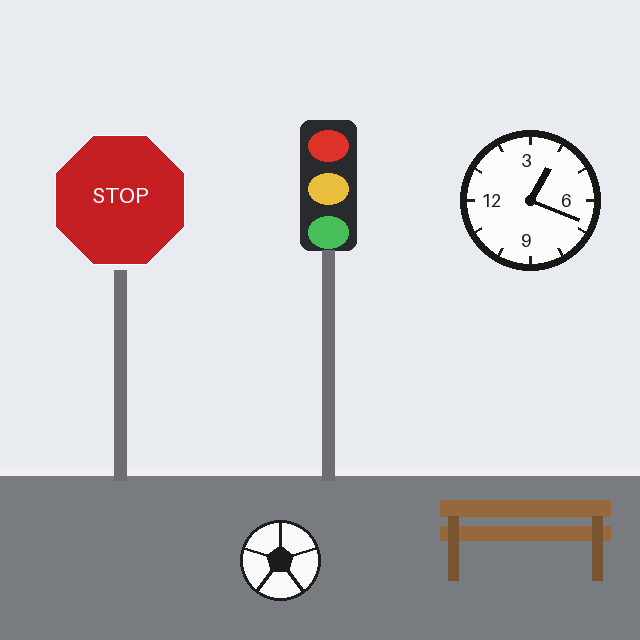

In [ ]:
import hashlib
import io
import json

threshold = 0.3  # @param {type:"number"}
nms_threshold = 0.3  # @param {type:"number"}

scene, references = tutorial_scene()
buffer = io.BytesIO()
scene.save(buffer, format='PNG')
print({'sample_kind': 'synthetic', 'size': list(scene.size), 'sha256': hashlib.sha256(buffer.getvalue()).hexdigest()[:16],
       'references': {label: len(boxes) for label, boxes in references.items()}})

input_manifest = validate_inputs(scene, threshold=threshold, nms_threshold=nms_threshold, names=['tutorial-scene'])
print({'verdict': input_manifest['verdict'], 'findings': input_manifest['findings'], 'inputs': input_manifest['inputs']})

coco_result = pipe.detect(scene, threshold=threshold, nms_threshold=nms_threshold)
for det in coco_result['detections']:
    print(f"{det['label']:>14s} {det['score']:.3f}  [{', '.join(f'{v:.0f}' for v in det['box'])}]")

coco_report = evaluation_report(coco_result, references, sample_kind='synthetic')
print({'verdict': coco_report['verdict'], 'n_detections': coco_report['n_detections']})
for metric in coco_report['metrics']:
    print(f"  {metric['reference']:>18s}  box_iou {metric['value']:.3f}  same-label detections {metric['n_detected_same_label']}")
hits = sum(1 for m in coco_report['metrics'] if m['value'] >= 0.5)
print(f'{hits}/{len(coco_report["metrics"])} drawn objects matched at IoU >= 0.5')
scene

**What to notice (Section 4):** the detections with their scores, one `box_iou` per drawn object, and the matched count.

<details><summary>Check your reasoning</summary>Four of five, in every recorded run of this model: stop sign, traffic light, clock and bench at IoU 0.918–0.975. The drawn football is not detected as a `sports ball` at any threshold, and YOLOX-X proposes **nothing else** on that box either (the smaller YOLOX-S, in the sibling repository, labels that box `kite` and a second `clock` there). A flat, drawn ball has little of the texture a photographed one has. The report keeps the miss as a zero instead of dropping the reference, which is what makes the other four numbers believable.</details>

## 5. Two checks worth running once: channel order, and what it says about nothing · [Evaluation practice]

**Channel order.** Upstream reads images with `cv2.imread`, which yields **BGR**, and feeds that array to the network as raw 0–255 floats. It is an easy thing to get silently wrong, because RGB input still produces plausible-looking detections — it just produces worse ones. The cell below feeds the identical letterboxed tensor with the channels flipped so you can see the difference rather than take it on trust.

**Degenerate inputs.** A detector should be asked what it does with a blank page and with pure noise, because a model that invents confident objects on structure-free input will invent them on your input too.

**Predict before running:** with RGB instead of BGR, will the model find the same objects with the same scores, the same objects with lower scores, or fewer objects? And how many boxes will it return for a blank page at the demo thresholds?

In [ ]:
chw, ratio = preprocess(scene)
rgb_tensor = torch.from_numpy(chw[::-1].copy()).unsqueeze(0).to(pipe.device)
with torch.no_grad():
    rgb_raw = pipe.model(rgb_tensor)
rgb_kept = postprocess(rgb_raw, len(LABELS), conf_thre=threshold, nms_thre=nms_threshold)[0]
rgb_detections = sorted(
    ([LABELS[int(row[6])], float(row[4] * row[5])] for row in (rgb_kept.tolist() if rgb_kept is not None else [])),
    key=lambda pair: -pair[1],
)
print('BGR (upstream order):', [(d['label'], round(d['score'], 3)) for d in coco_result['detections']])
print('RGB (the mistake)   :', [(label, round(score, 3)) for label, score in rgb_detections])

degenerate = {}
for name, image in (('blank', blank_scene()), ('noise', noise_scene(0))):
    demo = pipe.detect(image, threshold=threshold, nms_threshold=nms_threshold)['detections']
    lenient = pipe.detect(image, threshold=EVAL_DETECTION_THRESHOLD, nms_threshold=EVAL_NMS_THRESHOLD)['detections']
    degenerate[name] = {'at_demo_thresholds': len(demo), 'at_evaluation_thresholds': len(lenient),
                        'top': [(d['label'], round(d['score'], 3)) for d in lenient[:3]]}
print(json.dumps(degenerate, indent=2))

BGR (upstream order): [('stop sign', 0.964), ('clock', 0.946), ('traffic light', 0.926), ('bench', 0.656)]
RGB (the mistake)   : [('stop sign', 0.965), ('clock', 0.946), ('traffic light', 0.927)]


{
  "blank": {
    "at_demo_thresholds": 0,
    "at_evaluation_thresholds": 0,
    "top": []
  },
  "noise": {
    "at_demo_thresholds": 0,
    "at_evaluation_thresholds": 2,
    "top": [
      [
        "potted plant",
        0.076
      ],
      [
        "vase",
        0.057
      ]
    ]
  }
}


**What to notice (Section 5):** the BGR and RGB lines side by side, and the two degenerate counts.

<details><summary>Check your reasoning</summary>Fewer, but barely weaker. On the reference machine RGB input returned 3 detections instead of 4: stop sign, clock and traffic light kept their scores (0.965, 0.946, 0.927), and only the bench disappeared. The larger model is robust to the swap on the rigid objects, which makes the mistake *harder to notice*, not less wrong. The blank and noise images give no boxes at the demo thresholds; any box there would be a false positive by construction.</details>

## 6. Sample data for adaptation, and the validation stage · [Evaluation practice]

The detector above knows 80 COCO classes. Suppose you need three classes it does not have. `sign_dataset` draws a deterministic 40-image labelled set over `SIGN_CLASSES` — `stop-sign`, `yield-sign`, `speed-limit-sign` — with 1–3 signs per image at jittered positions, sizes and background tints, and returns exact boxes because it knows where it drew them.

**Keep the two vocabularies apart.** COCO's `stop sign` (with a space) is a class the *pretrained* model predicts; `stop-sign` (hyphenated) is a class in *your* vocabulary that only exists after adaptation. They are not the same label and the notebook never treats them as interchangeable. `yield-sign` and `speed-limit-sign` have no COCO counterpart at all.

`validate_dataset` is the validation stage for this path and applies exactly the ceilings `finetune` applies, so a dataset it accepts cannot be refused later: record shape, box geometry inside the image, labels drawn from the vocabulary, at most 50 boxes per image (the head's label tensor width), at most 200 images, at most 20 epochs. It returns a dataset manifest, and it reports a class with no boxes as a **finding rather than an error** — that dataset is trainable, but that class's head outputs will stay untrained and you should know before you spend the compute.

This is drawn data. A model fine-tuned on it learns these renderings; that is what a bounded tutorial adaptation is for, and it is why none of the numbers later is a claim about photographs of real signs.

{
  "class_names": [
    "stop-sign",
    "yield-sign",
    "speed-limit-sign"
  ],
  "n_images": 40,
  "n_boxes": 82,
  "boxes_per_class": {
    "stop-sign": 21,
    "yield-sign": 34,
    "speed-limit-sign": 27
  },
  "epochs": 6,
  "verdict": "accepted",
  "findings": [],
  "model_id": "Megvii-BaseDetection/YOLOX",
  "model_revision": "0.1.1rc0"
}

record shape expected by finetune: a mapping with 'image' (PIL.Image.Image), 'boxes' (list of xyxy pixel boxes in that image's own coordinates) and 'labels' (list of class names, one per box, drawn from class_names)
COCO classes the pretrained model knows : ['stop sign', 'clock']
adaptation vocabulary (not COCO)        : ['stop-sign', 'yield-sign', 'speed-limit-sign']



first six images, and the labels of the first: ['yield-sign']


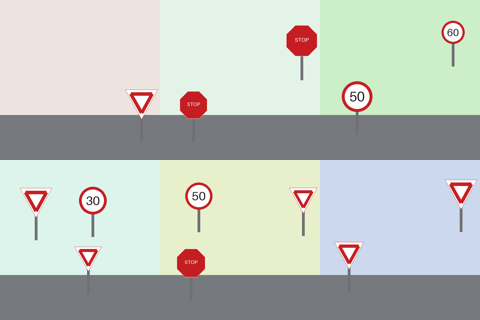

In [ ]:
N_IMAGES = 40  # @param {type:"integer"}
DATASET_SEED = 0  # @param {type:"integer"}
EPOCHS = 6  # @param {type:"integer"}

records = sign_dataset(N_IMAGES, seed=DATASET_SEED)
dataset_manifest = validate_dataset(records, SIGN_CLASSES, epochs=EPOCHS)
print(json.dumps({k: v for k, v in dataset_manifest.items() if k != 'schema'}, indent=2))
print('\nrecord shape expected by finetune:', dataset_manifest['schema']['record'])
print('COCO classes the pretrained model knows :', [c for c in LABELS if 'sign' in c or c == 'clock'])
print('adaptation vocabulary (not COCO)        :', list(SIGN_CLASSES))

preview = Image.new('RGB', (480, 320))
for index, record in enumerate(records[:6]):
    preview.paste(record['image'].resize((160, 160)), (160 * (index % 3), 160 * (index // 3)))
print('\nfirst six images, and the labels of the first:', records[0]['labels'])
preview

## 7. Split, re-head, and measure the baseline *before* adapting · [Evaluation practice]

`split_records` is a seeded permutation into a training part and a held-out part. The split is yours, not the model's: it happens before any weight is touched and the held-out records are never shown to `finetune`, so the score in Section 9 is a score on data the adapted model has not seen.

`from_pretrained(class_names=...)` builds the same YOLOX-X and loads the same verified checkpoint, but rebuilds the classification branch for your vocabulary. It prints exactly which tensors it could not transfer — the three `head.cls_preds` weight/bias pairs, one per feature level — and everything else, including the whole backbone and the box and objectness heads, comes from the COCO checkpoint. The random initialisation is seeded, because those layers are the only untrained weights in the model and they are precisely what the baseline measures.

**How much the random head scores by accident.** The classification head is random, but the box and objectness heads are COCO-trained and already know how to localise a sign-shaped thing, so the model can score a little average precision by accident — on YOLOX-X very little (the recorded baseline is AP50 0.0384, against 0.2222 for the sibling YOLOX-S). Measuring it is what lets you say later that the fine-tune did something, rather than that a detector produced boxes.

**Predict before running:** will the baseline AP50 be near 0, near 0.2 or near 0.5? Which class could score by chance?

In [ ]:
HOLDOUT = 0.25  # @param {type:"number"}
SEED = 0  # @param {type:"integer"}

train_records, held_out = split_records(records, holdout=HOLDOUT, seed=SEED)
print({'train': len(train_records), 'held_out': len(held_out),
       'train_boxes': sum(len(r['boxes']) for r in train_records),
       'held_out_boxes': sum(len(r['boxes']) for r in held_out)})

adapter = YoloxXDetectionPipeline.from_pretrained(weights_dir=WEIGHTS_DIR, class_names=SIGN_CLASSES, seed=SEED)
print({'class_names': list(adapter.class_names), 'device': adapter.device, 'adapted': adapter.adapted})
print('tensors that could not transfer from the COCO checkpoint:')
for name in adapter.reinitialised:
    print('   ', name)

baseline = adapter.evaluate(held_out)
print(json.dumps({'ap': round(baseline['ap'], 4), 'ap50': round(baseline['ap50'], 4),
                  'per_class_ap50': {k: round(v, 4) for k, v in baseline['per_class_ap50'].items()},
                  'n_references': baseline['n_references'], 'max_detections': baseline['max_detections']}, indent=2))

{'train': 30, 'held_out': 10, 'train_boxes': 61, 'held_out_boxes': 21}


{'class_names': ['stop-sign', 'yield-sign', 'speed-limit-sign'], 'device': 'cuda:0', 'adapted': False}
tensors that could not transfer from the COCO checkpoint:
    head.cls_preds.0.bias
    head.cls_preds.0.weight
    head.cls_preds.1.bias
    head.cls_preds.1.weight
    head.cls_preds.2.bias
    head.cls_preds.2.weight


{
  "ap": 0.0384,
  "ap50": 0.0384,
  "per_class_ap50": {
    "stop-sign": 0.0,
    "yield-sign": 0.0,
    "speed-limit-sign": 0.1151
  },
  "n_references": 21,
  "max_detections": 100
}


**What to notice (Section 7):** the split sizes, the six re-initialised `head.cls_preds` tensors, and the baseline scores.

<details><summary>Check your reasoning</summary>Near zero: every recorded run of this model measured AP and AP50 0.0384, with per-class AP50 stop 0.0, yield 0.0 and speed-limit 0.115. The wider X head has more random weight on top of the COCO box and objectness heads, so less accidental signal survives than on YOLOX-S (0.2222). That makes the later improvement look larger; the final AP, not the size of the jump, is the number to compare.</details>

## 8. The bounded SimOTA fine-tune · [Concept]

This is the cell that makes the notebook an `E2E` tutorial rather than an inference demo, and it runs in the default path.

The loss and the label assignment are **upstream's**, in the carried `yolo_head` module: put the head in training mode, hand it images and a `(class, cx, cy, w, h)` target tensor, and it runs SimOTA — building an IoU-and-classification cost between every ground-truth object and every candidate anchor point, picking a dynamic number of positives per object, and returning the IoU, objectness and classification terms already weighted. What this repository owns is the bounded loop around it: the target conversion, batching, the optimiser, the seed and the ceilings.

Three defaults are worth understanding because they were chosen by measurement, not taste:

- **The backbone is frozen.** Only the head trains (11.8 M of 99.0 M parameters). It is several times faster per step, and the sibling YOLOX-S repository measured that unfreezing it at this learning rate *collapses* that model to AP 0.0 (a full fine-tune of YOLOX-X at this learning rate has not been run) — a handful of gradient steps on 30 small images is enough to destroy COCO-pretrained features. The frozen backbone is also kept in eval mode so its BatchNorm running statistics are not quietly rewritten by tutorial batches.
- **Six epochs at learning rate 1e-3.** A grid over epochs, learning rate and freezing put this at held-out AP50 1.0 against 0.355 at three epochs — measured on the sibling YOLOX-S row rather than here, and verified on this one only at the chosen configuration.
- **The L1 box term stays off.** Upstream enables it only for the last 15 of 300 epochs; switching it on for a six-epoch run would change the loss scale for no benefit. You will see `l1_loss` report 0.0 throughout, and that is correct.

Watch `total_loss` fall and `num_fg` — the number of anchor points SimOTA assigned as positives per image — stay stable. A `num_fg` collapsing toward zero would mean the assignment had stopped finding anything to match.

**Every run of this cell starts from the verified base.** The cell first rebuilds `adapter` with `from_pretrained(class_names=SIGN_CLASSES, seed=SEED)` — the same COCO weights and, under the same seed, the same re-initialised classification layers the Section 7 baseline measured — so re-running it after changing a field trains once from the start, never on top of an already adapted model.

**Predict before running:** over six epochs, roughly how far will `total_loss` fall, and will `num_fg` stay near 8?

In [ ]:
LEARNING_RATE = 1e-3  # @param {type:"number"}
BATCH_SIZE = 2  # @param {type:"integer"}
FREEZE_BACKBONE = True  # @param {type:"boolean"}

import time

# YXX-m2: start every run of this cell from the verified base and the same seeded head as the baseline.
adapter = YoloxXDetectionPipeline.from_pretrained(weights_dir=WEIGHTS_DIR, class_names=SIGN_CLASSES, seed=SEED)
finetune_started = time.perf_counter()
run = adapter.finetune(
    train_records,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    seed=SEED,
    freeze_backbone=FREEZE_BACKBONE,
    progress=lambda row: print(
        f"epoch {row['epoch']}/{EPOCHS}  steps {row['steps']}  total {row['total_loss']:.4f}  "
        f"iou {row['iou_loss']:.4f}  conf {row['conf_loss']:.4f}  cls {row['cls_loss']:.4f}  "
        f"l1 {row['l1_loss']:.4f}  num_fg {row['num_fg']:.2f}"
    ),
)
print(json.dumps({'optimizer': run['optimizer'], 'loss': run['loss'], 'use_l1': run['use_l1'],
                  'freeze_backbone': run['freeze_backbone'],
                  'trainable_parameters': run['trainable_parameters'],
                  'total_parameters': run['total_parameters'],
                  'epochs': run['epochs'], 'batch_size': run['batch_size'],
                  'learning_rate': run['learning_rate'], 'seed': run['seed']}, indent=2))
first, last = run['history'][0]['total_loss'], run['history'][-1]['total_loss']
FINETUNE_SECONDS = round(time.perf_counter() - finetune_started, 1)
print(f'total_loss {first:.4f} -> {last:.4f} over {run["epochs"]} epochs in {FINETUNE_SECONDS} s')

<isolated cell 9>:488: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):


epoch 1/6  steps 15  total 5.6956  iou 1.7635  conf 2.0544  cls 1.8777  l1 0.0000  num_fg 7.73


epoch 2/6  steps 15  total 3.5334  iou 1.7765  conf 1.0110  cls 0.7460  l1 0.0000  num_fg 7.64


epoch 3/6  steps 15  total 2.4335  iou 1.3243  conf 0.5658  cls 0.5434  l1 0.0000  num_fg 7.99


epoch 4/6  steps 15  total 2.1042  iou 1.2184  conf 0.4065  cls 0.4793  l1 0.0000  num_fg 8.11


epoch 5/6  steps 15  total 1.8066  iou 1.0447  conf 0.3462  cls 0.4157  l1 0.0000  num_fg 8.45


epoch 6/6  steps 15  total 1.6057  iou 0.9232  conf 0.3333  cls 0.3492  l1 0.0000  num_fg 8.68
{
  "optimizer": "SGD(momentum=0.9, weight_decay=5e-4)",
  "loss": "upstream YOLOXHead SimOTA (IoU + objectness + classification)",
  "use_l1": false,
  "freeze_backbone": true,
  "trainable_parameters": 11793304,
  "total_parameters": 98997304,
  "epochs": 6,
  "batch_size": 2,
  "learning_rate": 0.001,
  "seed": 0
}
total_loss 5.6956 -> 1.6057 over 6 epochs in 19.2 s


**What to notice (Section 8):** one line per epoch, `l1` at 0.0, `num_fg` steady, and the trainable-parameter count.

<details><summary>Check your reasoning</summary>On the reference machine `total_loss` fell from 5.696 to 1.616 over six epochs and `num_fg` stayed between 7.7 and 8.7: SimOTA kept finding about eight positives per image. Only 11.8 M of 99.0 M parameters trained. A falling loss shows the head fits the 30 training images; whether that transfers is Section 9's question.</details>

## 9. Evaluate on the held-out split · [Evaluation practice]

The same `evaluate` call as the baseline, on the same held-out records, with the same thresholds — so the two numbers are comparable and the only thing that changed is the weights.

`ap50` is average precision at IoU 0.50; `ap` is COCO's primary metric, AP@[.50:.95], the mean over ten IoU thresholds from 0.50 to 0.95 — it is always lower, because it demands progressively tighter boxes. Evaluation uses the *evaluation* thresholds (`0.01 / 0.65`) rather than the demo pair, since average precision rewards recall, and caps detections at 100 per image as COCO does.

What this number is: evidence that a bounded fine-tune on 30 drawn images moved a held-out score. What it is not: these are not a detection benchmark. The held-out split is ten images from the same generator with the same three shapes, so AP50 reaching 1.0 says the task is easy and the adaptation worked — not that the model would find a real sign in a real photograph. The AP@[.50:.95] figure, which is well below 1.0, is the more informative one: the boxes are right but not perfectly tight.

Every run of Sections 8–9 is appended to `run_history`, so the activity at the end (Section 14) prints both settings side by side.

**Predict before running:** after six epochs, will held-out AP50 be near 0.5, near 0.9 or 1.0? And AP@[.50:.95]?

In [ ]:
adapted = adapter.evaluate(held_out)
print(json.dumps({'ap': round(adapted['ap'], 4), 'ap50': round(adapted['ap50'], 4), 'ap75': round(adapted['ap75'], 4),
                  'per_class_ap50': {k: round(v, 4) for k, v in adapted['per_class_ap50'].items()},
                  'threshold': adapted['threshold'], 'nms_threshold': adapted['nms_threshold'],
                  'max_detections': adapted['max_detections'],
                  'n_images': adapted['n_images'], 'n_references': adapted['n_references']}, indent=2))
print()
print(f"{'metric':<10s} {'baseline':>10s} {'adapted':>10s} {'change':>10s}")
for key in ('ap', 'ap50'):
    before_value, after_value = baseline[key], adapted[key]
    print(f'{key:<10s} {before_value:>10.4f} {after_value:>10.4f} {after_value - before_value:>+10.4f}')
print('\nimplementation note:', adapted['implementation'])
run_history = globals().get('run_history', [])
run_history.append({'freeze_backbone': FREEZE_BACKBONE, 'epochs': EPOCHS, 'learning_rate': LEARNING_RATE, 'ap': round(adapted['ap'], 4), 'ap50': round(adapted['ap50'], 4), 'finetune_seconds': FINETUNE_SECONDS})
for number, row in enumerate(run_history, start=1):
    print(f'run {number}:', row)

{
  "ap": 0.8974,
  "ap50": 1.0,
  "ap75": 1.0,
  "per_class_ap50": {
    "stop-sign": 1.0,
    "yield-sign": 1.0,
    "speed-limit-sign": 1.0
  },
  "threshold": 0.01,
  "nms_threshold": 0.65,
  "max_detections": 100,
  "n_images": 10,
  "n_references": 21
}

metric       baseline    adapted     change
ap             0.0384     0.8974    +0.8590
ap50           0.0384     1.0000    +0.9616

implementation note: package-local average_precision: COCO matching and 101-point interpolation, without pycocotools' area ranges, detection cap or crowd handling — not comparable to published COCO numbers
run 1: {'freeze_backbone': True, 'epochs': 6, 'learning_rate': 0.001, 'ap': 0.8974, 'ap50': 1.0, 'finetune_seconds': 19.2}


**What to notice (Section 9):** the adapted scores beside the baseline.

<details><summary>Check your reasoning</summary>AP50 1.0 in every recorded run; AP@[.50:.95] 0.791 on the reference CPU and 0.897 on a Kaggle T4. The AP50 is saturated: ten images from the training generator are too easy to separate a good adapter from a perfect one. The two AP values differ by device with identical AP50, which shows how little ten images resolve — the tighter metric moves with tiny numerical differences.</details>

## 10. Inference on new data · [Concept]

Held-out images were drawn from the same seed as the training set. These come from a different seed entirely, so their layouts, sizes, tints and sign choices were never part of the split at all — the closest a synthetic tutorial gets to new data.

The detections use the **demo thresholds** again, because this is the "what would I actually deploy" view rather than the scoring view. Each detection is checked against the drawn truth with `box_iou` on the same label.

**Predict before running:** how many of the five signs on the three new images will be found with the right label?

{"image": 0, "truth": ["yield-sign", "yield-sign"], "detections": [["yield-sign", 0.946], ["yield-sign", 0.934]], "same_label_iou": [0.946, 0.945]}
{"image": 1, "truth": ["speed-limit-sign", "yield-sign"], "detections": [["speed-limit-sign", 0.968], ["yield-sign", 0.953]], "same_label_iou": [0.946, 0.899]}
{"image": 2, "truth": ["stop-sign"], "detections": [["stop-sign", 0.976]], "same_label_iou": [0.82]}


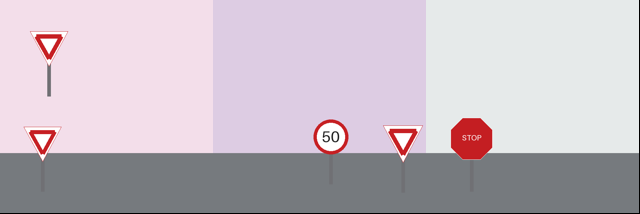

In [ ]:
NEW_DATA_SEED = 99  # @param {type:"integer"}

new_records = sign_dataset(3, seed=NEW_DATA_SEED)
new_data_rows = []
for index, record in enumerate(new_records):
    out = adapter.detect(record['image'], threshold=threshold, nms_threshold=0.45)
    ious = []
    for box, label in zip(record['boxes'], record['labels'], strict=True):
        same_label = [d for d in out['detections'] if d['label'] == label]
        ious.append(round(max((box_iou(d['box'], box) for d in same_label), default=0.0), 3))
    row = {'image': index, 'truth': record['labels'],
           'detections': [(d['label'], round(d['score'], 3)) for d in out['detections']],
           'same_label_iou': ious}
    new_data_rows.append(row)
    print(json.dumps(row))

contact = Image.new('RGB', (640, 214))
for index, record in enumerate(new_records):
    contact.paste(record['image'].resize((213, 213)), (213 * index, 0))
contact

**What to notice (Section 10):** one row per image with the truth, the detections and the same-label IoU.

<details><summary>Check your reasoning</summary>All five, with the right labels, scores 0.947–0.978 and IoU 0.82–0.89, and no spurious boxes, on the reference machine — more confident than YOLOX-S but with looser boxes, a reminder that confidence and localisation are separate things. That is encouraging for drawn signs from an unseen seed, but they come from the same generator: same shapes, same colours, same rendering. It is not evidence about photographs.</details>

## 11. Export the artifact, then reload it as if from a cold start · [Engineering]

`save_artifact` writes one file: the adapted `state_dict` plus the metadata needed to rebuild the model — the format tag, the pinned model identity, the upstream code revision, the class vocabulary, the architecture constants and the digest of the base weights it started from. It is a plain `torch.save` of tensors and simple values, with no archive to extract and nothing that requires `weights_only=False` to read back, so there is no unpacking step to make safe.

`load_artifact` is the fresh-reload check: it rebuilds the model from the file alone, without reference to the `adapter` object still in memory, and refuses an artifact whose format tag or pinned identity does not match this package. The cell then re-scores the held-out split with the reloaded model and asserts the numbers are identical — a reload that quietly lost the adaptation would show up here as a different AP, and the assertion would stop the notebook.

The last part of the cell tampers with a copy of the artifact and confirms it is refused, because "it loads" is only evidence if something that should not load is also tried.

In [ ]:
import os
from pathlib import Path

OUTPUTS = Path('outputs')
os.makedirs('outputs', exist_ok=True)
artifact_path = OUTPUTS / ARTIFACT_FILE
descriptor = adapter.save_artifact(artifact_path, notes='standalone tutorial run')
print(json.dumps({k: v for k, v in descriptor.items() if k != 'base_state_digest'}, indent=2))

reloaded = YoloxXDetectionPipeline.load_artifact(artifact_path)
print({'source': reloaded.source, 'class_names': list(reloaded.class_names), 'adapted': reloaded.adapted})
reloaded_metrics = reloaded.evaluate(held_out)
print({'reloaded_ap': round(reloaded_metrics['ap'], 4), 'reloaded_ap50': round(reloaded_metrics['ap50'], 4)})
assert abs(reloaded_metrics['ap'] - adapted['ap']) < 1e-9, 'the reloaded artifact does not reproduce the adapted score'
assert abs(reloaded_metrics['ap50'] - adapted['ap50']) < 1e-9
print('fresh reload reproduces the adapted scores exactly')

tampered = OUTPUTS / 'tampered-artifact.pt'
payload = torch.load(artifact_path, map_location='cpu', weights_only=True)
payload['format'] = 'not-a-dimer-artifact/9'
torch.save(payload, tampered)
try:
    YoloxXDetectionPipeline.load_artifact(tampered)
except ValueError as exc:
    print('tampered artifact refused ->', exc)
else:
    raise AssertionError('a tampered artifact was accepted')
finally:
    tampered.unlink(missing_ok=True)

{
  "path": "outputs/yolox-x-detection-adapter.pt",
  "bytes": 396692619,
  "sha256": "b4d1803d35365262fa4f0f0aa41a12c95b05f841f8ef8e3a27b91fb14cc49804",
  "format": "dimer-yolox-detection-adapter/1",
  "class_names": [
    "stop-sign",
    "yield-sign",
    "speed-limit-sign"
  ],
  "tensors": 894,
  "model_id": "Megvii-BaseDetection/YOLOX",
  "model_revision": "0.1.1rc0"
}


{'source': 'artifact:yolox-x-detection-adapter.pt', 'class_names': ['stop-sign', 'yield-sign', 'speed-limit-sign'], 'adapted': True}


{'reloaded_ap': 0.8974, 'reloaded_ap50': 1.0}
fresh reload reproduces the adapted scores exactly


tampered artifact refused -> artifact format 'not-a-dimer-artifact/9' != 'dimer-yolox-detection-adapter/1'


## 12. Machine-readable outputs and provenance · [Engineering]

Everything the notebook established, written to `outputs/` as JSON beside the artifact: the pinned identity and manifest digest, the runtime, the input and dataset manifests, the COCO detections and their per-object IoU, the baseline and adapted metrics with the exact request that produced them, the new-data rows, and the artifact descriptor. A later reader can tell what was measured, on what, with which weights, without rerunning anything.

In [ ]:
import platform

export = {
    'notebook': NOTEBOOK_SOURCE,
    'repository_revision': NOTEBOOK_SOURCE['repository_revision'],
    'model': {'model_id': MODEL_ID, 'revision': MODEL_REVISION, 'license': MODEL_LICENSE,
              'upstream_code_revision': UPSTREAM_CODE_REVISION, 'release_asset': RELEASE_ASSET_URL,
              'manifest_sha256': [entry['sha256'] for entry in MANIFEST['files']],
              'depth': MODEL_DEPTH, 'width': MODEL_WIDTH, 'input_size': list(INPUT_SIZE)},
    'runtime': {'python': platform.python_version(), 'torch': torch.__version__,
                'torchvision': torchvision.__version__, 'device': adapter.device,
                'cuda': torch.cuda.is_available(), 'precision': 'float32'},
    'coco_demonstration': {'input_manifest': input_manifest, 'detections': coco_result['detections'],
                           'evaluation': coco_report},
    'degenerate_inputs': degenerate,
    'channel_order': {'bgr': [(d['label'], round(d['score'], 4)) for d in coco_result['detections']],
                      'rgb': [(label, round(score, 4)) for label, score in rgb_detections]},
    'adaptation': {'dataset': dataset_manifest, 'split': {'train': len(train_records), 'held_out': len(held_out)},
                   'run': run, 'baseline': baseline, 'adapted': adapted,
                   'new_data': new_data_rows, 'artifact': descriptor},
}
path = OUTPUTS / 'yolox_x_detection_results.json'
with open(path, 'w', encoding='utf-8') as handle:
    json.dump(export, handle, indent=2, default=str)
print({'written': str(path), 'bytes': path.stat().st_size, 'artifact': str(artifact_path)})
print(sorted(p.name for p in OUTPUTS.iterdir()))

{'written': 'outputs/yolox_x_detection_results.json', 'bytes': 18483, 'artifact': 'outputs/yolox-x-detection-adapter.pt'}
['yolox-x-detection-adapter.pt', 'yolox_x_detection_results.json']


## 13. Optional: your own image, or your own labelled dataset · [Engineering]

Both branches are off by default so the cell above completes a full `Run all` without stopping for an upload.

**`USE_BYOD_IMAGE`** runs one image — from `BYOD_IMAGE_PATH`, or exactly one file from the upload dialog, refused by name if Pillow cannot decode it — through the same `validate_inputs` → `detect` → `evaluation_report` contract as the sample, with the pretrained COCO model. There are no reference boxes for your image, so the evaluation report will say `not-measurable` — which is the correct answer, not a failure.

**`USE_BYOD_DATASET`** is the one that matters for an adaptation profile. Supply your own labelled records and they go through the *same* local stages the sample did: validate, split, baseline, fine-tune, evaluate. It does not degrade into inference-only just because the data is yours (NOTEBOOK_SPEC 2.2 DAT14). Put the images and an `annotations.json` in a directory and set `BYOD_DATASET_DIR` to it (any Jupyter runtime), or leave it empty and select the images and `annotations.json` together in the upload dialog. `annotations.json` is a list of `{'file': 'name.png', 'boxes': [[x0, y0, x1, y1], ...], 'labels': [name, ...]}` objects with xyxy boxes in that image's pixels; `read_detection_records` refuses a path outside the directory, a missing file and an undecodable image by name, and `validate_dataset` then applies the same ceilings as for the sample. `BYOD_CLASS_NAMES` is a comma-separated vocabulary; leave it empty to use the sorted set of labels in the annotations. At least **8 records** are needed, so the 25 % held-out split has two or more images; for a usable measurement aim for dozens. The cell then repeats Sections 7–9 on your data, exports the artifact, reloads it and asserts identical held-out scores as in Section 11, and writes `outputs/byod_yolox_x_result.json`. Labelling images is outside this notebook's scope — export boxes in xyxy pixel coordinates from whatever tool you use.

The cell rejects one deliberately incompatible input so you can see what a refusal looks like before you trust an acceptance.

In [ ]:
USE_BYOD_IMAGE = False  # @param {type:"boolean"}
BYOD_IMAGE_PATH = ""  # @param {type:"string"}
USE_BYOD_DATASET = False  # @param {type:"boolean"}
BYOD_DATASET_DIR = ""  # @param {type:"string"}
BYOD_CLASS_NAMES = ""  # @param {type:"string"}

# What a refusal looks like, always run: the validator names the first violated ceiling.
for description, thunk in (
    ('an image that is not a PIL image', lambda: validate_inputs('/path/to/image.png')),
    ('a box outside its image', lambda: validate_dataset(
        [{'image': blank_scene(), 'boxes': [[0, 0, 9999, 10]], 'labels': [SIGN_CLASSES[0]]}], SIGN_CLASSES)),
):
    try:
        thunk()
    except (TypeError, ValueError) as exc:
        print(f'refused {description} -> {type(exc).__name__}: {exc}')

BYOD_DIR = OUTPUTS / 'byod'


def _upload(target):
    from google.colab import files  # type: ignore[import-not-found]

    uploaded = files.upload()
    target.mkdir(parents=True, exist_ok=True)
    for upload_name, upload_data in uploaded.items():
        (target / Path(upload_name).name).write_bytes(upload_data)
    return uploaded


if USE_BYOD_IMAGE:
    if BYOD_IMAGE_PATH:
        name, data = Path(BYOD_IMAGE_PATH).name, Path(BYOD_IMAGE_PATH).read_bytes()
    else:
        uploaded = _upload(BYOD_DIR / 'image')
        if len(uploaded) != 1:
            raise RuntimeError(f'Upload exactly one image (received {len(uploaded)}); or set BYOD_IMAGE_PATH and run this cell again.')
        ((name, data),) = uploaded.items()
    byod_image = load_byod_image(name, data)
    print(validate_inputs(byod_image, threshold=threshold, nms_threshold=nms_threshold, names=[name])['verdict'])
    byod_result = pipe.detect(byod_image, threshold=threshold, nms_threshold=nms_threshold)
    for det in byod_result['detections'][:20]:
        print(f"{det['label']:>14s} {det['score']:.3f}")
    print(evaluation_report(byod_result, None, sample_kind='byod')['verdict'])
else:
    print('BYOD image branch is off; set USE_BYOD_IMAGE = True (and optionally BYOD_IMAGE_PATH) and re-run this cell.')

if USE_BYOD_DATASET:
    if BYOD_DATASET_DIR:
        dataset_dir = Path(BYOD_DATASET_DIR)
    else:
        dataset_dir = BYOD_DIR / 'dataset'
        _upload(dataset_dir)
    byod_records = read_detection_records(dataset_dir)
    if len(byod_records) < 8:
        raise ValueError(f'the BYOD dataset has {len(byod_records)} records; at least 8 are needed so the held-out split has 2 or more images')
    byod_names = [n.strip() for n in BYOD_CLASS_NAMES.split(',') if n.strip()] or sorted({label for r in byod_records for label in r['labels']})
    byod_manifest = validate_dataset(byod_records, byod_names, epochs=EPOCHS)
    print(json.dumps({k: v for k, v in byod_manifest.items() if k != 'schema'}, indent=2))
    byod_train, byod_held = split_records(byod_records, holdout=HOLDOUT, seed=SEED)
    byod_pipe = YoloxXDetectionPipeline.from_pretrained(weights_dir=WEIGHTS_DIR, class_names=byod_names, seed=SEED)
    byod_baseline = byod_pipe.evaluate(byod_held)
    print('baseline:', {k: round(byod_baseline[k], 4) for k in ('ap', 'ap50')})
    byod_run = byod_pipe.finetune(byod_train, epochs=EPOCHS, batch_size=BATCH_SIZE, learning_rate=LEARNING_RATE, seed=SEED, freeze_backbone=FREEZE_BACKBONE)
    byod_adapted = byod_pipe.evaluate(byod_held)
    print('adapted :', {k: round(byod_adapted[k], 4) for k in ('ap', 'ap50')})
    byod_artifact = OUTPUTS / 'byod-adapter.pt'
    byod_descriptor = byod_pipe.save_artifact(byod_artifact, notes='BYOD tutorial run')
    byod_reloaded_metrics = YoloxXDetectionPipeline.load_artifact(byod_artifact).evaluate(byod_held)
    assert abs(byod_reloaded_metrics['ap'] - byod_adapted['ap']) < 1e-9, 'the reloaded BYOD artifact does not reproduce the adapted score'
    assert abs(byod_reloaded_metrics['ap50'] - byod_adapted['ap50']) < 1e-9
    byod_reload_check = {'reloaded_ap': byod_reloaded_metrics['ap'], 'reloaded_ap50': byod_reloaded_metrics['ap50'], 'identical': True}
    print('fresh reload reproduces the BYOD adapted scores exactly')
    byod_export = {'notebook': NOTEBOOK_SOURCE, 'model_id': MODEL_ID, 'model_revision': MODEL_REVISION, 'dataset_dir': str(dataset_dir),
                   'class_names': byod_names, 'dataset': {k: v for k, v in byod_manifest.items() if k != 'schema'},
                   'split': {'train': len(byod_train), 'held_out': len(byod_held), 'holdout': HOLDOUT, 'seed': SEED},
                   'run': byod_run, 'baseline': byod_baseline, 'adapted': byod_adapted, 'artifact': byod_descriptor, 'reload_check': byod_reload_check}
    with open(OUTPUTS / 'byod_yolox_x_result.json', 'w', encoding='utf-8') as handle:
        json.dump(byod_export, handle, indent=2, default=str)
    print({'written': str(OUTPUTS / 'byod_yolox_x_result.json')})
else:
    print('BYOD dataset branch is off; set USE_BYOD_DATASET = True and BYOD_DATASET_DIR (or upload), then re-run this cell.')

refused an image that is not a PIL image -> TypeError: image must be a PIL.Image.Image, got str
refused a box outside its image -> ValueError: record 0: box [0, 0, 9999, 10] falls outside the 640x640 image
BYOD image branch is off; set USE_BYOD_IMAGE = True (and optionally BYOD_IMAGE_PATH) and re-run this cell.
BYOD dataset branch is off; set USE_BYOD_DATASET = True and BYOD_DATASET_DIR (or upload), then re-run this cell.


## Interpretation and limits

**What this notebook established, in this runtime.** The pinned `yolox_x.pth` release asset was downloaded, digest-verified against a committed SHA-256 before anything unpickled it, and loaded into YOLOX-X built from vendored upstream code. The pretrained detector found four of the five drawn COCO objects with per-object IoU 0.918–0.975 in the recorded runs and missed the fifth entirely. A three-class vocabulary that does not exist in COCO was adapted onto it by a bounded SimOTA fine-tune of the head alone, scored against a held-out split with COCO-style average precision before and after, run on images from an unseen seed, exported as a single artifact and reloaded from that artifact to identical scores.

**What it did not establish.** Nothing here is a benchmark and nothing here is about photographs. Both datasets are drawn in code with Pillow: flat colours, hard edges, no lighting, no occlusion, no motion blur, no scale variety beyond the jitter the generator applies. A held-out AP50 of 1.0 on ten images from the same generator says the task is easy and the plumbing works; it is not evidence about real signs, and the much lower AP@[.50:.95] is the more honest summary — the boxes are right, not tight. Upstream's published 51.5 AP for YOLOX-X on COCO test-dev is neither reproduced nor checked here, and the average-precision helper carried in Section 2 is a small faithful implementation without pycocotools' area ranges, crowd handling or official matching, so its numbers are not comparable to published COCO results.

**The misses are the useful part.** The drawn football is never proposed as a `sports ball`, and YOLOX-X proposes nothing else on that box either (the smaller YOLOX-S labels it `kite` and a second `clock`); the evaluation report records a zero rather than quietly dropping the reference. Earlier probing on the sibling YOLOX-S row found something sharper: a plain white disc with two hands is not read as a clock at all, and drawing it that way made the *ball* become the clock — the numerals in the sample's clock face are there because of that, and YOLOX-X reads that face at 0.946 with IoU 0.975. Treat a detector's confidence on rendered graphics as a statement about rendered graphics.

**If you adapt this to your own data.** The three defaults that were chosen by measurement will not automatically transfer. The frozen backbone is right for a few dozen images and a few epochs; with real data and real compute, unfreeze it and lower the learning rate — the sibling YOLOX-S repository measured a full fine-tune at 1e-3 collapsing to AP 0.0, which is what a too-large step on pretrained features looks like; the same run has not been made on YOLOX-X. Six epochs is a tutorial budget, not a recipe. And the thresholds are yours: the demo pair for looking at results, the evaluation pair for scoring, neither calibrated for anything.

**What a green run proves.** Successful execution proves that the recorded repository revision, the pinned dependency set and the pinned checkpoint together reproduce these stages in a fresh runtime, without the repository being cloned or installed and without any DIMER worker or service. It does **not** establish benchmark superiority, fitness for any deployment, or that the adapted model generalises beyond the drawn data it was fitted to.

**Reproducibility.** Every random choice is seeded — dataset generation, the split, the re-headed classification layers and the training shuffle — and the seeds are form parameters at the top of their cells. Precision is float32 on CPU and GPU alike; no autocast, no quantisation, no compiled kernels. Re-running this notebook unchanged in an equivalent runtime should reproduce the numbers; changing `DATASET_SEED` or `SEED` will change them, which is a useful thing to do once to see how much of the result is the seed.

## 14. Activity: change one thing — unfreeze the backbone · [Concept]

Optional; **Predict → Change one thing → Run → Observe → Explain**. It changes nothing unless you do it.

1. **Predict:** with `FREEZE_BACKBONE = False` the whole network trains at the same learning rate. Will held-out AP rise, stay or fall? Will the fine-tune take longer?
2. **Change:** in Section 8 set `FREEZE_BACKBONE = False`. Change nothing else.
3. **Run:** select the Section 8 cell and choose *Runtime → Run after*. Section 8 rebuilds `adapter` from the verified base with the same seeded head, so this is one clean run with the new setting, not a second run on top of the first. Sections 9–12 overwrite the artifact and the outputs (download `outputs/` first if you want to keep them).
4. **Observe:** Section 9 prints `run_history` with both runs: AP, AP50 and the fine-tune seconds. Compare `num_fg` and the trainable parameters in Section 8.
5. **Explain:** in one sentence, why can training more of a pretrained network make it worse on 30 images?

<details><summary>Check your reasoning</summary>**This has not been measured on YOLOX-X** — you would be the first to run it, and on CPU it takes many times longer than the frozen run (130 s on the reference machine), so attach a GPU. The sibling YOLOX-S repository measured the same change: with the backbone unfrozen at 1e-3 its held-out AP and AP50 collapsed to 0.0, and the run took about 4.5× longer. A step size that suits a new head is far too large for COCO-pretrained features; a few dozen gradient steps on 30 drawn images can destroy what the backbone knew, and the head has nothing left to read. Whether the larger X backbone fares better is exactly what your run tests. With real data you would unfreeze with a much smaller learning rate, and check on a held-out split, as here.</details>

## Troubleshooting

| Symptom | Likely cause | What to do |
|---|---|---|
| Section 1 stops with `This notebook needs a Linux x86_64 runtime` | a local Windows or macOS kernel, or an ARM machine | Use Google Colab, Kaggle or a Linux x86_64 Jupyter; the lock holds manylinux x86_64 wheels. |
| Section 1 fails while downloading, or `The pinned uv wheel failed its size/SHA-256 check` | a network failure, or an altered download | Run the Section 1 install cell again; a repeated mismatch means the download is being altered — never edit the digest. |
| `holds Python …, not 3.12.12` in Section 1 | an older `dimer_isolated_env/` folder from another notebook version | Delete that folder (or start a fresh runtime) and run the install cell again. |
| `The isolated environment's Python process exited` | the worker ran out of memory | Lower `BATCH_SIZE` in Section 8, restart the session and choose *Runtime → Run all*. |
| The release-asset download in Section 3 fails, or a `sha256` mismatch | `github.com` is unreachable, or the file changed | Run Section 3 again; a digest mismatch is never loaded — do not edit the manifest. |
| Held-out AP 0.0 after Section 8 | `FREEZE_BACKBONE = False` at learning rate 1e-3 (the measured collapse), or a too-large `LEARNING_RATE` | Restore the defaults and run again from Section 8. |
| `RuntimeError: Upload exactly one image` in Section 13 | the dialog was cancelled, or several files were chosen | Run the cell again and choose one image, or set `BYOD_IMAGE_PATH`. |
| `…: not an image Pillow can decode` or `image … not found` in Section 13 | a corrupt file, or a name in `annotations.json` that is not in the directory | Fix the named file or entry and run Section 13 again. |
| `the BYOD dataset has N records; at least 8 are needed` | too few labelled images | Add labelled images; a few dozen give a more useful measurement. |
| A `ValueError` naming a record, box or label | `annotations.json` breaks the dataset contract (Section 13) | Fix the named record and run Section 13 again. |
| `the reloaded artifact does not reproduce the adapted score` | the artifact did not round-trip | Re-run from Section 8; do not ship the artifact if it repeats. |

## Conclusion (your notes)

Optional. Fill in from your own run, one sentence each:

1. On the drawn COCO scene the detector matched ___ of 5 objects; the miss was ___, and on that box the model proposed ___.
2. Feeding RGB instead of BGR changed ___.
3. Held-out AP50 went from ___ to ___, and AP@[.50:.95] from ___ to ___; the new-data images gave ___ of 5 correct.
4. With `FREEZE_BACKBONE = False` (Section 14), held-out AP ___ and the fine-tune took ___.
5. What I would need before trusting this adapted detector on real photographs: ___.

## References

- Ge, Z., Liu, S., Wang, F., Li, Z. and Sun, J. (2021). *YOLOX: Exceeding YOLO Series in 2021.* [arXiv:2107.08430](https://arxiv.org/abs/2107.08430) — the anchor-free design, the decoupled head and SimOTA.
- [Megvii-BaseDetection/YOLOX](https://github.com/Megvii-BaseDetection/YOLOX) — the upstream repository, Apache-2.0. The model code carried in Section 2 is vendored from it at a pinned commit; the repository's `docs/UPSTREAM.md` records the revision, the per-file digests and the three edits applied.
- [Release `0.1.1rc0`](https://github.com/Megvii-BaseDetection/YOLOX/releases/tag/0.1.1rc0) — the immutable tag whose assets carry every published YOLOX checkpoint, including the `yolox_x.pth` this notebook verifies.
- Lin, T.-Y. et al. (2014). *Microsoft COCO: Common Objects in Context.* [arXiv:1405.0312](https://arxiv.org/abs/1405.0312) — the 80 classes the pretrained checkpoint predicts, and the average-precision protocol the evaluation helper approximates.
- Repository model card: https://github.com/kurtvalcorza/yolox-x-detection-pipeline/blob/main/MODEL_CARD.md
- [`kurtvalcorza/yolox-x-detection-pipeline`](https://github.com/kurtvalcorza/yolox-x-detection-pipeline) — this notebook's source repository: the package carried in Section 2, its tests, `MODEL_CARD.md`, and `docs/release-verification.md` with the measured fine-tuning grid behind the defaults used here.